# Lección 13.3 · Descubrimiento de motivos regulatorios: EM, Gibbs, enriquecimiento y centralidad

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-13-epigenomica/13.3_descubrimiento_motivos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 13 — Epigenómica y regulación** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 4.2 (PWM, contenido de información y logos), lección 13.1 (picos de ChIP-seq), probabilidad básica (Bayes, binomial, hipergeométrica), NumPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Formular** el descubrimiento de motivos como un problema de **datos incompletos**: escribir el modelo generativo
   OOPS, su razón de verosimilitudes $r_{ij}$ y la log-verosimilitud $\mathrm{LLR}(\theta)$ en bits.
2. **Ejecutar a mano y en Python** un **paso E** (probabilidades posteriores $Z_{ij}$ como "votos fraccionarios") y un
   **paso M** (una PWM construida con esos votos), y **explicar** por qué EM nunca empeora la verosimilitud pero sí puede
   quedarse en un óptimo local.
3. **Programar** el **muestreador de sitios de Gibbs** de Lawrence et al. (1993) y **reconocer** su enemigo típico:
   los **desfases** del motivo.
4. **Descubrir desde cero** el motivo de **CTCF** en secuencias reales alrededor de las cumbres de picos de ChIP-seq de
   ENCODE (células linfoblastoides GM12878) y **compararlo** con el perfil **MA0139** de JASPAR, columna a columna y
   contra las 879 matrices de vertebrados.
5. **Medir** el **enriquecimiento diferencial** de motivos conocidos al estilo de HOMER (prueba hipergeométrica con un
   fondo **emparejado por GC**) y **explicar** por qué sin ese emparejamiento aparecen falsos positivos.
6. **Distinguir** unión directa de indirecta con el análisis de **centralidad** al estilo de CentriMo (prueba
   binomial en una ventana central).

## 🗺️ Mapa de la clase

1. El problema: una contraseña escondida en treinta cartas
2. El modelo generativo OOPS y la razón de verosimilitudes
3. Un paso E, cifra por cifra
4. El algoritmo EM (y lo que hace MEME además) — 🎛️ trayectorias interactivas
5. 🎬 Un motivo emerge del ruido: el logo iteración a iteración
6. El muestreador de Gibbs y los desfases
7. 🧪 Datos reales: 1 000 picos de CTCF en GM12878
8. 🧪 EM sobre las cumbres de CTCF (con las dos hebras)
9. 🎬 Gibbs sobre CTCF: los sitios se juntan en la cumbre
10. Ponerle nombre al motivo: JASPAR MA0139 y una comparación tipo Tomtom
11. Enriquecimiento diferencial al estilo de HOMER — 🎛️ 879 motivos conocidos
12. Centralidad al estilo de CentriMo: ¿unión directa o indirecta? — 🎛️ perfiles interactivos
13. Motivos que engañan
14. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Descubrimiento de motivos regulatorios» del capítulo 13
> del libro *Bioinformática Práctica*. Usamos exactamente sus símbolos ($X_i$, $N$, $L$, $W$, $m$, $\theta_{k,b}$,
> $p_0$, $Z_{ij}$, $r_{ij}$, $\beta_b$, $a_i$, $q_{k,b}$, $n_t$, $k_t$, $n_b$, $k_b$), reproducimos sus ejemplos resueltos
> («Un paso E», «Un motivo enriquecido») cifra por cifra y volvemos a correr sus simulaciones **con las mismas
> semillas**; pero el notebook se puede seguir sin el libro. La lección 4.2 ya construyó PWM y logos desde sitios
> conocidos y presentó un muestreador de Gibbs de juguete; aquí damos el paso siguiente: la **teoría** de EM, sus
> garantías y sus trampas, y el análisis completo de un experimento real de ChIP-seq.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, json, math, time
import plotly.graph_objects as go
from scipy import stats
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def data_file(name):
    """Archivo del curso: primero ../data; si no está, se descarga del repositorio del curso."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        os.makedirs(os.path.dirname(name) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

def cached_json(name, url):
    """Respuesta de una API: copia local (../data/api_cache) → red → copia en GitHub."""
    local = os.path.join("..", "data", "api_cache", name)
    if os.path.exists(local):
        with open(local) as fh:
            return json.load(fh)
    try:
        with urllib.request.urlopen(url, timeout=20) as r:
            return json.load(r)
    except Exception:
        with urllib.request.urlopen(f"{RAW}/data/api_cache/{name}", timeout=30) as r:
            return json.load(r)

BASES = "ACGT"
B_INDEX = {b: i for i, b in enumerate(BASES)}
COMPLEMENT = str.maketrans("ACGTacgt", "TGCAtgca")

def revcomp(seq):
    """Reverso complementario de una secuencia de ADN."""
    return seq.translate(COMPLEMENT)[::-1]

def encode(seq):
    """Texto ACGT → vector de enteros 0-3."""
    return np.array([B_INDEX[b] for b in seq.upper()], dtype=np.int8)

def kmer(theta):
    """Consenso de una matriz W x 4 (la base más probable de cada columna)."""
    return "".join(BASES[b] for b in np.asarray(theta).argmax(1))

def ic(theta, p0=np.full(4, 0.25)):
    """Contenido de información total (bits) de una matriz W x 4, como en el libro."""
    theta = np.asarray(theta)
    return float((theta * np.log2(theta / p0)).sum())

# --- sequence logo desde cero (la receta de la lección 4.2, aplicada a una matriz θ de W x 4) ---
_FONT = FontProperties(family="DejaVu Sans", weight="bold")
_GLYPHS = {}

def draw_letter(ax, letter, x, y, width, height, color):
    """Dibuja una letra que llena exactamente el rectángulo [x, x+width] x [y, y+height]."""
    if height <= 1e-3:
        return
    if letter not in _GLYPHS:
        path = TextPath((0, 0), letter, size=1, prop=_FONT)
        _GLYPHS[letter] = (path, path.get_extents())
    path, ext = _GLYPHS[letter]
    tr = (Affine2D().translate(-ext.x0, -ext.y0).scale(width / ext.width, height / ext.height).translate(x, y))
    ax.add_patch(PathPatch(tr.transform_path(path), facecolor=color, edgecolor="none"))

def draw_logo(ax, theta, title=None, xlabel="columna k del motivo", ylim=2.05, fs=11, ticks=True):
    """Logo de una matriz θ (W x 4). Altura de la columna R_k = 2 + Σ_b θ log2 θ (bits); letra ∝ θ_{k,b}."""
    theta = np.clip(np.asarray(theta, float), 1e-12, 1)
    W = theta.shape[0]
    for k in range(W):
        f = theta[k] / theta[k].sum()
        R = 2 + (f * np.log2(f)).sum()
        y = 0.0
        for b in np.argsort(f):                     # de la menos a la más probable
            h = f[b] * R
            draw_letter(ax, BASES[b], k + 1 - 0.44, y, 0.88, h, ec.NUC_COLORS[BASES[b]])
            y += h
    ax.set_xlim(0.4, W + 0.6); ax.set_ylim(0, ylim)
    ax.set_xticks(range(1, W + 1) if ticks else [])
    ax.tick_params(axis="x", labelsize=8 if W > 12 else 10)
    ax.set_ylabel("bits"); ax.set_xlabel(xlabel)
    ax.grid(axis="x", visible=False)
    if title:
        ax.set_title(title, fontsize=fs, loc="left")
    return ic(theta)

print("Herramientas listas: BASES, encode, revcomp, kmer, ic, draw_logo.")

Entorno listo ✔  |  Colab: False


Herramientas listas: BASES, encode, revcomp, kmer, ic, draw_logo.


## 1. El problema: una contraseña escondida en treinta cartas

Suponga que intercepta treinta cartas escritas en un alfabeto de cuatro letras, casi todas con texto sin sentido. Le
han dicho que en cada una hay escondida, en algún lugar, una misma contraseña de ocho letras, pero copiada con errores.
Si supiera **dónde** está en cada carta, bastaría alinear los fragmentos y contar letras. Si conociera **la
contraseña**, bastaría buscarla en cada carta. No sabe ninguna de las dos cosas. La salida es circular pero funciona:
adivine una contraseña aproximada, busque en cada carta el fragmento que más se le parece, reconstruya la contraseña a
partir de esos fragmentos, y repita. Cada vuelta mejora un poco las dos conjeturas a la vez, hasta que dejan de
cambiar.

Ese es, casi palabra por palabra, el problema biológico de esta clase. En la lección 13.1 llamamos **picos** de
ChIP-seq: regiones de unos cientos de pares de bases donde un factor de transcripción estaba pegado al ADN. Un pico nos
dice **dónde** se une el factor, pero con una resolución de decenas o cientos de pares de bases. La **especificidad**
de la unión reside en un segmento corto de 6 a 20 pb, el **motivo**, que la lección 4.2 representó con una matriz de
peso posicional (PWM) y un *sequence logo*. Allí la matriz se construía a partir de **sitios conocidos**. Aquí el
problema es el inverso: dados cientos o miles de secuencias que *probablemente* contienen el motivo en alguna posición
desconocida, **aprender simultáneamente la matriz y las posiciones**.

Este problema aparece a diario en los laboratorios:

* un grupo de inmunología hace ChIP-seq de un factor poco estudiado en linfocitos B y quiere saber **qué secuencia
  reconoce**;
* un grupo de oncología encuentra regiones de cromatina que se abren en un tumor resistente a un fármaco y pregunta
  **qué factores** podrían estar detrás (motivos enriquecidos en esas regiones);
* un estudio de asociación (lección 10.3) encuentra una variante no codificante asociada a una enfermedad autoinmune y
  hay que decidir si **rompe** el sitio de unión de algún factor.

Nuestro caso real será **CTCF**, la proteína de once dedos de zinc que actúa como **aislante**: marca las fronteras
de los dominios de la cromatina y ancla los bucles que el complejo cohesina forma en el ADN. Es el ejemplo favorito de
esta disciplina porque su motivo es largo (unos 19 pb), muy informativo y está presente en la gran mayoría de sus
picos: un buen banco de pruebas para ver si nuestros algoritmos, programados desde cero, lo **redescubren sin
ayuda**.

> 🤔 **Antes de seguir, prediga.** Si tiene 30 secuencias de 80 pb y un motivo de $W = 8$ pb, ¿cuántos alineamientos
> posibles (una posición de inicio por secuencia) habría que probar para una búsqueda exhaustiva? *(Respuesta:
> $73^{30}\approx 8\times10^{55}$, muchísimo más que el número de átomos de la Tierra. Por eso necesitamos algoritmos
> iterativos como EM y Gibbs.)*

## 2. El modelo generativo OOPS y la razón de verosimilitudes

Para que un computador pueda "adivinar y mejorar" hace falta decir con precisión **cómo creemos que se generaron las
secuencias**. Imagine una máquina que escribe cada secuencia así: primero tira un dado de $m$ caras para decidir dónde
empieza el sitio; después escribe las $W$ bases del sitio sacando cada una de un dado **propio de esa columna** (la
columna 2 casi siempre saca T, la columna 5 duda entre C y G…); y rellena todo lo demás con un dado de fondo, igual en
todas partes. Ese es el modelo **OOPS** (*one occurrence per sequence*, "una aparición por secuencia").

Formalmente: sean $X_1,\dots,X_N$ secuencias de longitud $L$ y $W$ el ancho del motivo; cada secuencia tiene
$m=L-W+1$ posiciones de inicio posibles. Las $W$ bases del sitio se generan con la matriz $\theta$ (una distribución
sobre $\{A,C,G,T\}$ por columna), y el resto de las bases proviene de un fondo $p_0$. Introducimos variables
**ocultas** $Z_{ij}\in\{0,1\}$ que valen 1 si el sitio de la secuencia $i$ empieza en la posición $j$. Si las
conociéramos, el problema sería trivial; que no las conozcamos es lo que lo convierte en un problema de **datos
incompletos**.

Con un inicio uniforme, $\Pr(Z_{ij}=1)=1/m$, la razón de verosimilitudes de la secuencia $X_i$ frente al modelo de
fondo puro es (la ecuación del modelo OOPS en el libro):

$$
\frac{\Pr(X_i\mid\theta)}{\Pr(X_i\mid p_0)} \;=\; \frac{1}{m}\sum_{j=1}^{m} r_{ij}(\theta),
\qquad
r_{ij}(\theta)\;=\;\prod_{k=1}^{W}\frac{\theta_{k,\,x_{i,j+k-1}}}{p_0(x_{i,j+k-1})},
$$

y la log-verosimilitud del conjunto, en bits, es

$$
\mathrm{LLR}(\theta)\;=\;\sum_{i=1}^{N}\log_2\Bigl(\frac1m\sum_{j=1}^{m} r_{ij}(\theta)\Bigr).
$$

| Símbolo | Significado |
|---|---|
| $X_i$, $N$, $L$ | la secuencia $i$, el número de secuencias y su longitud |
| $W$ | ancho del motivo (número de columnas) |
| $m$ | número de posiciones de inicio posibles, $L-W+1$ |
| $x_{i,j}$ | base en la posición $j$ de la secuencia $i$ |
| $\theta_{k,b}$ | probabilidad de la base $b$ en la columna $k$ del motivo |
| $p_0(b)$ | frecuencia de fondo de la base $b$ |
| $Z_{ij}$ | variable oculta: 1 si el sitio de la secuencia $i$ empieza en $j$ |
| $r_{ij}$ | razón de verosimilitudes de que el sitio esté en $j$ frente a que sea fondo; $\log_2 r_{ij}$ es la **puntuación PWM** de la lección 4.2 |

**¿Por qué desaparecen las demás bases?** Si el sitio está en $j$, las $L-W$ bases de fuera se generaron con $p_0$ en
**ambos** modelos (motivo y fondo), así que sus factores se cancelan en el cociente. Sólo sobreviven las $W$ columnas
del candidato. Por eso $\log_2 r_{ij}$ es exactamente la suma de pesos de una PWM: el viejo conocido de la lección 4.2
es, en realidad, una razón de verosimilitudes.

**Un número a mano.** Con fondo uniforme ($p_0=0{,}25$) y una columna con $\theta_{k,T}=0{,}85$, ver una T en esa
columna aporta $\log_2(0{,}85/0{,}25)=\log_2 3{,}4=+1{,}77$ bits; ver una A ($\theta_{k,A}=0{,}05$) aporta
$\log_2(0{,}05/0{,}25)=\log_2 0{,}2=-2{,}32$ bits. Una base "correcta" suma, una "incorrecta" resta, y resta más de lo
que suma la correcta: un solo error cuesta mucho.

### El banco de pruebas del libro

Para entender los algoritmos necesitamos datos donde **conozcamos la respuesta**. Reconstruimos exactamente la
simulación del libro: 30 secuencias de 80 pb con fondo uniforme, en cada una de las cuales se implantó un sitio de un
motivo de tipo **AP-1** (el complejo Fos/Jun, que controla la respuesta de las células a factores de crecimiento y
estrés), de consenso `ATGASTCA` ($W=8$, la S significa C o G). La matriz verdadera `TRUE` y la semilla (108) son las
del libro, de modo que los números que siguen coinciden cifra por cifra.

In [2]:
# Simulación del libro (misma semilla y mismo orden de sorteos que el libro)
rng_libro = np.random.default_rng(108)
TRUE = np.array([  # columnas A C G T; consenso ATGASTCA (tipo AP-1)
    [0.60, 0.15, 0.15, 0.10],
    [0.05, 0.05, 0.05, 0.85],
    [0.05, 0.05, 0.85, 0.05],
    [0.88, 0.04, 0.04, 0.04],
    [0.05, 0.47, 0.43, 0.05],
    [0.05, 0.05, 0.05, 0.85],
    [0.05, 0.85, 0.05, 0.05],
    [0.88, 0.04, 0.04, 0.04],
])
Wm = TRUE.shape[0]
NSEQ, LSEQ = 30, 80
seqs = rng_libro.integers(0, 4, (NSEQ, LSEQ))
sitio_real = rng_libro.integers(0, LSEQ - Wm + 1, NSEQ)
for i in range(NSEQ):
    for k in range(Wm):
        seqs[i, sitio_real[i] + k] = rng_libro.choice(4, p=TRUE[k])
p0 = np.full(4, 0.25)
M = LSEQ - Wm + 1                                           # m = L - W + 1 = 73
win = np.stack([seqs[:, j:j + Wm] for j in range(M)], axis=1)   # ventanas: N x m x W

pwm_true = np.log2(TRUE / p0)                               # log2(θ/p0): la PWM en bits
print(f"N = {NSEQ} secuencias, L = {LSEQ}, W = {Wm}, m = {M} posiciones de inicio")
print("PWM verdadera, log2(θ_k,b / p0) en bits:")
print(pd.DataFrame(pwm_true, columns=list(BASES), index=[f"col {k + 1}" for k in range(Wm)]).round(2).T.to_string())
print("\nPrimeras 4 secuencias (en mayúsculas, el sitio implantado):")
for i in range(4):
    s = "".join(BASES[b] for b in seqs[i]); a = sitio_real[i]
    print(f"  {i:2d}  {s[:a].lower()}{s[a:a + Wm]}{s[a + Wm:].lower()}")

N = 30 secuencias, L = 80, W = 8, m = 73 posiciones de inicio
PWM verdadera, log2(θ_k,b / p0) en bits:
   col 1  col 2  col 3  col 4  col 5  col 6  col 7  col 8
A   1.26  -2.32  -2.32   1.82  -2.32  -2.32  -2.32   1.82
C  -0.74  -2.32  -2.32  -2.64   0.91  -2.32   1.77  -2.64
G  -0.74  -2.32   1.77  -2.64   0.78  -2.32  -2.32  -2.64
T  -1.32   1.77  -2.32  -2.64  -2.32   1.77  -2.32  -2.64

Primeras 4 secuencias (en mayúsculas, el sitio implantado):
   0  atAAGAGTCAtaacatccagggcgcccagttaactaaggtcacgcactgcgtaggttgccttacgctacatcgtttgcta
   1  tcgggaagcccggactattagtcctagtaggctatctacgtgagtcacactcgATGAGTCAcctttggagcaacgataag
   2  cccATGACTCGgttcttctacgcgcgaggaacggtgatcgtcagtgctatagctcacgcaggacaaaggccccgccagag
   3  ctgagacggaagctacggttcttttctcgcacccattagtgaaaacccgccgtccgaggtctATGACACAgcacccgcgt


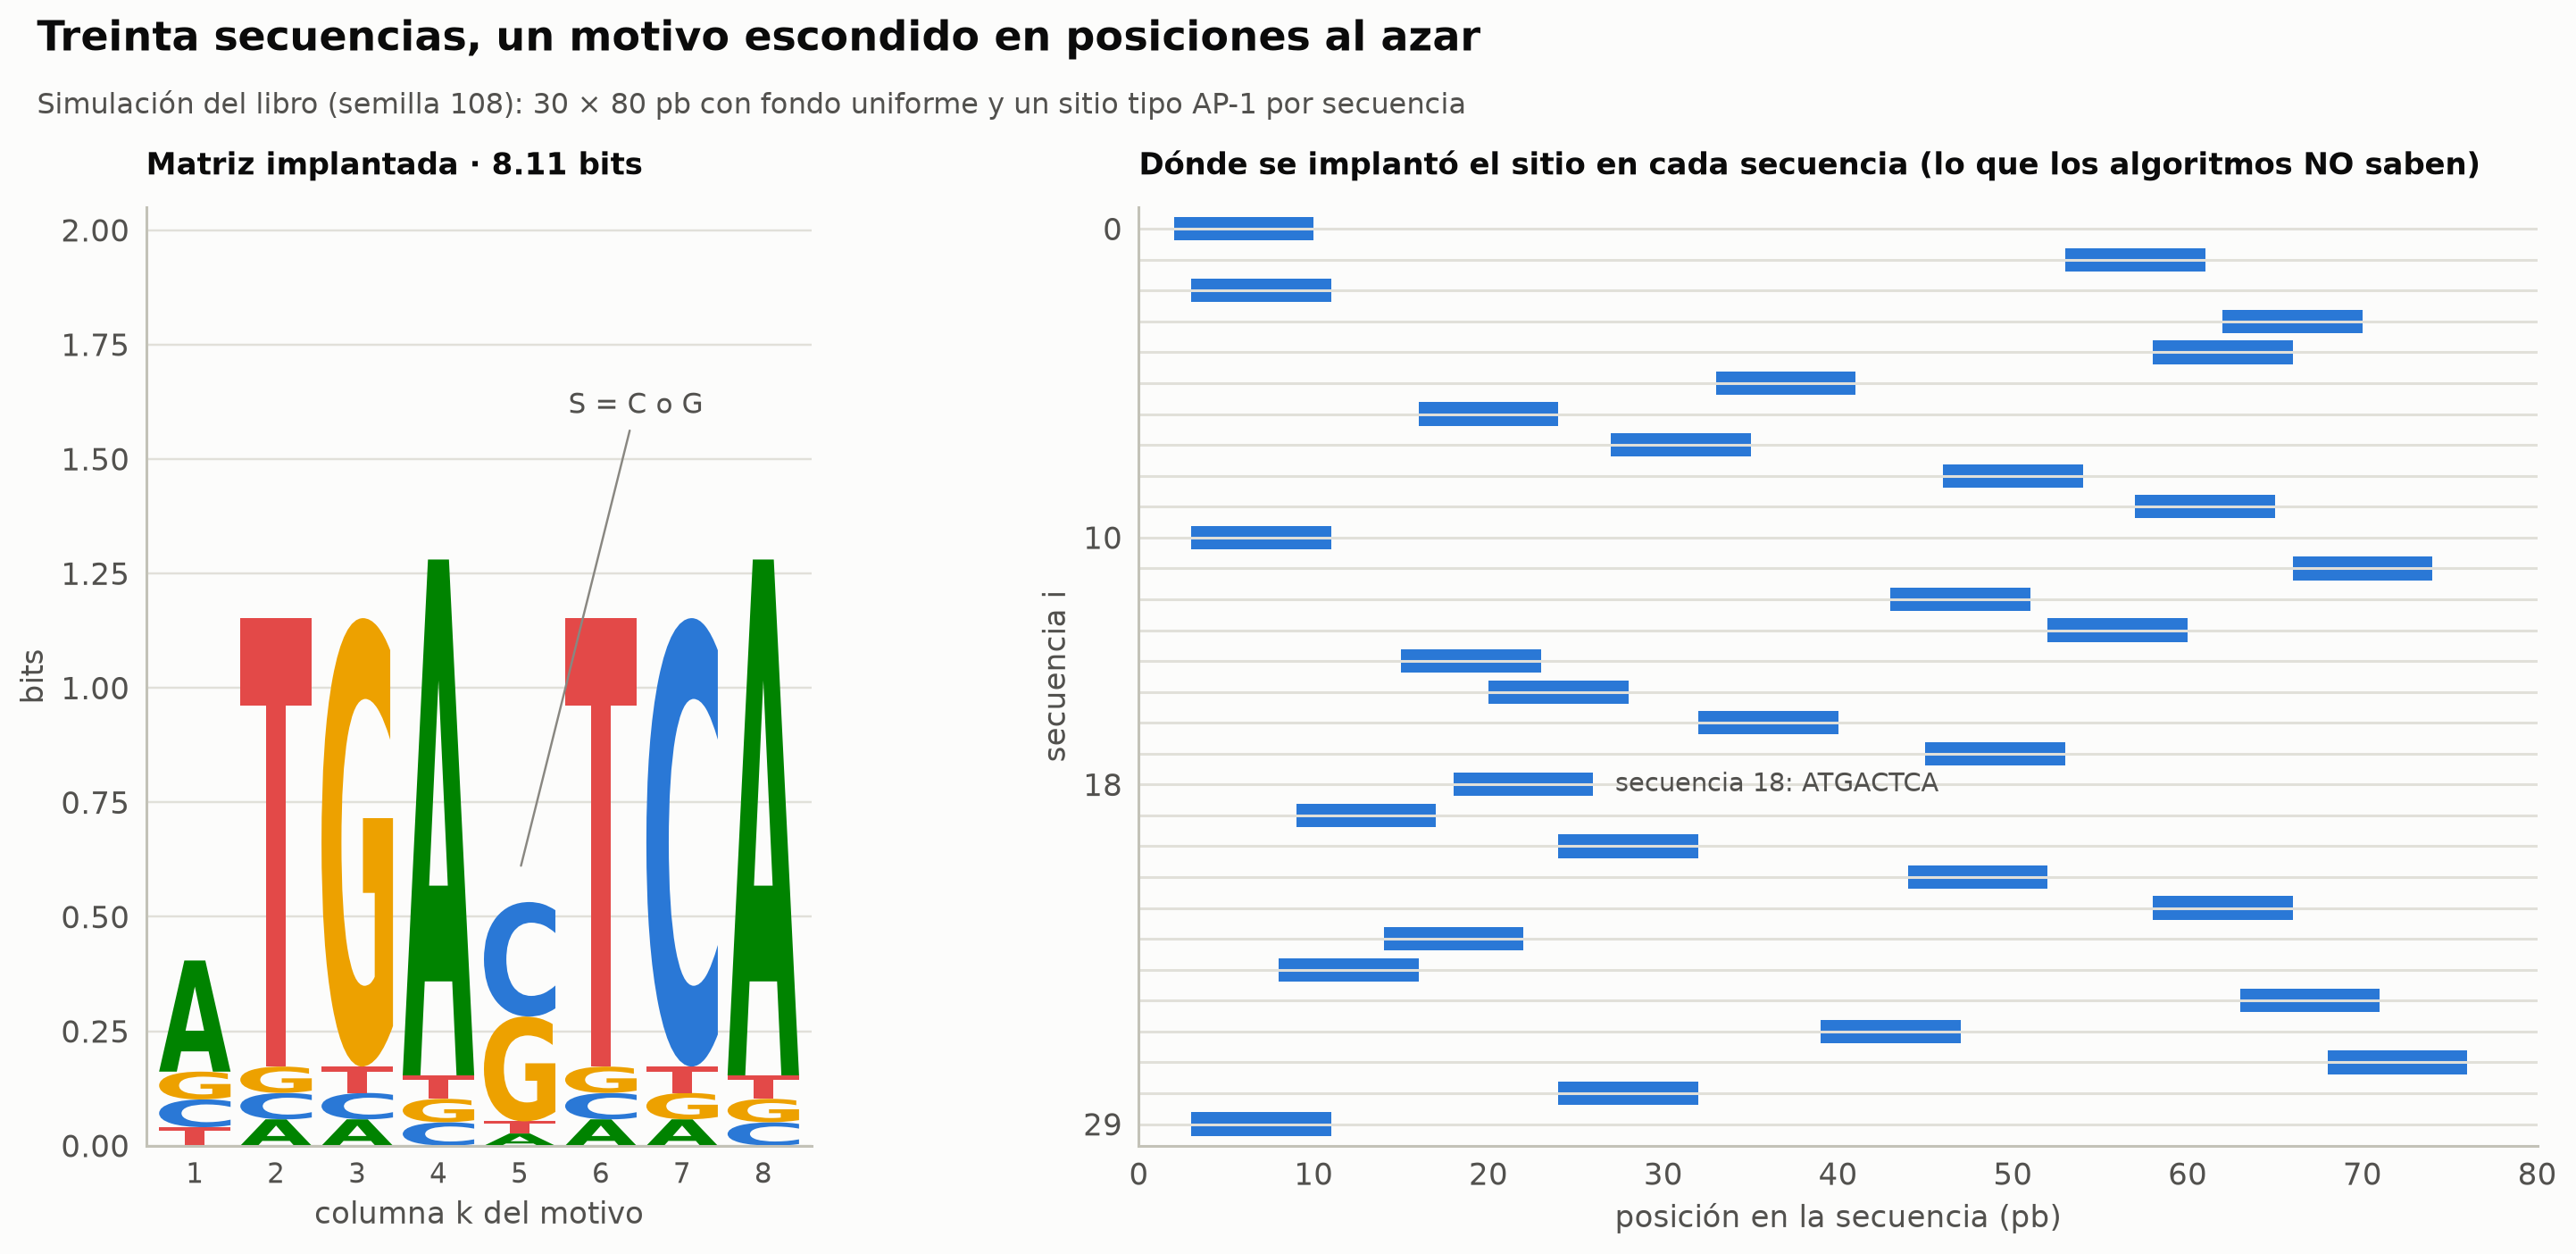

In [3]:
fig = plt.figure(figsize=(13, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.1], wspace=0.18)
ax_logo = fig.add_subplot(gs[0]); ax_seq = fig.add_subplot(gs[1])
draw_logo(ax_logo, TRUE, title=f"Matriz implantada · {ic(TRUE):.2f} bits")
ax_logo.annotate("S = C o G", (5, 0.6), xytext=(5.6, 1.6), fontsize=10, color=ec.INK_2,
                 arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
for i in range(NSEQ):
    ax_seq.plot([0, LSEQ], [i, i], color=ec.GRID, lw=1)
    ax_seq.add_patch(Rectangle((sitio_real[i], i - 0.38), Wm, 0.76, color=ec.BLUE, lw=0))
ax_seq.set_xlim(0, LSEQ); ax_seq.set_ylim(NSEQ - 0.3, -0.7)
ax_seq.set_yticks([0, 10, 18, 29]); ax_seq.set_ylabel("secuencia i")
ax_seq.set_xlabel("posición en la secuencia (pb)"); ax_seq.grid(False)
ax_seq.annotate("secuencia 18: ATGACTCA", (sitio_real[18] + Wm, 18), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=ec.INK_2)
ax_seq.set_title("Dónde se implantó el sitio en cada secuencia (lo que los algoritmos NO saben)", fontsize=11, loc="left")
ec.fig_title(fig, "Treinta secuencias, un motivo escondido en posiciones al azar",
             "Simulación del libro (semilla 108): 30 × 80 pb con fondo uniforme y un sitio tipo AP-1 por secuencia")
plt.show()

> 🔎 **Qué observamos.** El logo del motivo implantado tiene $8{,}11$ bits en total: seis columnas casi fijas
> (`T`, `G`, `A`, `T`, `C`, `A`, entre 1,15 y 1,28 bits cada una), una primera columna más tolerante (0,4 bits) y la quinta, donde C y G
> se reparten el protagonismo (la "S" del consenso). Las posiciones de los sitios están repartidas al azar: nada en
> la secuencia los delata salvo su parecido estadístico entre sí. A simple vista, una secuencia con el sitio
> y una sin él son indistinguibles.

> ✅ **Compruebe su comprensión.** ¿Por qué la columna 5 aporta tan poca información (≈ 0,53 bits) aunque casi nunca
> tenga A ni T? *(Porque dos bases se reparten la probabilidad: $2+0{,}47\log_2 0{,}47+0{,}43\log_2 0{,}43+2\cdot
> 0{,}05\log_2 0{,}05\approx 0{,}53$ bits. Eliminar dos de cuatro opciones vale, como mucho, 1 bit.)*

## 3. Un paso E, cifra por cifra

El algoritmo EM (sección 4) alterna dos pasos. El **paso E** responde a esta pregunta: *si la matriz fuera
$\theta^{(t)}$, ¿con qué probabilidad empieza el sitio de la secuencia $i$ en cada posición $j$?* Por el teorema de
Bayes, con el inicio uniforme del modelo OOPS:

$$
Z_{ij}^{(t)} \;=\; \Pr\bigl(Z_{ij}=1\mid X_i,\theta^{(t)}\bigr) \;=\; \frac{r_{ij}(\theta^{(t)})}{\sum_{j'=1}^{m} r_{ij'}(\theta^{(t)})}.
$$

Cada secuencia tiene **un voto** que reparte entre sus $m$ posiciones en proporción a cuánto se parece cada ventana al
motivo actual. En lugar de decidir "el sitio está aquí", el paso E dice "estoy un 99 % seguro de que está aquí, un
0,2 % de que está allá…".

### Ejemplo del libro: «Un paso E»

En la simulación anterior, la **secuencia 18** (contando desde 0, como Python) contiene el sitio `ATGACTCA`, idéntico
al consenso, en la posición 18. Con la matriz verdadera y fondo uniforme, su puntuación es la suma, columna a columna,
de los pesos de la PWM impresa arriba:

$$
\log_2 r = \underbrace{1{,}26}_{A}+\underbrace{1{,}77}_{T}+\underbrace{1{,}77}_{G}+\underbrace{1{,}82}_{A}
+\underbrace{0{,}91}_{C}+\underbrace{1{,}77}_{T}+\underbrace{1{,}77}_{C}+\underbrace{1{,}82}_{A}\approx 12{,}87\ \text{bits},
$$

es decir, $r=2^{12{,}87}\approx 7500$: el sitio es unas **siete mil quinientas veces** más probable bajo el motivo que
bajo el fondo. Al normalizar sobre las 73 posiciones, el paso E le asigna $Z=0{,}9976$ y reparte el $0{,}24\,\%$
restante entre las otras 72. Pero no todos los sitios son tan claros: la **mediana** de las puntuaciones de los 30
sitios reales es de **8,65 bits**, y en las secuencias con sitios degenerados el paso E reparte el voto entre varias
posiciones. Cambiar una sola base (`ATGACTTA`) baja la puntuación a **8,78 bits**: de 7 500 a unas 440 veces.

> 🤔 **Antes de ejecutar, prediga.** En la secuencia 18, ¿cuánto vale el segundo $Z$ más grande? ¿Del orden de
> $10^{-1}$, $10^{-3}$ o $10^{-6}$? Piense que la segunda mejor ventana es, casi seguro, ruido aleatorio con 2 o 3 bases
> coincidentes.

In [4]:
# El paso E con la matriz verdadera, para todas las secuencias (en bits: log2 r = Σ log2 θ + 2W, pues p0 = 1/4)
lr_all = np.log2(TRUE[np.arange(Wm), win]).sum(-1) + 2 * Wm          # N x m
i_ej = int(np.argmax(lr_all[np.arange(NSEQ), sitio_real]))          # la secuencia con el sitio más claro
lr0 = lr_all[i_ej]
Z0 = np.exp2(lr0 - lr0.max()); Z0 /= Z0.sum()
sr = sitio_real[i_ej]
site = "".join(BASES[b] for b in win[i_ej, sr])
terms = [pwm_true[k, B_INDEX[b]] for k, b in enumerate(site)]
print(f"Secuencia {i_ej}, sitio real en j = {sr}: {site}")
print("  log2 r = " + " + ".join(f"{t:.2f}" for t in terms) + f" = {lr0[sr]:.2f} bits  →  r ≈ {2 ** lr0[sr]:,.0f}")
print(f"  Z en el sitio real = {Z0[sr]:.4f};  segundo mayor Z = {np.sort(Z0)[-2]:.2e};  suma de los otros 72 = {1 - Z0[sr]:.2e}")
print(f"Mediana de log2 r en los 30 sitios reales: {np.median(lr_all[np.arange(NSEQ), sitio_real]):.2f} bits")
print(f"Una base cambiada, ATGACTTA: {sum(pwm_true[k, B_INDEX[b]] for k, b in enumerate('ATGACTTA')):.2f} bits")

# Una secuencia con sitio degenerado: la de menor puntuación en su sitio real
i_weak = int(np.argmin(lr_all[np.arange(NSEQ), sitio_real]))
Zw = np.exp2(lr_all[i_weak] - lr_all[i_weak].max()); Zw /= Zw.sum()
print(f"\nSecuencia {i_weak} (sitio más degenerado): log2 r en el sitio real = {lr_all[i_weak, sitio_real[i_weak]]:.2f} bits, "
      f"Z en el sitio real = {Zw[sitio_real[i_weak]]:.3f}, máximo Z = {Zw.max():.3f} en j = {Zw.argmax()}")

Secuencia 18, sitio real en j = 18: ATGACTCA
  log2 r = 1.26 + 1.77 + 1.77 + 1.82 + 0.91 + 1.77 + 1.77 + 1.82 = 12.87 bits  →  r ≈ 7,471
  Z en el sitio real = 0.9976;  segundo mayor Z = 1.56e-03;  suma de los otros 72 = 2.39e-03
Mediana de log2 r en los 30 sitios reales: 8.65 bits
Una base cambiada, ATGACTTA: 8.78 bits

Secuencia 5 (sitio más degenerado): log2 r en el sitio real = 1.09 bits, Z en el sitio real = 0.220, máximo Z = 0.315 en j = 53


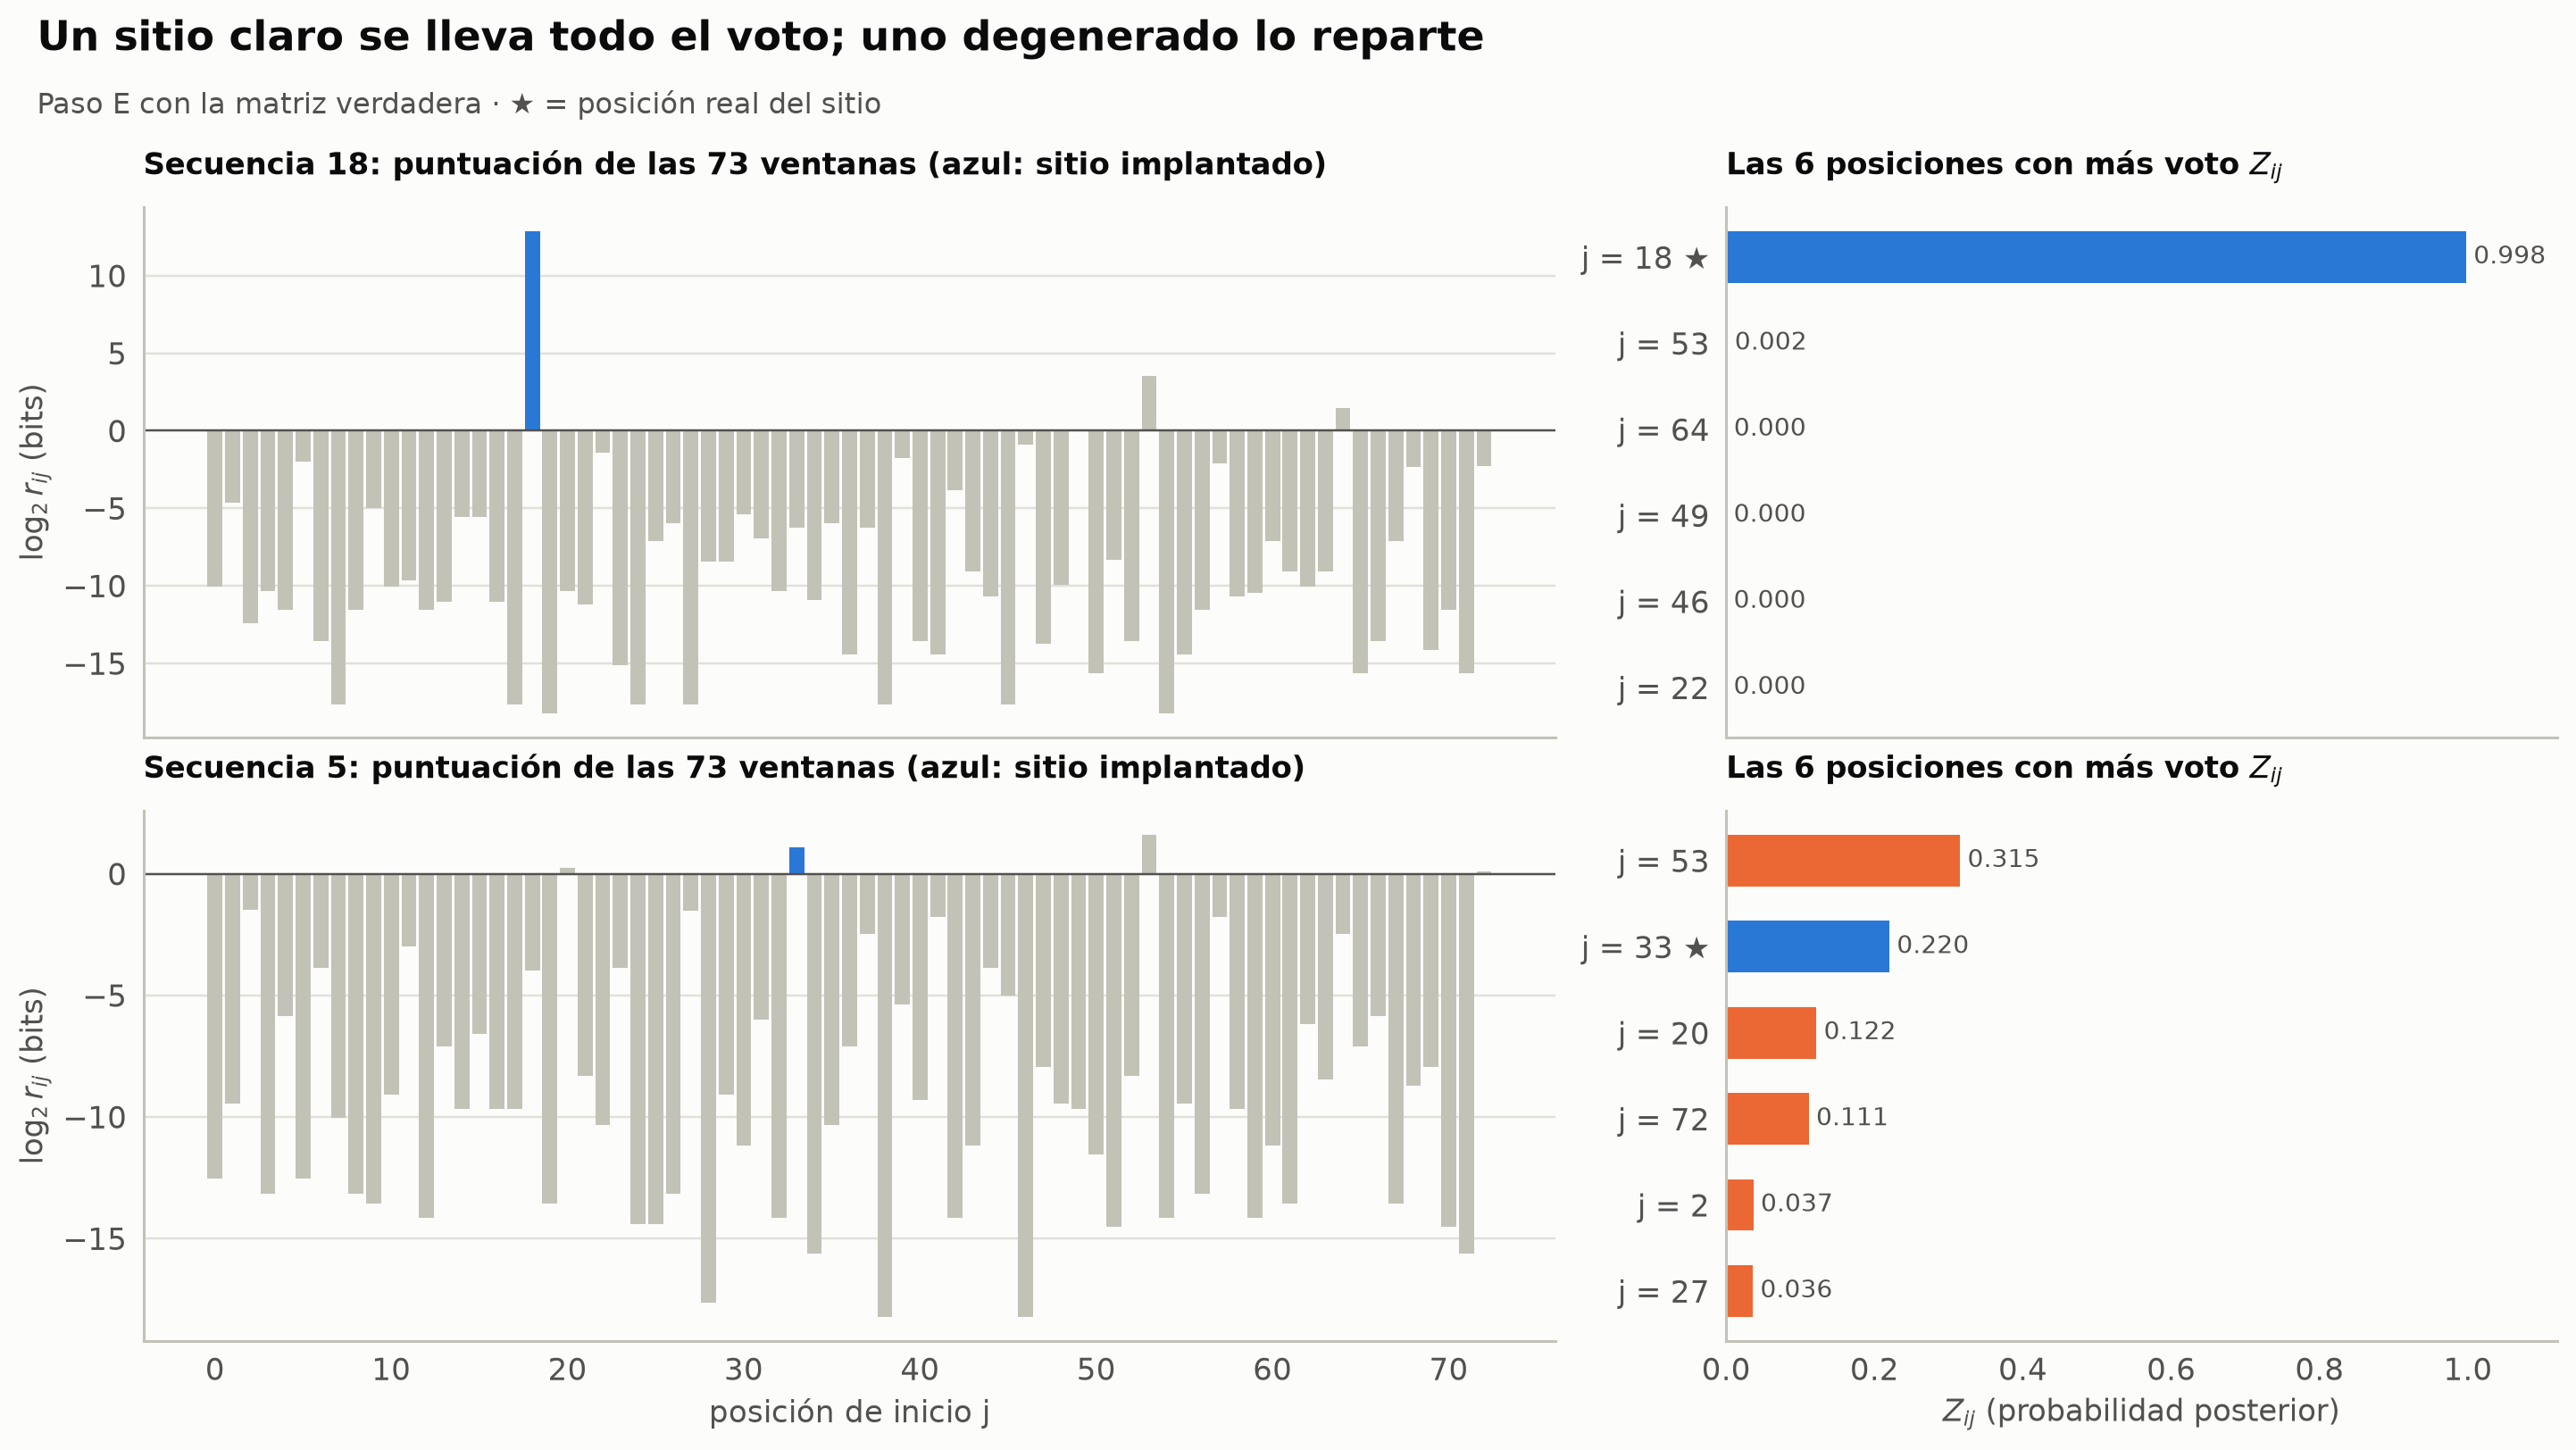

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.6), height_ratios=[1, 1], sharex="col", width_ratios=[1.7, 1])
for row, (i, Zi) in enumerate([(i_ej, Z0), (i_weak, Zw)]):
    ax = axes[row, 0]
    ax.bar(np.arange(M), lr_all[i], color=np.where(np.arange(M) == sitio_real[i], ec.BLUE, ec.BASELINE), width=0.85)
    ax.axhline(0, color=ec.INK_2, lw=0.8)
    ax.set_ylabel("log$_2\\,r_{ij}$ (bits)")
    ax.set_title(f"Secuencia {i}: puntuación de las {M} ventanas (azul: sitio implantado)", fontsize=11, loc="left")
    axz = axes[row, 1]
    top = np.argsort(Zi)[::-1][:6]
    axz.barh([f"j = {j}" + (" ★" if j == sitio_real[i] else "") for j in top], Zi[top],
             color=[ec.BLUE if j == sitio_real[i] else ec.ORANGE for j in top], height=0.6)
    axz.invert_yaxis(); axz.set_xlim(0, 1.12)
    for y, j in enumerate(top):
        axz.text(Zi[j] + 0.01, y, f"{Zi[j]:.3f}", va="center", fontsize=9, color=ec.INK_2)
    axz.set_title("Las 6 posiciones con más voto $Z_{ij}$", fontsize=11, loc="left")
    axz.grid(axis="y", visible=False)
axes[1, 0].set_xlabel("posición de inicio j"); axes[1, 1].set_xlabel("$Z_{ij}$ (probabilidad posterior)")
ec.fig_title(fig, "Un sitio claro se lleva todo el voto; uno degenerado lo reparte",
             "Paso E con la matriz verdadera · ★ = posición real del sitio")
plt.show()

> 🔎 **Qué observamos.** En la secuencia 18 una sola barra sobresale: el sitio perfecto tiene 12,87 bits mientras que
> la mejor ventana de ruido apenas llega a unos 3–4 bits. Como $Z$ depende de $2^{\log_2 r}$, una diferencia de 9 bits
> se convierte en un factor $2^9\approx 500$, y el sitio se lleva el 99,76 % del voto. En la secuencia más degenerada,
> en cambio, el sitio real compite con ventanas de ruido de puntuación parecida y el voto se reparte: el paso E
> **admite su incertidumbre** en lugar de apostar todo a una posición. Esa es la diferencia entre EM y un método que
> elige "la mejor ventana" de forma dura.

> ✅ **Compruebe su comprensión.** Si duplicáramos la longitud de las secuencias ($L=160$), ¿qué le pasaría al $Z$ del
> sitio de la secuencia 18? *(Bajaría un poco: hay el doble de ventanas de ruido que compiten en el denominador, pero
> como cada una aporta muy poco, $Z$ seguiría por encima de 0,99. Con secuencias muy largas, en cambio, incluso los
> sitios claros empiezan a diluirse: por eso se recortan los picos a ±50 pb alrededor de la cumbre.)*

## 4. El algoritmo EM (y lo que hace MEME además)

Si conociéramos las $Z_{ij}$, estimar $\theta$ sería **contar**; si conociéramos $\theta$, localizar los sitios sería
**escanear** con la PWM. Dempster, Laird y Rubin (1977) formularon en general el algoritmo de
**esperanza-maximización** (EM) para problemas con datos faltantes, y convierte esta circularidad en un procedimiento
con garantías. Aplicado a motivos, dada una estimación $\theta^{(t)}$ alterna:

$$
\textbf{Paso E:}\quad Z_{ij}^{(t)} = \frac{r_{ij}(\theta^{(t)})}{\sum_{j'=1}^{m} r_{ij'}(\theta^{(t)})}
$$

$$
\textbf{Paso M:}\quad \theta^{(t+1)}_{k,b} \;=\;
\frac{\sum_{i}\sum_{j} Z_{ij}^{(t)}\,\mathbb 1\bigl[x_{i,j+k-1}=b\bigr] + \beta_b}
     {\sum_{b'}\Bigl(\sum_{i}\sum_{j} Z_{ij}^{(t)}\,\mathbb 1\bigl[x_{i,j+k-1}=b'\bigr] + \beta_{b'}\Bigr)}
$$

Con $\beta_b=0$, cada iteración **no disminuye** la verosimilitud: $\mathrm{LLR}(\theta^{(t+1)})\ge\mathrm{LLR}(\theta^{(t)})$.

| Símbolo | Significado |
|---|---|
| $\theta^{(t)}$ | la matriz del motivo en la iteración $t$ |
| $Z_{ij}^{(t)}$ | probabilidad posterior de que el sitio de la secuencia $i$ empiece en $j$: un **conteo fraccionario** |
| $\mathbb 1[\cdot]$ | función indicadora: vale 1 si la condición se cumple y 0 si no |
| $\beta_b$ | seudoconteos (a priori de Dirichlet) que evitan probabilidades nulas |

**En palabras.** El paso E reparte cada secuencia entre sus posiciones posibles en proporción a cuánto se parecen al
motivo actual: en vez de decidir dónde está el sitio, **reparte votos**. El paso M construye una nueva PWM con esos
votos fraccionarios: cada ventana aporta sus 8 letras a la matriz de conteos, pero pesadas por su $Z_{ij}$. Una
ventana con $Z=0{,}9976$ cuenta casi como un sitio entero; una con $Z=0{,}0001$, casi nada.

**Un paso M a mano.** Suponga dos secuencias. En la primera, el paso E reparte 0,9 del voto a una ventana que empieza
por A y 0,1 a otra que empieza por G; en la segunda, 0,6 a una ventana que empieza por A y 0,4 a otra que empieza por C.
Sin seudoconteos, la columna 1 de la nueva matriz es: A $=(0{,}9+0{,}6)/2=0{,}75$, C $=0{,}4/2=0{,}20$,
G $=0{,}1/2=0{,}05$, T $=0$. Con $\beta_b=0{,}1$ para cada base, T pasa a $0{,}1/2{,}4\approx 0{,}04$ en vez de un
peligroso cero.

**¿Por qué nunca empeora?** La garantía viene de la **desigualdad de Jensen**. Para cualquier distribución $q$ sobre
las variables ocultas,

$$
\log\Pr(X\mid\theta)\;\ge\;\sum_{Z} q(Z)\,\log\frac{\Pr(X,Z\mid\theta)}{q(Z)},
$$

con igualdad cuando $q$ es la posterior $\Pr(Z\mid X,\theta)$. El paso E elige justamente esa $q$ y hace la cota
**exacta** en $\theta^{(t)}$; el paso M **maximiza** la cota en $\theta$. Por tanto, la verosimilitud en
$\theta^{(t+1)}$ es al menos la cota, que es al menos la verosimilitud en $\theta^{(t)}$. Es como subir una montaña en
la niebla apoyándose en una cuerda tendida bajo sus pies: cada paso sobre la cuerda es seguro, pero nadie le promete
que esa montaña sea la más alta de la cordillera. Lo que EM **no** garantiza es el **máximo global**.

El código es el del libro (función `em_oops`), con dos añadidos para poder dibujar: guarda la $\mathrm{LLR}$ y la
matriz de cada iteración.

In [6]:
def ll_ratio(theta, windows=win, p0=p0):
    """LLR(θ) en bits (ecuación OOPS) y la matriz log2 r_ij (N x m). Usa el truco log-suma-exp en base 2."""
    W = theta.shape[0]
    lr = (np.log2(theta[np.arange(W), windows]) - np.log2(p0)[windows]).sum(-1)
    mx = lr.max(1, keepdims=True)
    return float((np.log2(np.exp2(lr - mx).mean(1)) + mx[:, 0]).sum()), lr

def em(theta, iters=30, beta=0.1, windows=win, p0=p0):
    """EM para el modelo OOPS. Devuelve θ final, la trayectoria de LLR y la lista de matrices por iteración."""
    W = theta.shape[0]
    tray, thetas = [], [theta]
    for _ in range(iters):
        ll, lr = ll_ratio(theta, windows, p0)
        tray.append(ll)
        Z = np.exp2(lr - lr.max(1, keepdims=True))                   # paso E
        Z /= Z.sum(1, keepdims=True)
        cnt = np.stack([(Z[..., None] * (windows == b)).sum((0, 1)) for b in range(4)], 1)   # paso M
        theta = (cnt + beta) / (cnt + beta).sum(1, keepdims=True)
        thetas.append(theta)
    tray.append(ll_ratio(theta, windows, p0)[0])
    return theta, tray, Z, thetas

def seed_matrix(km, fuerza=0.5):
    """Matriz inicial a partir de una palabra: 0,5 para su base en cada columna y el resto repartido."""
    th = np.full((len(km), 4), (1 - fuerza) / 3)
    th[np.arange(len(km)), km] = fuerza
    return th

# Seis corridas, como en el libro: cinco semillas al azar y una subcadena de un sitio real (lo que haría MEME)
rng_em = np.random.default_rng(7)
em_res = []
for r in range(6):
    if r == 5:
        i0 = 12
        km = seqs[i0, sitio_real[i0]:sitio_real[i0] + Wm]
    else:
        i0 = rng_em.integers(NSEQ); j0 = rng_em.integers(M)
        km = seqs[i0, j0:j0 + Wm]
    th0 = seed_matrix(km)
    th, tray, Z, thetas = em(th0)
    em_res.append(dict(seed="".join(BASES[b] for b in km), theta=th, tray=tray, Z=Z, thetas=thetas))
    print(f"corrida {r}: semilla={em_res[-1]['seed']}  LLR0={tray[0]:6.1f}  LLR final={tray[-1]:5.1f} bits  "
          f"IC={ic(th):.2f}  consenso={kmer(th)}")

best_r = int(np.argmax([e["tray"][-1] for e in em_res[:5]]))          # mejor corrida con semilla aleatoria
th_best, Zb = em_res[best_r]["theta"], em_res[best_r]["Z"]
llr_true = ll_ratio(TRUE)[0]
print(f"\nMejor corrida con semilla aleatoria: {best_r} · sitios recuperados en la posición exacta: "
      f"{int((Zb.argmax(1) == sitio_real).sum())}/{NSEQ}")
print(f"IC: semilla={ic(em_res[best_r]['thetas'][0]):.2f}  it6={ic(em_res[best_r]['thetas'][6]):.2f}  "
      f"it8={ic(em_res[best_r]['thetas'][8]):.2f}  final={ic(th_best):.2f}  verdadero={ic(TRUE):.2f} bits")
print(f"LLR de la matriz verdadera: {llr_true:.1f} bits  ·  LLR de la solución de EM: {em_res[best_r]['tray'][-1]:.1f} bits")

corrida 0: semilla=GGGGGAGC  LLR0=  -1.8  LLR final= 56.5 bits  IC=7.03  consenso=GAGTCATC
corrida 1: semilla=TGGAATAT  LLR0=  -3.7  LLR final= 83.4 bits  IC=7.96  consenso=TGAGTCAT
corrida 2: semilla=TTCCCTTA  LLR0=  -0.3  LLR final= 96.4 bits  IC=8.75  consenso=ATGAGTCA
corrida 3: semilla=AAGCCAGC  LLR0=  -1.2  LLR final= 56.5 bits  IC=7.03  consenso=GAGTCATC
corrida 4: semilla=TCCTAGTA  LLR0=  -1.0  LLR final= 77.5 bits  IC=7.99  consenso=CATGACTC
corrida 5: semilla=ATCAGTCA  LLR0=  10.5  LLR final= 96.4 bits  IC=8.75  consenso=ATGAGTCA

Mejor corrida con semilla aleatoria: 2 · sitios recuperados en la posición exacta: 26/30
IC: semilla=1.66  it6=3.19  it8=6.39  final=8.75  verdadero=8.11 bits
LLR de la matriz verdadera: 76.1 bits  ·  LLR de la solución de EM: 96.4 bits


Antes de mirar la figura, verifiquemos la promesa del teorema. Con $\beta_b=0$ la verosimilitud nunca baja; con los
seudoconteos $\beta_b=0{,}1$ que usa el libro el algoritmo maximiza, en rigor, la verosimilitud **más** un término a
priori, y la $\mathrm{LLR}$ pura podría bajar en milésimas de bit.

In [7]:
for beta in [0.0, 0.1]:
    difs = np.concatenate([np.diff(em(e["thetas"][0], beta=beta)[1]) for e in em_res])
    print(f"β = {beta}:  mínimo incremento de LLR entre iteraciones = {difs.min():+.2e} bits "
          f"({(difs < -1e-9).sum()} de {difs.size} pasos bajan)")

β = 0.0:  mínimo incremento de LLR entre iteraciones = +3.63e-03 bits (0 de 180 pasos bajan)
β = 0.1:  mínimo incremento de LLR entre iteraciones = +4.47e-04 bits (0 de 180 pasos bajan)


Ahora la figura interactiva. Pase el cursor por cada curva: verá, en cada iteración, el **consenso** que tenía la
matriz y su **contenido de información**.

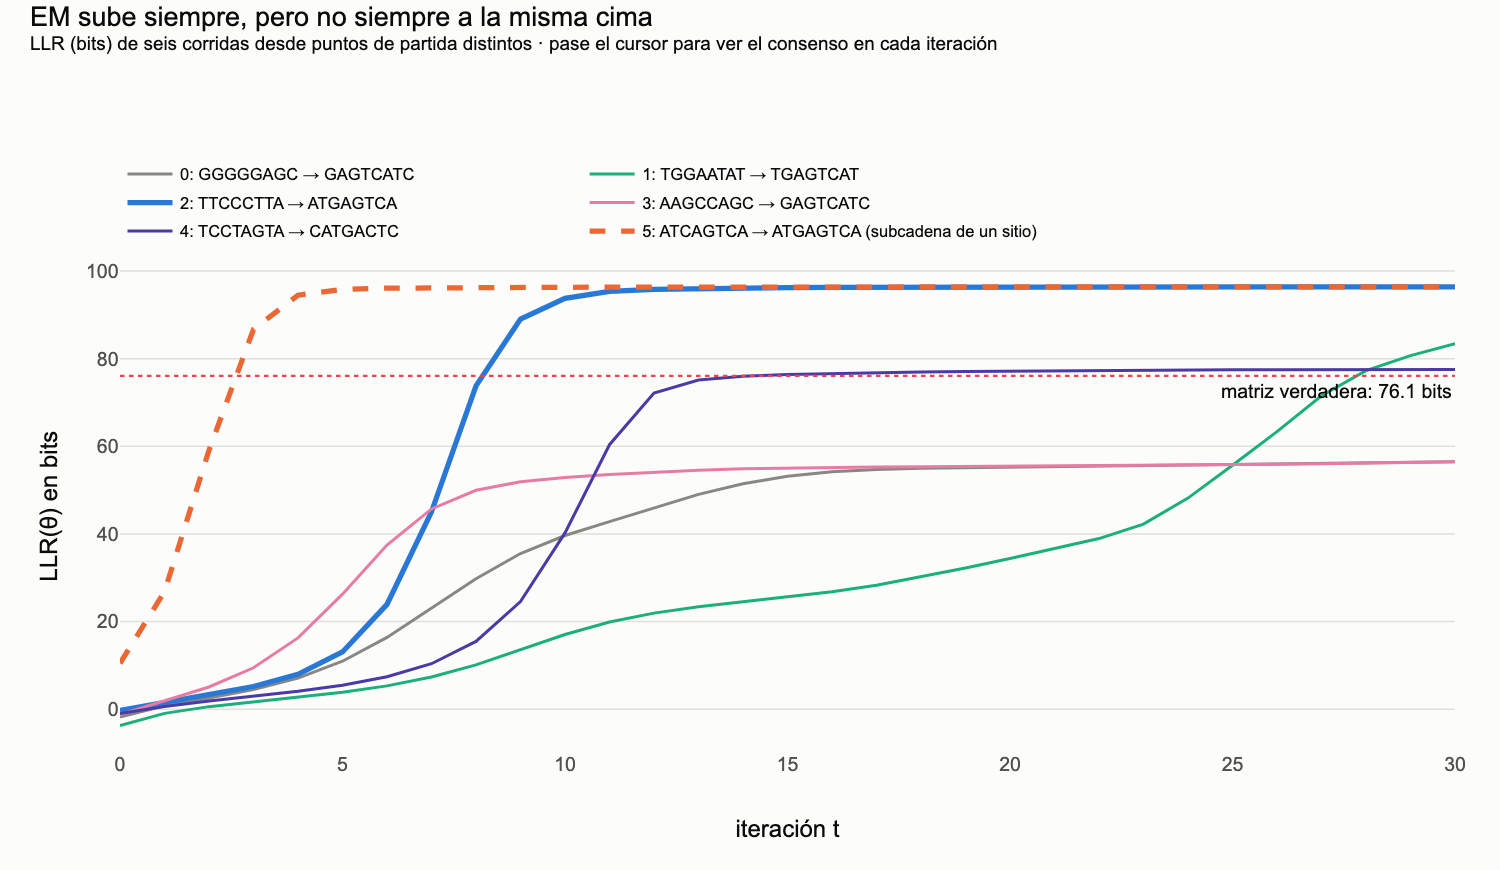

In [8]:
cols6 = [ec.MUTED, ec.AQUA, ec.BLUE, ec.MAGENTA, ec.VIOLET, ec.ORANGE]
fig = go.Figure()
for r, e in enumerate(em_res):
    its = np.arange(len(e["tray"]))
    hover = [f"<b>corrida {r}</b> · semilla <tt>{e['seed']}</tt><br>iteración {t}<br>LLR = {v:.1f} bits"
             f"<br>consenso actual: <tt>{kmer(th)}</tt><br>información: {ic(th):.2f} bits"
             for t, (v, th) in enumerate(zip(e["tray"], e["thetas"]))]
    name = f"{r}: {e['seed']} → {kmer(e['theta'])}" + (" (subcadena de un sitio)" if r == 5 else "")
    fig.add_trace(go.Scatter(x=its, y=e["tray"], mode="lines", name=name, text=hover,
                             hovertemplate="%{text}<extra></extra>",
                             line=dict(color=cols6[r], width=3.5 if r in (best_r, 5) else 2,
                                       dash="dash" if r == 5 else "solid")))
fig.add_hline(y=llr_true, line=dict(color=ec.RED, dash="dot", width=1.5),
              annotation_text=f"matriz verdadera: {llr_true:.1f} bits", annotation_position="bottom right")
fig.update_layout(
    title="EM sube siempre, pero no siempre a la misma cima<br><sup>LLR (bits) de seis corridas desde "
          "puntos de partida distintos · pase el cursor para ver el consenso en cada iteración</sup>",
    title_y=0.97, title_yanchor="top",
    xaxis_title="iteración t", yaxis_title="LLR(θ) en bits", height=580, margin=dict(t=175, r=30),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, font=dict(size=11)))
fig.show()

> 🔎 **Qué observamos.** Todas las curvas son **crecientes**, como garantiza el teorema, pero terminan en **tres
> destinos**. Dos corridas alcanzan la verosimilitud máxima encontrada, $\mathrm{LLR}=96{,}4$ bits, con el consenso
> `ATGAGTCA` (la S del motivo admite C o G): la mejor semilla aleatoria (`TTCCCTTA`) y la subcadena de un sitio real
> (naranja discontinua), que llega en dos o tres iteraciones. Otras quedan atrapadas en versiones **desfasadas** del
> motivo (`TGAGTCAT`, `CATGACTC`), que capturan sólo siete de las ocho columnas, o en un óptimo local pobre
> ($\mathrm{LLR}=56{,}5$, `GAGTCATC`). La corrida ganadora tiene forma de **S**: durante unas cinco iteraciones apenas
> mejora, hasta que un puñado de sitios reales "tira" de la matriz y el resto la sigue en cascada.
>
> Una sorpresa instructiva: la solución de EM tiene **más** verosimilitud (96,4 bits) que la matriz con la que se
> generaron los datos (76,1), y más información (8,75 frente a 8,11 bits). Con sólo 30 sitios, la máxima verosimilitud
> **sobreajusta**: hace el motivo más nítido de lo que es, porque se adapta a las casualidades de estas 30 copias.
> 26 de los 30 sitios se recuperan en la posición exacta.

### Lo que MEME añade

El programa **MEME**, presentado por Bailey y Elkan en 1994 y hoy núcleo de la **MEME Suite** (Bailey et al., 2009),
es la implementación de referencia de esta idea. Añade tres ingredientes decisivos:

1. **Modelos más realistas que OOPS**: **ZOOPS** (*zero or one occurrence per sequence*), que admite secuencias sin
   sitio (un pico de ChIP-seq puede deberse a unión indirecta), y **TCM** (*two-component mixture*), que admite
   cualquier número de sitios por secuencia.
2. **Inicialización con subcadenas reales**: en lugar de partir de una matriz aleatoria, prueba como semillas
   subcadenas de los datos, corre una iteración corta desde cada una y lanza EM completo sólo desde las más
   prometedoras. Nuestra corrida 5 muestra por qué funciona: desde un sitio verdadero se llega a la cima en muy pocas
   iteraciones.
3. **Un criterio estadístico** (el valor $E$ del motivo) para decidir cuántos motivos reportar y de qué ancho.

> ✅ **Compruebe su comprensión.** ¿Por qué el desfase `TGAGTCAT` es un óptimo local "estable"? *(Porque comparte
> siete columnas con el motivo verdadero: pasar a `ATGAGTCA` exige mover **todos** los votos una posición a la
> izquierda a la vez, y cualquier movimiento parcial empeora la verosimilitud. EM sólo da pasos locales.)*

## 5. 🎬 Un motivo emerge del ruido: el logo iteración a iteración

Sigamos la corrida ganadora con semilla aleatoria (`TTCCCTTA`). En cada cuadro vemos tres cosas a la vez: el **logo**
de $\theta^{(t)}$, la **curva** de $\mathrm{LLR}$ y el **mapa de votos** $Z_{ij}^{(t)}$ del paso E (una fila por
secuencia; los marcos negros señalan los sitios implantados).

![EM desde la semilla aleatoria TTCCCTTA: durante unas cinco iteraciones el logo es casi plano; después los votos se concentran en los sitios reales y el motivo ATGAGTCA aparece de golpe](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-13-epigenomica/13.3_em_logo.gif)

*EM desde la semilla aleatoria TTCCCTTA: durante unas cinco iteraciones el logo es casi plano; después los votos se concentran en los sitios reales y el motivo ATGAGTCA aparece de golpe*

In [9]:
e = em_res[best_r]
# Recalcular Z de cada iteración (paso E aplicado a cada θ^(t))
Z_hist = []
for th in e["thetas"]:
    lr = ll_ratio(th)[1]
    Zt = np.exp2(lr - lr.max(1, keepdims=True)); Z_hist.append(Zt / Zt.sum(1, keepdims=True))

from matplotlib.colors import LinearSegmentedColormap
CMAP_Z = LinearSegmentedColormap.from_list("votos", ["#ffffff"] + ec.SEQ_BLUE)   # blanco = sin voto
fig = plt.figure(figsize=(12, 7.2))
fig.set_layout_engine("none")
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.25], width_ratios=[1, 1.25], hspace=0.45, wspace=0.22,
                      left=0.06, right=0.98, top=0.94, bottom=0.08)
ax_logo, ax_ll, ax_z = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])

def update(t):
    for a in (ax_logo, ax_ll, ax_z):
        a.clear()
    th = e["thetas"][t]
    draw_logo(ax_logo, th, title=f"Iteración {t} · consenso {kmer(th)} · {ic(th):.2f} bits")
    ax_ll.plot(range(len(e["tray"])), e["tray"], color=ec.BASELINE, lw=1.5)
    ax_ll.plot(range(t + 1), e["tray"][:t + 1], color=ec.BLUE, lw=2.5)
    ax_ll.plot(t, e["tray"][t], "o", color=ec.BLUE, ms=8)
    ax_ll.axhline(llr_true, color=ec.RED, ls="--", lw=1)
    ax_ll.text(30, llr_true - 4, "matriz verdadera", ha="right", va="top", fontsize=9, color=ec.INK_2)
    ax_ll.set_xlim(0, 30); ax_ll.set_ylim(-10, 108)
    ax_ll.set_xlabel("iteración"); ax_ll.set_ylabel("LLR (bits)")
    ax_ll.set_title(f"LLR = {e['tray'][t]:.1f} bits", fontsize=11, loc="left")
    ax_z.imshow(Z_hist[t], aspect="auto", cmap=CMAP_Z, vmin=0, vmax=1, interpolation="nearest")
    for i in range(NSEQ):
        ax_z.add_patch(Rectangle((sitio_real[i] - 0.5, i - 0.5), 1, 1, fill=False, ec=ec.INK, lw=0.9))
    hits = int((Z_hist[t].argmax(1) == sitio_real).sum())
    ax_z.set_title(f"Votos del paso E, $Z_{{ij}}$ (oscuro = voto alto) · sitios recuperados: {hits}/{NSEQ}",
                   fontsize=11, loc="left")
    ax_z.set_xlabel("posición de inicio j"); ax_z.set_ylabel("secuencia i"); ax_z.grid(False)
    return ()

ec.animate(fig, update, frames=len(e["thetas"]), interval=350, name="13.3_em_logo")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En la iteración 0 la matriz es sólo la palabra semilla, con 1,66 bits, y los votos están
> dispersos (el mapa es casi blanco). En la iteración 6 empiezan a asomar la G, la A y la T centrales (3,19 bits); en
> la iteración 8 el motivo ya es reconocible (6,39 bits), y a partir de ahí los votos se concentran casi de golpe en
> los marcos negros. Al converger (8,75 bits), el logo coincide con el implantado. La curva en S de la $\mathrm{LLR}$ y
> la aparición del motivo son el mismo fenómeno visto desde dos ángulos: una **reacción en cadena** en la que cada
> sitio bien colocado hace más nítida la matriz y la matriz más nítida encuentra más sitios.

## 6. El muestreador de Gibbs y los desfases

Lawrence et al. (1993) abordaron el mismo problema con una estrategia **estocástica**, el *muestreador de sitios* de
Gibbs (la lección 4.2 lo usó para redescubrir la secuencia de Shine-Dalgarno). En lugar de probabilidades
fraccionarias, mantiene una **asignación concreta** $a=(a_1,\dots,a_N)$ de la posición del sitio en cada secuencia y
la actualiza de una en una:

1. Elija una secuencia $z$ y **retire** su sitio del alineamiento.
2. Construya la matriz con los $N-1$ sitios restantes y seudoconteos:
$$
q_{k,b} \;=\; \frac{\sum_{i\ne z}\mathbb 1\bigl[x_{i,a_i+k-1}=b\bigr]+\beta_b}{N-1+\sum_{b'}\beta_{b'}} .
$$
3. **Muestree** una nueva posición para $z$ de la distribución condicional
$$
\Pr\bigl(a_z=j\mid a_{-z},X\bigr) \;\propto\; \prod_{k=1}^{W}\frac{q_{k,\,x_{z,j+k-1}}}{p_0(x_{z,j+k-1})},\qquad j=1,\dots,m .
$$
4. Repita para todas las secuencias (un **barrido**) hasta que la verosimilitud se estabilice.

| Símbolo | Significado |
|---|---|
| $a_i$ | posición asignada al sitio de la secuencia $i$ |
| $a_{-z}$ | posiciones de todas las secuencias excepto $z$ |
| $q_{k,b}$ | matriz estimada **sin** la secuencia $z$ |
| $\beta_b$ | seudoconteos (aquí 0,25 por base) |

**La diferencia con EM es de fondo.** EM es determinista y sube siempre por la pendiente más cercana; Gibbs es una
**cadena de Márkov** cuya distribución estacionaria es la posterior de las posiciones, así que puede **bajar**
momentáneamente y saltar a otra colina. Observe que el paso 3 usa exactamente la misma fórmula que el paso E
(una razón de verosimilitudes), pero en lugar de **repartir** el voto, **sortea** una posición con esas
probabilidades. Retirar la secuencia $z$ antes de construir $q$ es esencial: si no, su propio sitio actual "votaría
por sí mismo" y la cadena se quedaría congelada.

**Un sorteo a mano.** Si en la secuencia $z$ tres ventanas tienen $\log_2 r = 6,\ 5,\ 1$ bits y todas las demás
$\approx 0$ (y hay 70 de ellas), las probabilidades son $\propto 64,\ 32,\ 2$ y $70\times 1$: la mejor ventana sale con
probabilidad $64/168\approx 0{,}38$, la segunda con $0{,}19$, y alguna ventana de ruido con $70/168\approx 0{,}42$.
Gibbs explora mucho más que EM, sobre todo al principio, cuando $q$ todavía es borrosa.

El código es el del libro, con una única optimización que no cambia los sorteos: la matriz de conteos se mantiene
actualizada (se resta y se suma el sitio de $z$) en lugar de recalcularse desde cero.

In [10]:
def gibbs(seed, sweeps=60, beta=0.25, windows=win, p0=p0, snapshot_every=None):
    """Muestreador de sitios de Gibbs (Lawrence et al. 1993) para el modelo OOPS, como en el libro."""
    g = np.random.default_rng(seed)
    N, m, W = windows.shape
    a = g.integers(0, m, N)
    cols = np.arange(W)
    total = np.zeros((W, 4))
    for i in range(N):
        total[cols, windows[i, a[i]]] += 1
    tray, snaps = [], []
    lp0 = np.log2(p0)
    for sw in range(sweeps):
        for n_upd, z in enumerate(g.permutation(N)):
            total[cols, windows[z, a[z]]] -= 1                    # 1. retirar el sitio de z
            q = (total + beta) / (total + beta).sum(1, keepdims=True)   # 2. matriz sin z
            lr = (np.log2(q[cols, windows[z]]) - lp0[windows[z]]).sum(-1)
            pr = np.exp2(lr - lr.max())
            a[z] = g.choice(m, p=pr / pr.sum())                   # 3. sortear la nueva posición
            total[cols, windows[z, a[z]]] += 1
            if snapshot_every and n_upd % snapshot_every == 0 and sw < 3:
                snaps.append((sw + n_upd / N, (total + beta) / (total + beta).sum(1, keepdims=True), a.copy()))
        q = (total + beta) / (total + beta).sum(1, keepdims=True)
        tray.append(ll_ratio(q, windows, p0)[0])
        if snapshot_every:
            snaps.append((sw + 1, q, a.copy()))
    return q, tray, a, snaps

t0 = time.perf_counter()
gb = []
for sd in [1, 2, 3, 4]:
    q, tray, a, _ = gibbs(sd)
    gb.append(dict(q=q, tray=tray, a=a))
    first95 = next(k for k, v in enumerate(tray) if v >= 0.95 * max(tray))
    print(f"cadena {sd}: LLR final={tray[-1]:5.1f}  exactos={int((a == sitio_real).sum()):2d}/30  "
          f"a ±2 pb={int((np.abs(a - sitio_real) <= 2).sum()):2d}  consenso={kmer(q)}  "
          f"primer barrido con ≥95 % del máximo: {first95}")
print(f"({time.perf_counter() - t0:.1f} s para 4 cadenas × 60 barridos)")

cadena 1: LLR final= 36.2  exactos= 0/30  a ±2 pb= 0  consenso=AGTAATAG  primer barrido con ≥95 % del máximo: 38
cadena 2: LLR final= 50.3  exactos= 0/30  a ±2 pb=16  consenso=ACATGAGT  primer barrido con ≥95 % del máximo: 19
cadena 3: LLR final= 50.5  exactos= 0/30  a ±2 pb=19  consenso=CCATGAGT  primer barrido con ≥95 % del máximo: 8


cadena 4: LLR final= 89.8  exactos=22/30  a ±2 pb=22  consenso=ATGACTCA  primer barrido con ≥95 % del máximo: 6
(0.3 s para 4 cadenas × 60 barridos)


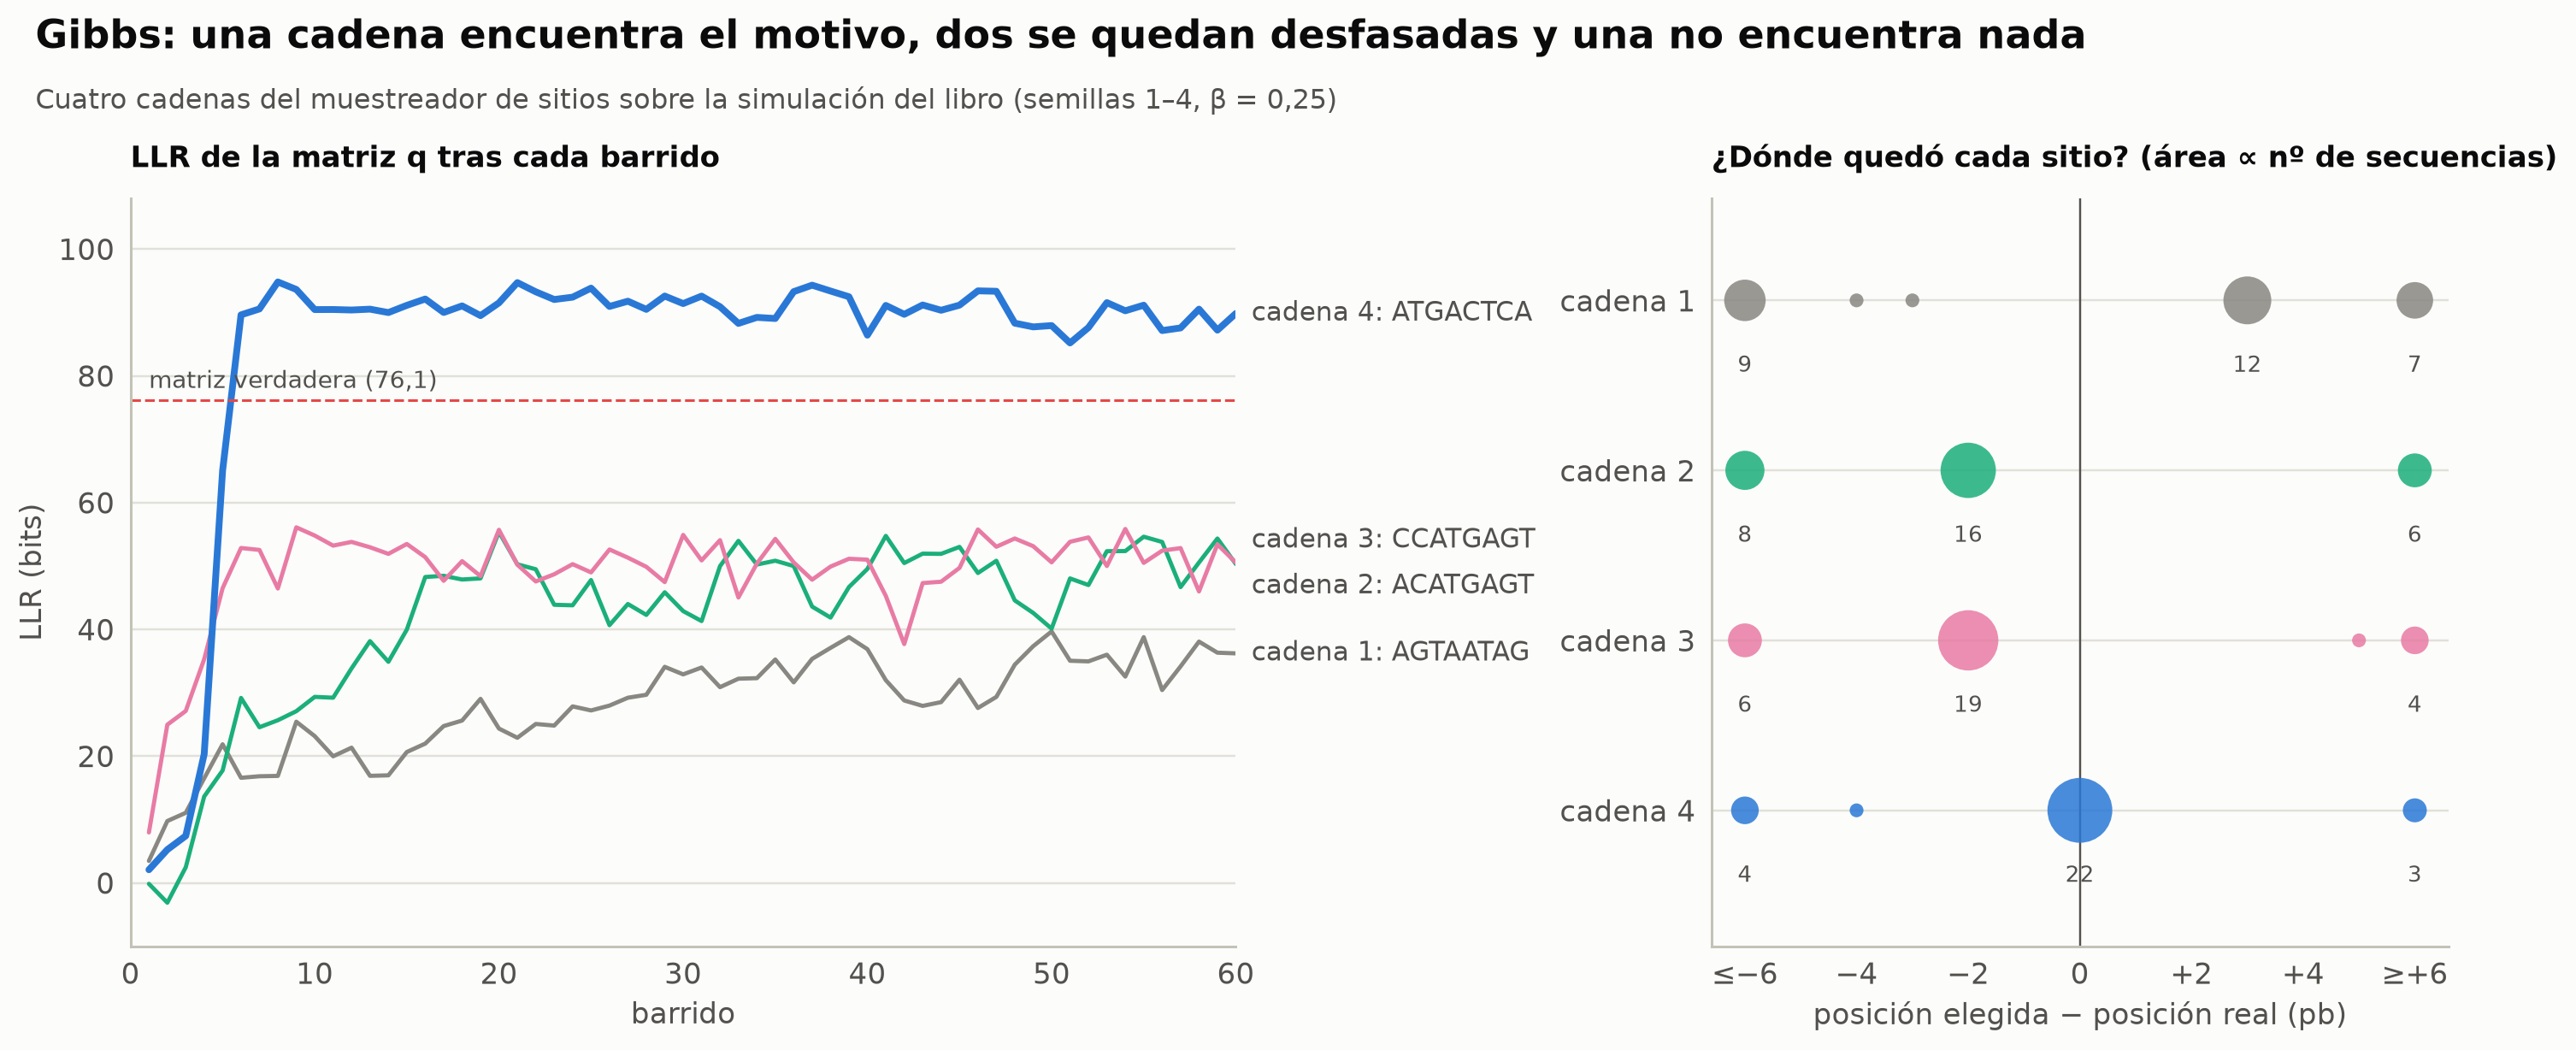

In [11]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), width_ratios=[1.5, 1])
colsg = [ec.MUTED, ec.AQUA, ec.MAGENTA, ec.BLUE]
for c, g_ in enumerate(gb):
    ax.plot(range(1, 61), g_["tray"], color=colsg[c], lw=2.6 if c == 3 else 1.6)
    dy = {1: -3.5, 2: 3.5}.get(c, 0)                 # separar las etiquetas de las cadenas 2 y 3
    ec.label_end(ax, 60, g_["tray"][-1] + dy, f"cadena {c + 1}: {kmer(g_['q'])}")
ax.axhline(llr_true, color=ec.RED, ls="--", lw=1)
ax.text(1, llr_true + 2, "matriz verdadera (76,1)", fontsize=9, color=ec.INK_2)
ax.set_xlim(0, 60); ax.set_ylim(-10, 108)
ax.set_xlabel("barrido"); ax.set_ylabel("LLR (bits)")
ax.set_title("LLR de la matriz q tras cada barrido", fontsize=11, loc="left")
# desfases: posición elegida menos posición real, por cadena
for c, g_ in enumerate(gb):
    d = np.clip(g_["a"] - sitio_real, -6, 6)
    vals, cnts = np.unique(d, return_counts=True)
    ax2.scatter(vals, np.full(len(vals), c), s=cnts * 28, color=colsg[c], alpha=0.85, zorder=3)
    for v, n in zip(vals, cnts):
        if n >= 3:
            ax2.text(v, c + 0.42, str(n), ha="center", fontsize=8.5, color=ec.INK_2)
ax2.axvline(0, color=ec.INK_2, lw=0.8)
ax2.set_yticks(range(4)); ax2.set_yticklabels([f"cadena {c + 1}" for c in range(4)])
ax2.set_xticks(range(-6, 7, 2)); ax2.set_xticklabels(["≤−6", "−4", "−2", "0", "+2", "+4", "≥+6"])
ax2.set_ylim(-0.6, 3.8); ax2.invert_yaxis()
ax2.set_xlabel("posición elegida − posición real (pb)")
ax2.set_title("¿Dónde quedó cada sitio? (área ∝ nº de secuencias)", fontsize=11, loc="left")
ec.fig_title(fig, "Gibbs: una cadena encuentra el motivo, dos se quedan desfasadas y una no encuentra nada",
             "Cuatro cadenas del muestreador de sitios sobre la simulación del libro (semillas 1–4, β = 0,25)")
plt.show()

> 🔎 **Qué observamos.** La trayectoria es **ruidosa** porque cada paso es aleatorio. La cadena 4 (azul) encuentra el
> motivo `ATGACTCA` en **seis barridos** (alcanza el 95 % de su verosimilitud final en el sexto) y coloca 22 de los 30
> sitios en la posición exacta. Las cadenas 2 y 3 terminan en los desfases `ACATGAGT` y `CCATGAGT`: el panel derecho
> muestra que sus sitios están casi todos dos posiciones **antes** del sitio real (−2). Esos desfases contienen seis
> columnas buenas de ocho y son **muy estables**, porque mover un único sitio no mejora nada; hace falta desplazar
> todos a la vez. La cadena 1 no encuentra nada (`AGTAATAG`, 36,2 bits).
>
> Por eso Lawrence et al. (1993) propusieron **movimientos que desplazan todo el alineamiento** (el ejercicio 3 lo
> implementa), y la práctica habitual es **lanzar muchas cadenas y quedarse con la mejor**. EM y Gibbs comparten los
> mismos enemigos: los óptimos locales y, sobre todo, los desfases.

Para cerrar la parte simulada, los seis logos de la figura del libro «Un motivo emerge del ruido»:

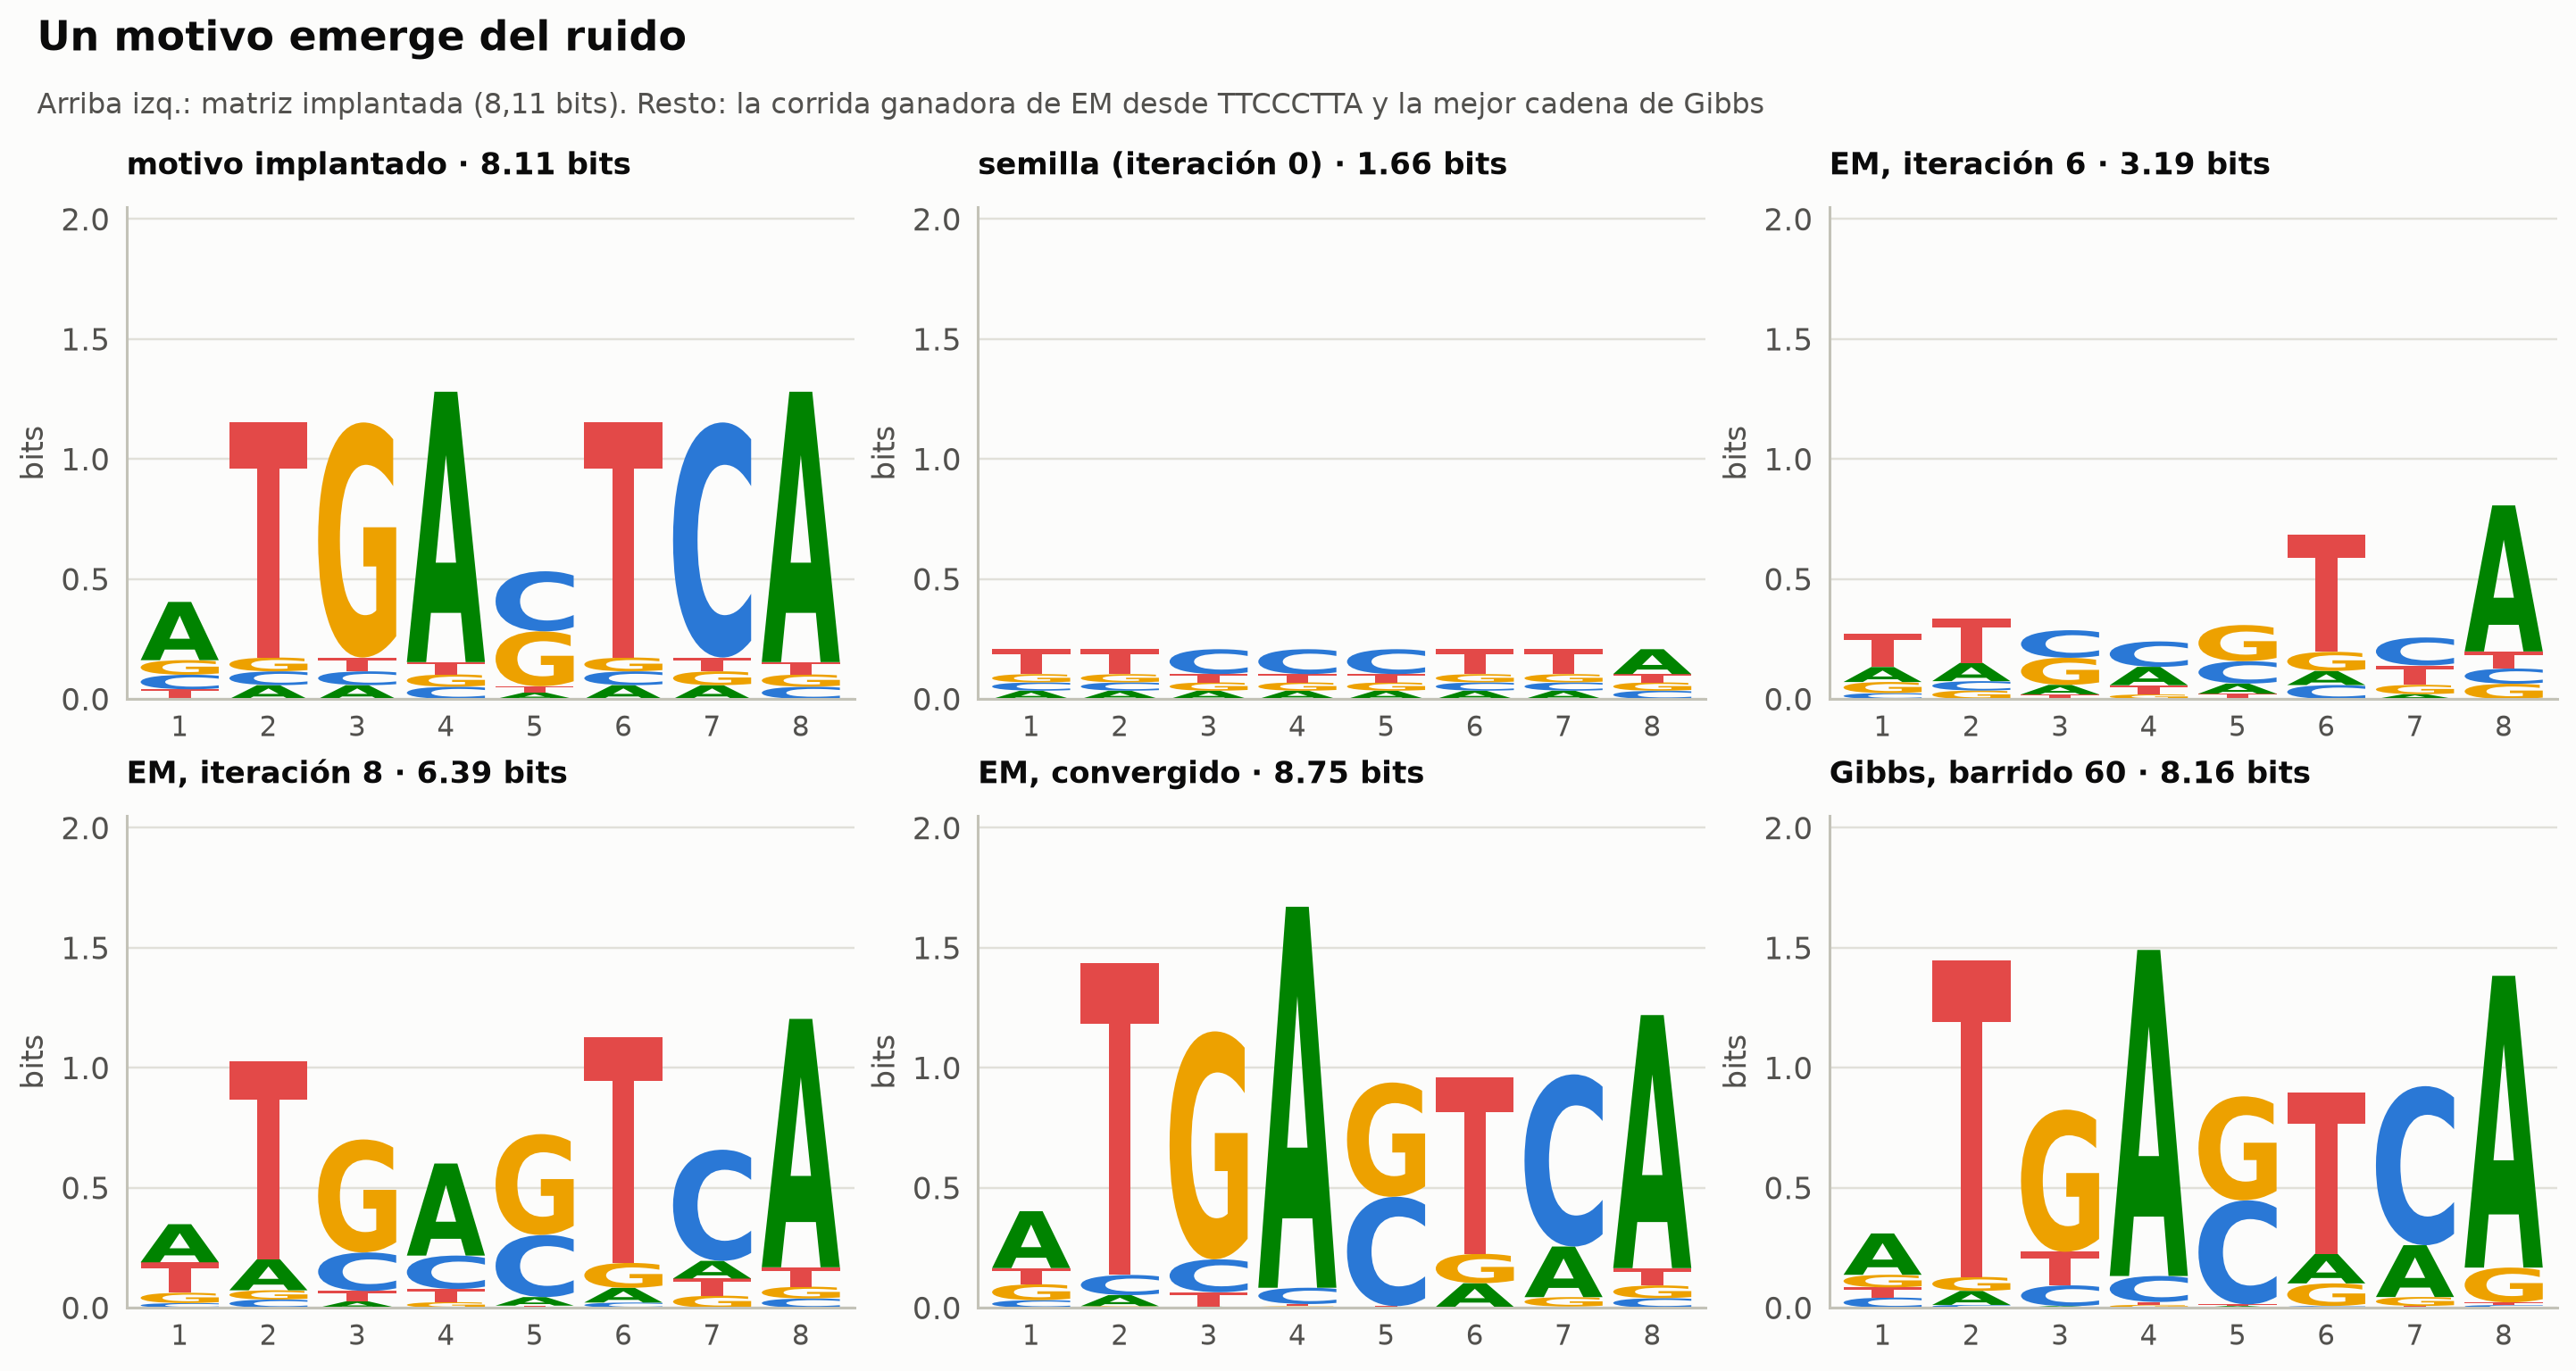

In [12]:
gbest = int(np.argmax([g_["tray"][-1] for g_ in gb]))
panels = [(TRUE, "motivo implantado"), (e["thetas"][0], "semilla (iteración 0)"), (e["thetas"][6], "EM, iteración 6"),
          (e["thetas"][8], "EM, iteración 8"), (th_best, "EM, convergido"), (gb[gbest]["q"], "Gibbs, barrido 60")]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.2))
for ax, (th, name) in zip(axes.flat, panels):
    draw_logo(ax, th, title=f"{name} · {ic(th):.2f} bits", xlabel="")
ec.fig_title(fig, "Un motivo emerge del ruido",
             "Arriba izq.: matriz implantada (8,11 bits). Resto: la corrida ganadora de EM desde TTCCCTTA y la mejor cadena de Gibbs")
plt.show()

## 7. 🧪 Datos reales: 1 000 picos de CTCF en GM12878

Pasamos de la simulación a un experimento real del consorcio **ENCODE** (ENCODE Project Consortium, 2012, 2020):
ChIP-seq de **CTCF** en **GM12878**, una línea de linfocitos B transformados con el virus de Epstein-Barr, de una
donante de la cohorte CEPH, que es una de las líneas de referencia del proyecto. Usamos el archivo de picos
reproducibles del experimento ENCSR000AKB (`ENCFF017XLW`, picos "conservadores" filtrados por IDR sobre GRCh38, dos
réplicas biológicas), que contiene **41 017 picos** en formato *narrowPeak*. La columna 10 da la posición de la
**cumbre** (*summit*), el punto de máxima acumulación de fragmentos, relativa al inicio del pico. La Lección 13.1 usa otro archivo del mismo experimento, `ENCFF559WJC`: la
lista IDR ordenada de 82 105 picos candidatos, de los que 41 978 pasan el umbral IDR ≤ 0,05; aquí partimos del conjunto
conservador ya filtrado, algo más pequeño.

La receta del libro (recuadro de consola al final de la lección) extrae 100 pb alrededor de cada cumbre con
`bedtools getfasta` sobre el genoma completo (3 GB). En Colab no queremos descargar el genoma, así que preparamos
una muestra: **1 000 picos elegidos al azar** (semilla 133) entre los de los cromosomas 1–22 y X, y para cada uno
pedimos a la **API REST de UCSC** los **500 pb** centrados en la cumbre (la cumbre queda en el índice 250). Las
secuencias vienen con el **enmascarado suave** de UCSC: las letras minúsculas son repeticiones (RepeatMasker, TRF), un
detalle que aprovecharemos en la sección 13. También pedimos **fragmentos de 100 pb al azar** del genoma (260 regiones
de 20 kb repartidas en proporción al tamaño de cada cromosoma, 25 fragmentos por región) para usarlos como fondo.
Todo quedó en el repositorio del curso para que la lección no dependa de la red.

Así se ve una consulta a la API (la respuesta está guardada en `data/api_cache/`). Pedimos los 100 pb alrededor de la
cumbre del pico **más intenso** de todo el archivo, en el cromosoma 14:

In [13]:
# Una consulta a la API de UCSC: coordenadas 0-based, semiabiertas [start, end), como en BED
url = "https://api.genome.ucsc.edu/getData/sequence?genome=hg38;chrom=chr14;start=106308991;end=106309091"
resp = cached_json("ucsc_hg38_chr14_106308991_106309091.json", url)
print({k: resp[k] for k in ["genome", "chrom", "start", "end"]})
dna = resp["dna"]
print(f"{len(dna)} pb:", dna)
print("¿Aparece varias veces el mismo trozo? 'CCTGAGC' aparece", dna.upper().count("CCTGAGC"), "veces")

{'genome': 'hg38', 'chrom': 'chr14', 'start': 106308991, 'end': 106309091}
100 pb: ACCCATTGGTGGTCCTGAGCGCCCCCTGTTGGTTCTGAGTACCCCCTCTTGTCCTGAGCGTCCCCGAGTGTTTCTGAGCGCCCCCTGGTGTCCTGAGCGC
¿Aparece varias veces el mismo trozo? 'CCTGAGC' aparece 3 veces


> 🔎 **Qué observamos.** El pico más intenso del experimento no es un sitio "de libro": es un tramo de **repeticiones en
> tándem** (el trozo `CCTGAGC` se repite una y otra vez) en el extremo del brazo largo del cromosoma 14, donde está el
> locus de las cadenas pesadas de inmunoglobulina. Una repetición que contiene varios sitios parecidos acumula
> fragmentos de muchos sitios a la vez, y las lecturas que caen en repeticiones son difíciles de mapear. Primera
> lección práctica: **no analice sólo los picos más intensos**; por eso trabajamos con una muestra al azar.

Ahora cargamos la muestra completa.

In [14]:
def read_fasta(path):
    """Lee un FASTA (gzip) → lista de (encabezado, secuencia)."""
    recs, name, buf = [], None, []
    with gzip.open(path, "rt") as fh:
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                if name is not None:
                    recs.append((name, "".join(buf)))
                name, buf = line[1:], []
            else:
                buf.append(line)
    recs.append((name, "".join(buf)))
    return recs

peaks_raw = read_fasta(data_file("133_ctcf_gm12878_summits500.fa.gz"))
bg_raw = read_fasta(data_file("133_hg38_random_background100.fa.gz"))
peaks = pd.DataFrame([dict(region=h.split()[0], **dict(kv.split("=") for kv in h.split()[1:]), seq=s)
                      for h, s in peaks_raw])
peaks["signal"] = peaks["signal"].astype(float)
peaks["seq500"] = peaks["seq"].str.upper()
peaks = peaks[peaks["seq500"].map(lambda s: set(s) <= set("ACGT"))].reset_index(drop=True)
peaks["seq100"] = peaks["seq500"].str[200:300]                      # ±50 pb alrededor de la cumbre
gc = lambda s: (s.count("G") + s.count("C")) / len(s)
peaks["gc100"] = peaks["seq100"].map(gc)
bg = pd.DataFrame([(h, s.upper(), s) for h, s in bg_raw], columns=["region", "seq100", "masked"])
bg["gc100"] = bg["seq100"].map(gc)
print(f"Picos: {len(peaks)} secuencias de 500 pb (cumbre en el índice 250) · fondo: {len(bg)} fragmentos de 100 pb")
print(f"GC en ±50 pb de la cumbre: mediana {peaks['gc100'].median():.2f}  ·  fondo genómico: mediana {bg['gc100'].median():.2f}")
peaks[["region", "summit", "signal", "q", "gc100"]].head()

Picos: 1000 secuencias de 500 pb (cumbre en el índice 250) · fondo: 6202 fragmentos de 100 pb
GC en ±50 pb de la cumbre: mediana 0.52  ·  fondo genómico: mediana 0.40


,region,summit,signal,q,gc100
0,chr1:9626881-9627381,9627131,349.08889,4.81020,0.77
1,chr11:61129714-61130214,61129964,320.62271,4.81020,0.65
2,chr10:72048461-72048961,72048711,303.06083,4.81020,0.53
3,chr3:50615857-50616357,50616107,295.92429,4.81020,0.62
4,chr19:510562-511062,510812,281.33534,4.81020,0.66


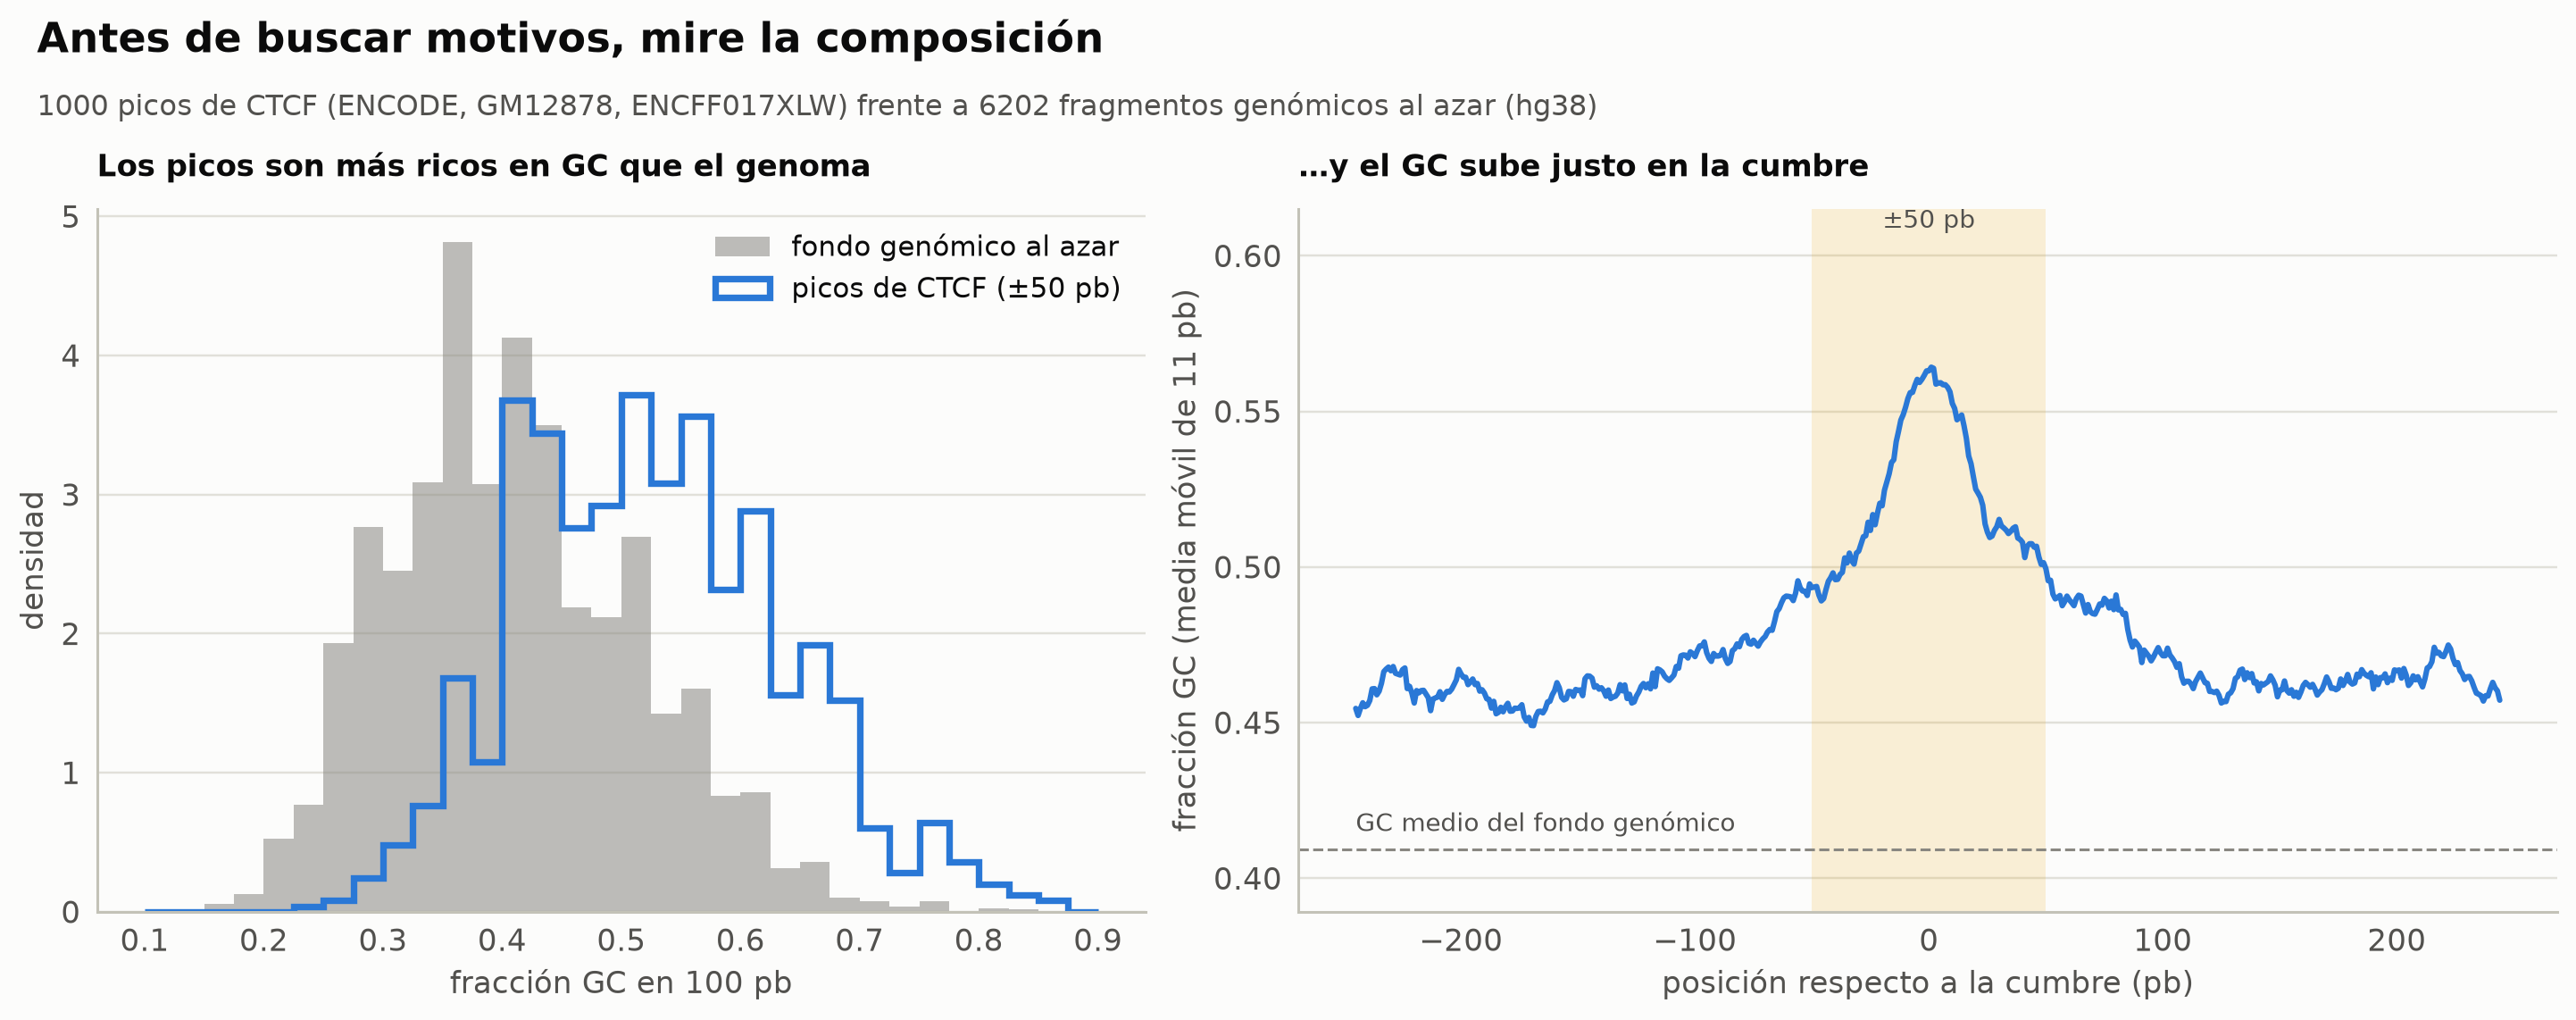

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), width_ratios=[1, 1.2])
bins_gc = np.linspace(0.1, 0.9, 33)
ax1.hist(bg["gc100"], bins=bins_gc, density=True, color=ec.MUTED, alpha=0.55, label="fondo genómico al azar")
ax1.hist(peaks["gc100"], bins=bins_gc, density=True, histtype="step", lw=2.4, color=ec.BLUE, label="picos de CTCF (±50 pb)")
ax1.set_xlabel("fracción GC en 100 pb"); ax1.set_ylabel("densidad")
ax1.legend(loc="upper right", frameon=False)
ax1.set_title("Los picos son más ricos en GC que el genoma", fontsize=11, loc="left")
# composición a lo largo de los 500 pb: GC por posición (promedio de los 1000 picos)
S = np.array([list(s) for s in peaks["seq500"]])
gc_pos = np.isin(S, ["G", "C"]).mean(0)
x = np.arange(500) - 250
ax2.plot(x, pd.Series(gc_pos).rolling(11, center=True).mean(), color=ec.BLUE, lw=2)
ax2.axhline(bg["gc100"].mean(), color=ec.MUTED, ls="--", lw=1)
ax2.set_ylim(bg["gc100"].mean() - 0.02, gc_pos.max() + 0.03)
ax2.text(-245, bg["gc100"].mean() + 0.004, "GC medio del fondo genómico", ha="left", va="bottom", fontsize=9, color=ec.INK_2)
ax2.axvspan(-50, 50, color=ec.YELLOW, alpha=0.15, lw=0)
ax2.text(0, ax2.get_ylim()[1], "±50 pb", ha="center", va="top", fontsize=9, color=ec.INK_2)
ax2.set_xlabel("posición respecto a la cumbre (pb)"); ax2.set_ylabel("fracción GC (media móvil de 11 pb)")
ax2.set_title("…y el GC sube justo en la cumbre", fontsize=11, loc="left")
ec.fig_title(fig, "Antes de buscar motivos, mire la composición",
             f"{len(peaks)} picos de CTCF (ENCODE, GM12878, ENCFF017XLW) frente a {len(bg)} fragmentos genómicos al azar (hg38)")
plt.show()

> 🔎 **Qué observamos.** Los 100 pb centrales de los picos tienen más GC que el genoma promedio (≈ 41 %), y el GC sube
> justo en la cumbre. Parte de ese aumento es el propio motivo de CTCF, que es rico en G y C; parte es que CTCF se une
> con frecuencia en regiones génicas y cerca de promotores, más ricos en GC. Esta diferencia de composición será
> importante en la sección 11: si comparamos contra un fondo que no la tenga en cuenta, **cualquier** motivo rico en
> GC parecerá enriquecido.

## 8. 🧪 EM sobre las cumbres de CTCF (con las dos hebras)

Tomamos los 100 pb centrales de los **primeros 300 picos** ($N=300$, $L=100$) y buscamos un motivo de $W=19$, el ancho
del perfil clásico de CTCF. Necesitamos dos extensiones del modelo del libro, y conviene decirlas en voz alta:

1. **Las dos hebras.** Una proteína reconoce el ADN de doble cadena: el sitio puede leerse en la hebra $+$ o en la
   $-$. El motivo de CTCF **no** es palíndromo, así que un modelo de una sola hebra encontraría el motivo en la mitad
   de los picos y el reverso complementario en la otra mitad. Hacemos lo que hace `meme -revcomp`: cada secuencia
   ofrece $2m$ posiciones de inicio, las $m$ de la hebra $+$ y las $m$ de su reverso complementario, y el modelo OOPS
   elige **una** de ellas. Las ecuaciones no cambian; sólo cambia el conjunto de posiciones $j=1,\dots,2m$.
2. **Un fondo no uniforme.** En el libro, $p_0=1/4$ y por eso $\log_2 r = \sum_k\log_2\theta_{k,\cdot} + 2W$. Con datos
   reales usamos la composición de las propias secuencias (simetrizada: $p_0(A)=p_0(T)$, $p_0(C)=p_0(G)$), y el término
   $+2W$ pasa a ser $-\sum_k \log_2 p_0(x_{i,j+k-1})$. Nuestra función `ll_ratio` ya lo hace así.

**La inicialización de MEME, en pequeño.** Probamos como semillas **todas las subcadenas** de longitud 19 de las
primeras 8 secuencias (en las dos hebras, $8\times 2\times 82=1\,312$ semillas), calculamos la $\mathrm{LLR}$ de cada
semilla sin iterar y lanzamos EM completo sólo desde las 5 más prometedoras. Para evaluar 1 312 semillas a la vez
usamos un truco de álgebra lineal: codificamos cada ventana como un vector *one-hot* de $4W$ ceros y unos, y las
puntuaciones de todas las ventanas con todas las semillas salen de **un solo producto de matrices**.

In [16]:
N_EM, W_CTCF = 300, 19
X_ctcf = np.stack([encode(s) for s in peaks["seq100"][:N_EM]])            # N x L
L_ctcf = X_ctcf.shape[1]
m_ctcf = L_ctcf - W_CTCF + 1

def windows_both(X, W):
    """Ventanas de ancho W en la hebra + y en su reverso complementario: N x 2m x W."""
    m = X.shape[1] - W + 1
    fwd = np.stack([X[:, j:j + W] for j in range(m)], 1)
    rc = 3 - X[:, ::-1]                                                  # A↔T (0↔3), C↔G (1↔2)
    rev = np.stack([rc[:, j:j + W] for j in range(m)], 1)
    return np.concatenate([fwd, rev], 1)

win_ctcf = windows_both(X_ctcf, W_CTCF)
comp = np.bincount(X_ctcf.ravel(), minlength=4) / X_ctcf.size
p0_ctcf = (comp + comp[::-1]) / 2                                        # simetrizada por hebras
print(f"N = {N_EM}, L = {L_ctcf}, W = {W_CTCF}, m = {m_ctcf} por hebra → {2 * m_ctcf} posiciones por secuencia")
print("p0 =", dict(zip(BASES, p0_ctcf.round(3))))

# --- MEME en pequeño: todas las subcadenas de las primeras 8 secuencias como semillas ---
t0 = time.perf_counter()
cand = win_ctcf[:8].reshape(-1, W_CTCF)                                   # 8 x 2m semillas
seed_pwms = np.stack([np.log2(seed_matrix(c) / p0_ctcf) for c in cand])  # S x W x 4
onehot = np.eye(4, dtype=np.float32)[win_ctcf].reshape(N_EM * 2 * m_ctcf, 4 * W_CTCF)
seed_llr = []
for k in range(0, len(cand), 200):                                          # en lotes, para no llenar la memoria
    sc = (onehot @ seed_pwms[k:k + 200].reshape(len(seed_pwms[k:k + 200]), -1).T.astype(np.float32))
    sc = sc.reshape(N_EM, 2 * m_ctcf, -1)
    mx = sc.max(1)
    seed_llr.append((np.log2(np.exp2(sc - mx[:, None, :]).mean(1)) + mx).sum(0))
seed_llr = np.concatenate(seed_llr)                                         # LLR(θ semilla) de cada semilla
top5 = np.argsort(seed_llr)[::-1][:5]
print(f"{len(cand)} semillas evaluadas en {time.perf_counter() - t0:.2f} s; las 5 mejores:")
runs_ctcf = []
for s_ in top5:
    th, tray, Zc, ths = em(seed_matrix(cand[s_]), iters=25, windows=win_ctcf, p0=p0_ctcf)
    runs_ctcf.append(dict(seed="".join(BASES[b] for b in cand[s_]), theta=th, tray=tray, Z=Zc, thetas=ths))
    print(f"  semilla {runs_ctcf[-1]['seed']}  LLR inicial={seed_llr[s_]:7.1f} → final={tray[-1]:7.1f} bits · "
          f"consenso {kmer(th)} · {ic(th):.1f} bits")
best_c = int(np.argmax([r["tray"][-1] for r in runs_ctcf]))
theta_em = runs_ctcf[best_c]["theta"]; Z_ctcf = runs_ctcf[best_c]["Z"]
print(f"EM total: {time.perf_counter() - t0:.1f} s")

N = 300, L = 100, W = 19, m = 82 por hebra → 164 posiciones por secuencia
p0 = {'A': np.float64(0.218), 'C': np.float64(0.282), 'G': np.float64(0.282), 'T': np.float64(0.218)}


1312 semillas evaluadas en 0.36 s; las 5 mejores:


  semilla CAGTAGCCACCAGAGGGCG  LLR inicial=  404.6 → final= 2207.1 bits · consenso CTGTGGCCACCAGGGGGCG · 15.4 bits


  semilla CGCCCTCTGGTGGCTACTG  LLR inicial=  404.6 → final= 2207.1 bits · consenso CGCCCCCTGGTGGCCACAG · 15.4 bits


  semilla CCAGTAGCCACCAGAGGGC  LLR inicial=  380.4 → final= 2015.7 bits · consenso CCTGTGGCCACCAGGGGGC · 14.7 bits


  semilla GCCCTCTGGTGGCTACTGG  LLR inicial=  380.4 → final= 2015.7 bits · consenso GCCCCCTGGTGGCCACAGG · 14.7 bits


  semilla TCTAGCCGCCAGGGGGCGC  LLR inicial=  307.1 → final= 2298.8 bits · consenso TGTGGCCACCAGGGGGCGC · 15.8 bits
EM total: 4.0 s


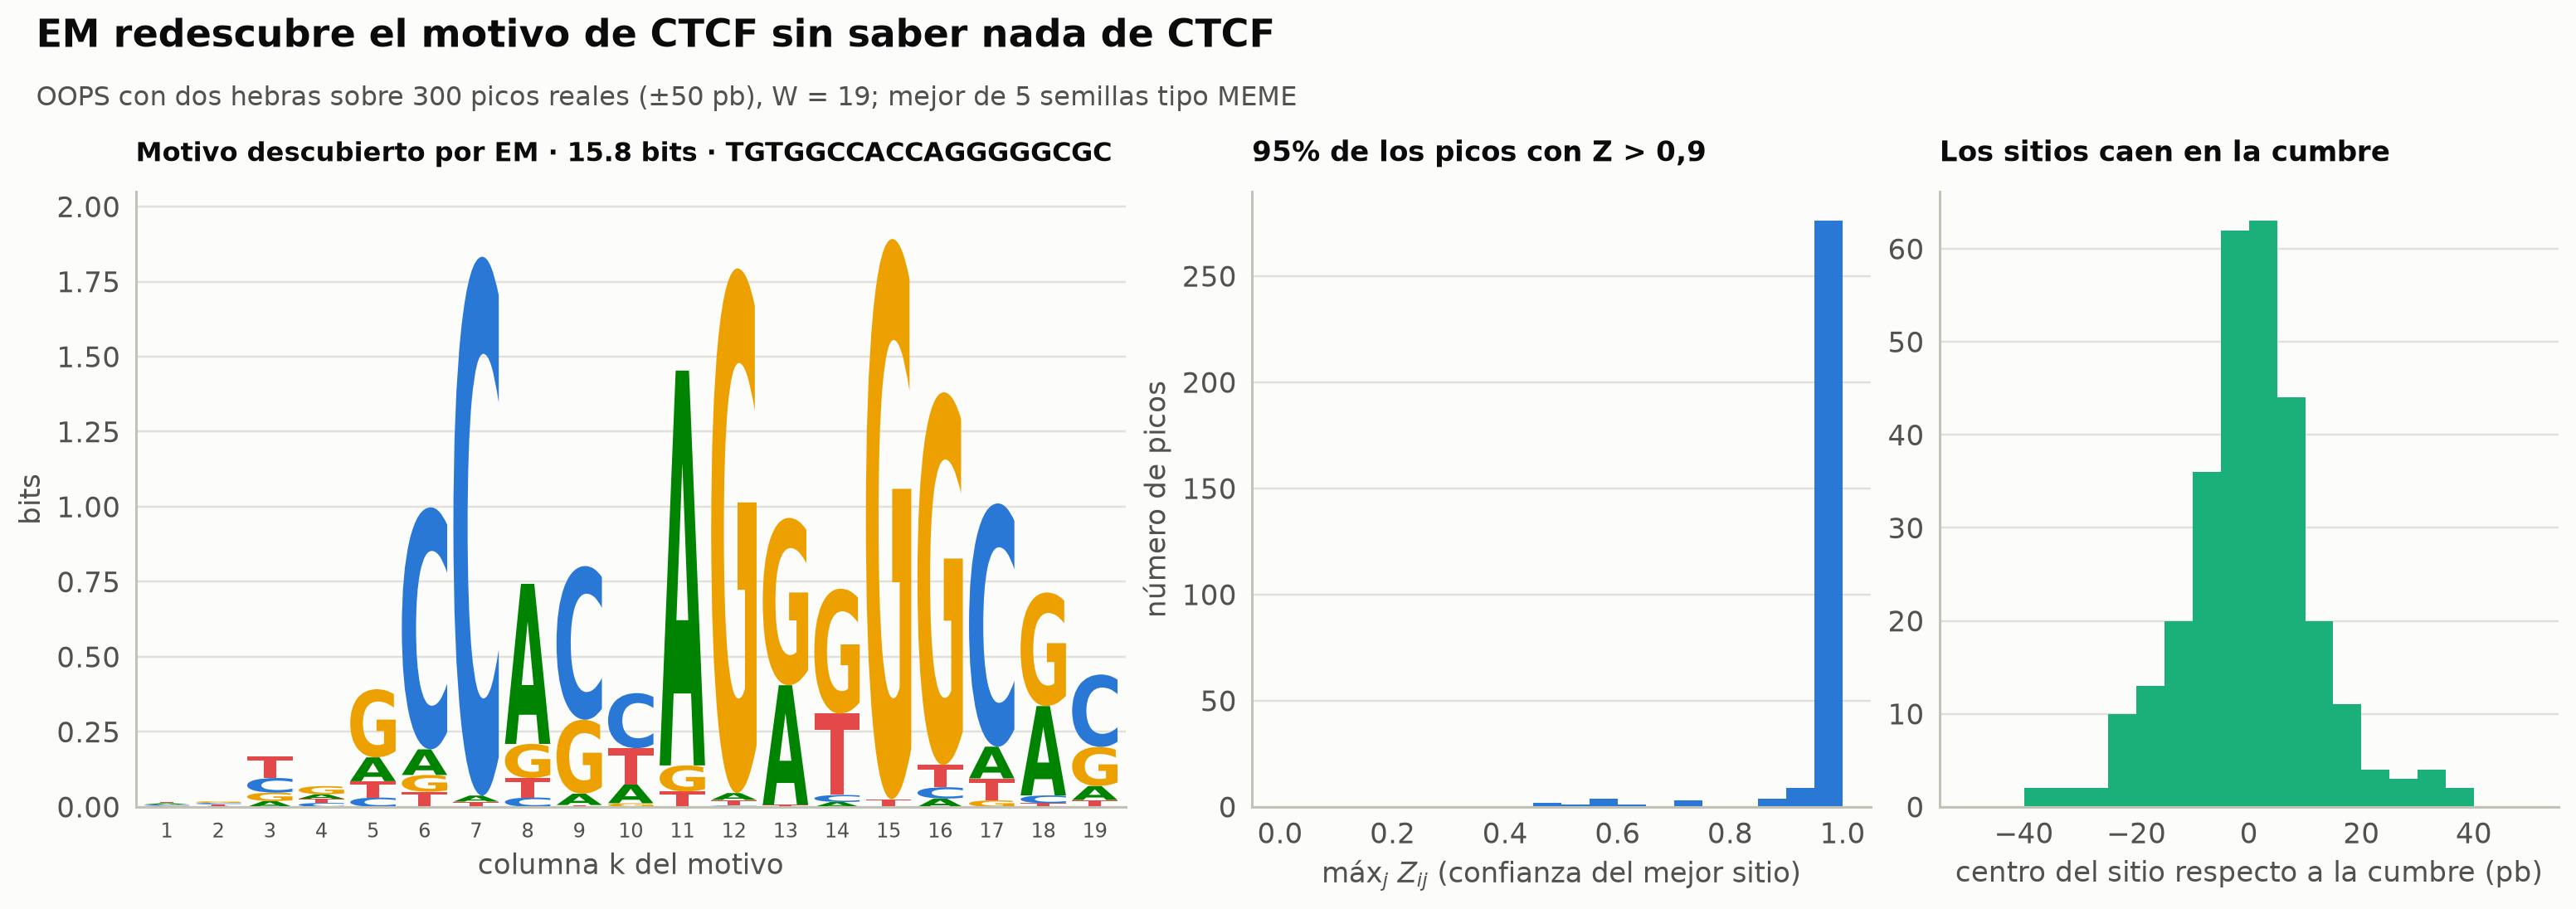

Hebra del mejor sitio: 132 en +, 168 en −


In [17]:
def site_centers(Z_or_pos, W, L, soft=True):
    """Centro del sitio (pb respecto a la cumbre) y hebra, a partir de Z (N x 2m) o de posiciones enteras."""
    m = L - W + 1
    j = Z_or_pos.argmax(1) if soft else np.asarray(Z_or_pos)
    strand = np.where(j < m, "+", "−")
    start = np.where(j < m, j, L - (j - m) - W)                        # inicio en coordenadas de la hebra +
    return start + W / 2 - L / 2, strand

zmax = Z_ctcf.max(1)
cent, strand = site_centers(Z_ctcf, W_CTCF, L_ctcf)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), width_ratios=[1.6, 1, 1])
draw_logo(axes[0], theta_em, title=f"Motivo descubierto por EM · {ic(theta_em):.1f} bits · {kmer(theta_em)}", fs=10.5)
axes[1].hist(zmax, bins=np.linspace(0, 1, 21), color=ec.BLUE)
axes[1].set_xlabel("máx$_j$ $Z_{ij}$ (confianza del mejor sitio)"); axes[1].set_ylabel("número de picos")
axes[1].set_title(f"{(zmax > 0.9).mean():.0%} de los picos con Z > 0,9", fontsize=11, loc="left")
axes[2].hist(cent[zmax > 0.5], bins=np.arange(-50, 51, 5), color=ec.AQUA)
axes[2].set_xlabel("centro del sitio respecto a la cumbre (pb)")
axes[2].set_title("Los sitios caen en la cumbre", fontsize=11, loc="left")
ec.fig_title(fig, "EM redescubre el motivo de CTCF sin saber nada de CTCF",
             f"OOPS con dos hebras sobre {N_EM} picos reales (±50 pb), W = {W_CTCF}; mejor de 5 semillas tipo MEME")
plt.show()
print(f"Hebra del mejor sitio: {(strand == '+').sum()} en +, {(strand == '−').sum()} en −")

> 🔎 **Qué observamos.** Sin ninguna información previa sobre CTCF, EM converge a una matriz de unos 16 bits con un
> núcleo muy informativo, `CCAC…AGGGGGCG` en esta orientación (en la otra hebra se lee `CGCCCCCT…GTGG`): es el famoso
> motivo de CTCF, que sus dedos de zinc centrales leen a lo largo del surco mayor. Fíjese en la tabla de semillas:
> las corridas terminan en versiones **desplazadas** del mismo motivo (con las primeras columnas casi vacías) y con
> LLR distintas; la mejor no es necesariamente la que empezó con la semilla de mayor LLR inicial. Son los mismos
> desfases de la simulación, ahora con datos reales. La mayoría de los picos tienen un sitio con $Z$ cercano a 1, repartidos
> casi por igual entre las dos hebras (si hubiéramos usado una sola hebra, habríamos perdido la mitad), y los centros
> de los sitios se amontonan en torno a la cumbre: el pico está **centrado** en el sitio de unión. Los picos con $Z$
> bajo son los candidatos a no tener sitio (unión indirecta o picos espurios), el caso que el modelo ZOOPS de MEME
> maneja explícitamente (ejercicio 2).

> ✅ **Compruebe su comprensión.** ¿Por qué no hemos pedido a EM que busque con $W=8$ como en la simulación? *(Podría
> hacerlo y encontraría un trozo del núcleo del motivo, pero con información perdida. En la práctica se prueban varios
> anchos y se compara la significancia; MEME lo hace automáticamente con su valor $E$.)*

## 9. 🎬 Gibbs sobre CTCF: los sitios se juntan en la cumbre

Corramos ahora el muestreador de Gibbs, el mismo de la sección 6, sobre los mismos 300 picos reales (dos hebras,
$2m=164$ posiciones por secuencia). Partimos de posiciones **al azar**. La animación muestra el logo de $q$, la
$\mathrm{LLR}$ y, abajo, dónde está el sitio elegido en cada secuencia respecto a la cumbre (azul: hebra $+$; naranja:
hebra $-$). Los primeros barridos se muestran en cámara lenta (un cuadro cada 30 actualizaciones).

![Muestreador de Gibbs sobre 300 picos reales de CTCF: de posiciones al azar a un motivo nítido, con los sitios concentrados en la cumbre del pico en ambas hebras](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-13-epigenomica/13.3_gibbs_ctcf.gif)

*Muestreador de Gibbs sobre 300 picos reales de CTCF: de posiciones al azar a un motivo nítido, con los sitios concentrados en la cumbre del pico en ambas hebras*

In [18]:
t0 = time.perf_counter()
chains_ctcf = []
for sd in [11, 12, 13]:
    q_, tray_, a_, snaps_ = gibbs(sd, sweeps=20, beta=0.25, windows=win_ctcf, p0=p0_ctcf, snapshot_every=30)
    chains_ctcf.append(dict(seed=sd, q=q_, tray=tray_, a=a_, snaps=snaps_))
    print(f"cadena (semilla {sd}): LLR final = {tray_[-1]:7.1f} bits · consenso {kmer(q_)} · {ic(q_):.1f} bits")
print(f"{time.perf_counter() - t0:.1f} s")
gc_best = max(chains_ctcf, key=lambda c: c["tray"][-1])
theta_gibbs = gc_best["q"]
snaps = gc_best["snaps"]
print(f"Cadena animada: semilla {gc_best['seed']} · {len(snaps)} cuadros")

cadena (semilla 11): LLR final =  2428.2 bits · consenso TGGCCACCAGGGGGCGCTG · 16.2 bits


cadena (semilla 12): LLR final =  2309.6 bits · consenso CCACCAGGGGGCGCTGTAG · 15.7 bits


cadena (semilla 13): LLR final =  2010.1 bits · consenso CCTGTGGCCACCAGGGGGC · 14.6 bits
2.5 s
Cadena animada: semilla 11 · 50 cuadros


In [19]:
fig = plt.figure(figsize=(12, 7.4))
fig.set_layout_engine("none")
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.35], width_ratios=[1.5, 1], hspace=0.42, wspace=0.2,
                      left=0.06, right=0.98, top=0.94, bottom=0.08)
ax_logo, ax_ll, ax_pos = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])
sweeps_x = np.arange(1, len(gc_best["tray"]) + 1)

def update(f):
    for a in (ax_logo, ax_ll, ax_pos):
        a.clear()
    t, qf, af = snaps[f]
    draw_logo(ax_logo, qf, title=f"barrido {t:.1f} · {ic(qf):.1f} bits · {kmer(qf)}", fs=10.5)
    ax_ll.plot(sweeps_x, gc_best["tray"], color=ec.BASELINE, lw=1.5)
    done = sweeps_x <= t
    ax_ll.plot(sweeps_x[done], np.array(gc_best["tray"])[done], "o-", color=ec.BLUE, lw=2, ms=4)
    ax_ll.set_xlim(0, sweeps_x[-1]); ax_ll.set_ylim(min(0, min(gc_best["tray"])) - 50, max(gc_best["tray"]) * 1.08)
    ax_ll.set_xlabel("barrido"); ax_ll.set_ylabel("LLR (bits)")
    ax_ll.set_title("LLR tras cada barrido completo", fontsize=11, loc="left")
    c, s = site_centers(af, W_CTCF, L_ctcf, soft=False)
    plus = s == "+"
    ax_pos.axvspan(-10, 10, color=ec.YELLOW, alpha=0.15, lw=0)
    ax_pos.scatter(c[plus], np.arange(N_EM)[plus], s=9, color=ec.BLUE, label="hebra +")
    ax_pos.scatter(c[~plus], np.arange(N_EM)[~plus], s=9, color=ec.ORANGE, label="hebra −")
    ax_pos.set_xlim(-50, 50); ax_pos.set_ylim(N_EM, -1)
    ax_pos.set_xlabel("centro del sitio elegido respecto a la cumbre (pb)"); ax_pos.set_ylabel("pico")
    ax_pos.legend(loc="lower right", bbox_to_anchor=(1, 1.0), ncol=2, frameon=False, fontsize=9, markerscale=2)
    ax_pos.set_title(f"Sitio elegido en cada pico · {np.mean(np.abs(c) <= 10):.0%} a menos de 10 pb de la cumbre",
                     fontsize=11, loc="left")
    ax_pos.grid(axis="y", visible=False)
    return ()

ec.animate(fig, update, frames=len(snaps), interval=300, name="13.3_gibbs_ctcf")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio los puntos cubren uniformemente los ±50 pb y el logo es plano. Tras uno o dos
> barridos aparece una semilla de acuerdo (unas pocas columnas con G y C), y entonces la cadena "encuentra" el motivo:
> los puntos colapsan hacia la franja amarilla de la cumbre, en las dos hebras, y el logo se vuelve casi idéntico al de
> EM (en la tabla de arriba, la mejor cadena alcanza incluso una LLR algo mayor que la mejor corrida de EM: el azar la
> ayudó a encontrar una colocación mejor del motivo). Que los sitios converjan a la **cumbre** sin que el algoritmo sepa dónde está la cumbre es una comprobación
> independiente de que el motivo encontrado es el del factor inmunoprecipitado. Los puntos que quedan dispersos son
> picos donde el sitio es débil o no existe.

## 10. Ponerle nombre al motivo: JASPAR MA0139 y una comparación tipo Tomtom

Un motivo descubierto *de novo* es sólo una matriz. Para ponerle nombre se compara con bases de datos de perfiles de
unión. **JASPAR** es la colección abierta de referencia de perfiles de factores de transcripción curados y no
redundantes. El libro trabaja con su novena versión (JASPAR 2022; Castro-Mondragon et al., 2022); aquí usamos la
edición JASPAR 2024 (Rauluseviciute et al., 2024), cuya colección de vertebrados trae 879 perfiles no redundantes. El
perfil clásico de CTCF es **MA0139.1**, una matriz de 19 columnas construida a partir de sitios de
ChIP-seq en linfocitos T CD4+ humanos (Barski et al., 2007, según los metadatos de JASPAR); la versión
2024 de JASPAR la recorta a sus 15 columnas más informativas (**MA0139.2**). Pedimos MA0139.1 a la **API REST de
JASPAR** (con copia en `data/api_cache/`).

¿Cómo se comparan dos matrices? La herramienta **Tomtom** de la MEME Suite (Bailey et al., 2009) puntúa la similitud
**columna a columna**, probando todos los **desplazamientos** relativos y también la **hebra complementaria** de uno de
los dos motivos, y convierte la mejor puntuación en un valor de significancia. Nosotros implementamos la parte
esencial: para cada alineamiento, sumamos el **coeficiente de correlación de Pearson** entre las columnas enfrentadas
(entre los dos vectores de 4 probabilidades), exigiendo al menos 8 columnas solapadas:

$$
S(\theta,\phi) \;=\; \max_{\text{hebra},\ \text{desplazamiento}}\ \sum_{k\in\text{solape}} \rho\bigl(\theta_{k,\cdot},\ \phi_{k+d,\cdot}\bigr),
$$

| Símbolo | Significado |
|---|---|
| $\theta$, $\phi$ | la matriz descubierta y la de la base de datos (W × 4, filas que suman 1) |
| $d$ | desplazamiento de una matriz respecto a la otra |
| $\rho(\cdot,\cdot)$ | correlación de Pearson entre dos columnas (4 números cada una); vale 1 si las preferencias coinciden |
| $S$ | similitud total: aproximadamente, "cuántas columnas coinciden bien" |

Una columna idéntica aporta 1; una columna al azar, alrededor de 0. Así, $S\approx 15$ significa que unas quince
columnas se parecen mucho.

In [20]:
url = "https://jaspar.elixir.no/api/v1/matrix/MA0139.1/?format=json"
ma = cached_json("jaspar_MA0139.1.json", url)
cnt_ma = np.array([ma["pfm"][b] for b in BASES], float).T                 # W x 4 conteos
theta_ma = (cnt_ma + 0.25) / (cnt_ma.sum(1, keepdims=True) + 1)
print(f"{ma['matrix_id']} · {ma['name']} · {ma['class'][0]} · tipo de dato: {ma['type']} · "
      f"{int(cnt_ma[0].sum())} sitios · PubMed {ma['medline'][0]}")
print(f"Consenso MA0139.1: {kmer(theta_ma)} · {ic(theta_ma):.1f} bits")

def rc_theta(th):
    """Matriz del reverso complementario: invertir columnas y cambiar A↔T, C↔G."""
    return np.asarray(th)[::-1, ::-1]

def col_corr(a, b):
    """Correlación de Pearson fila a fila entre dos matrices k x 4 (0 si una columna es plana)."""
    a = a - a.mean(1, keepdims=True); b = b - b.mean(1, keepdims=True)
    den = np.sqrt((a ** 2).sum(1) * (b ** 2).sum(1))
    return np.where(den > 0, (a * b).sum(1) / np.where(den > 0, den, 1), 0.0)

def compare(th, ph, min_overlap=8):
    """Similitud tipo Tomtom: mejor suma de correlaciones por columna sobre desplazamientos y hebras."""
    best = (-np.inf, 0, "+")
    for strand, P in (("+", ph), ("−", rc_theta(ph))):
        for d in range(-(len(P) - min_overlap), len(th) - min_overlap + 1):
            k = np.arange(max(0, d), min(len(th), d + len(P)))       # columnas de θ solapadas con P
            s = col_corr(th[k], P[k - d]).sum()
            if s > best[0]:
                best = (s, d, strand)
    return best

S_em, d_em, str_em = compare(theta_em, theta_ma)
S_gb, _, _ = compare(theta_gibbs, theta_ma)
print(f"EM vs MA0139.1:    S = {S_em:.2f} (hebra {str_em}, desplazamiento {d_em})")
print(f"Gibbs vs MA0139.1: S = {S_gb:.2f}")
print(f"EM vs Gibbs:       S = {compare(theta_em, theta_gibbs)[0]:.2f}")

MA0139.1 · CTCF · C2H2 zinc finger factors · tipo de dato: ChIP-seq · 913 sitios · PubMed 17512414
Consenso MA0139.1: TGGCCACCAGGGGGCGCTA · 17.2 bits
EM vs MA0139.1:    S = 16.85 (hebra +, desplazamiento 2)
Gibbs vs MA0139.1: S = 18.74
EM vs Gibbs:       S = 17.00


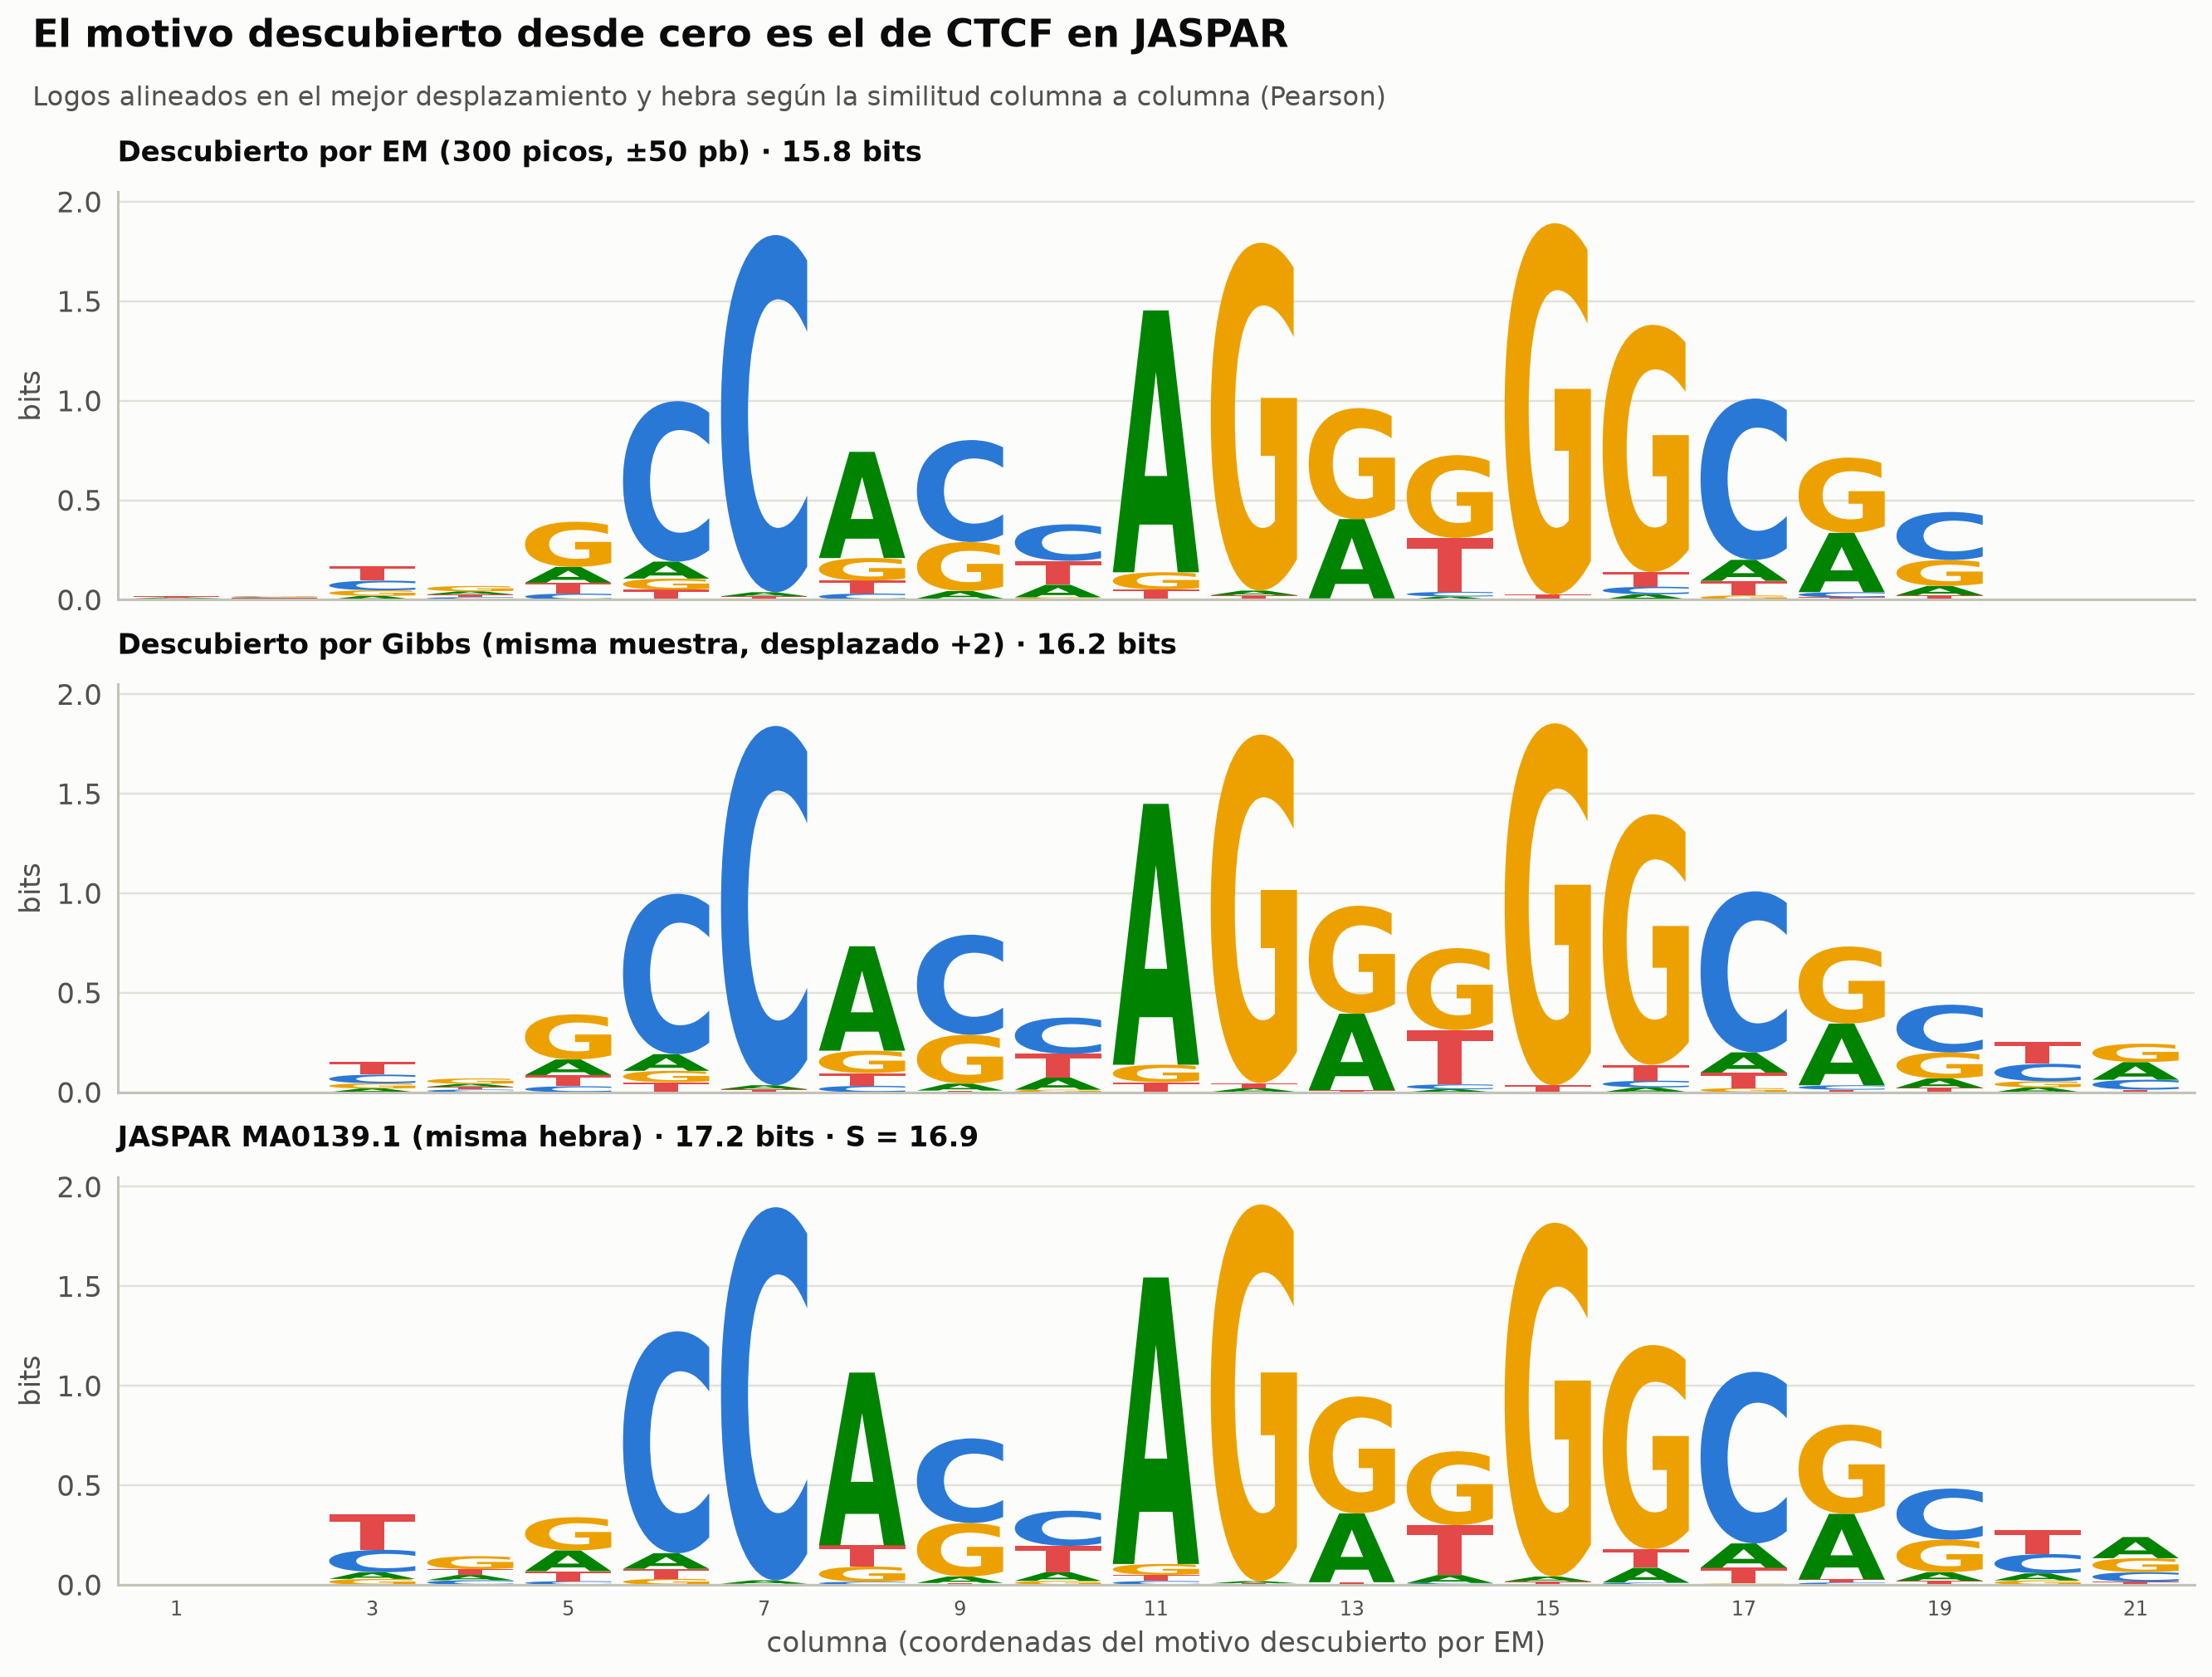

In [21]:
# El perfil de JASPAR en la orientación y el desplazamiento del mejor alineamiento
P = theta_ma if str_em == "+" else rc_theta(theta_ma)
fig, axes = plt.subplots(3, 1, figsize=(12, 8.4), sharex=True)
span = (min(0, d_em, compare(theta_em, theta_gibbs)[1]), max(len(theta_em), d_em + len(P), compare(theta_em, theta_gibbs)[1] + len(theta_gibbs)))
def logo_at(ax, th, start, title):
    draw_logo(ax, th, title=title, xlabel="")
    for patch in ax.patches:                                   # desplazar las letras 'start' columnas
        patch.set_transform(Affine2D().translate(start, 0) + ax.transData)
    ax.set_xlim(span[0] + 0.4, span[1] + 0.6)
    ax.set_xticks(range(span[0] + 1, span[1] + 1, 2))
logo_at(axes[0], theta_em, 0, f"Descubierto por EM (300 picos, ±50 pb) · {ic(theta_em):.1f} bits")
S_eg, d_eg, str_eg = compare(theta_em, theta_gibbs)                  # alinear también Gibbs con EM
G_al = theta_gibbs if str_eg == "+" else rc_theta(theta_gibbs)
logo_at(axes[1], G_al, d_eg, f"Descubierto por Gibbs (misma muestra, desplazado {d_eg:+d}) · {ic(theta_gibbs):.1f} bits")
logo_at(axes[2], P, d_em, f"JASPAR MA0139.1 ({'misma hebra' if str_em == '+' else 'reverso complementario'}) · "
        f"{ic(theta_ma):.1f} bits · S = {S_em:.1f}")
axes[2].set_xlabel("columna (coordenadas del motivo descubierto por EM)")
ec.fig_title(fig, "El motivo descubierto desde cero es el de CTCF en JASPAR",
             "Logos alineados en el mejor desplazamiento y hebra según la similitud columna a columna (Pearson)")
plt.show()

Ahora la búsqueda "a ciegas", como haría Tomtom: comparamos el motivo de EM con **las 879 matrices** de la colección
no redundante de vertebrados de JASPAR 2024 (archivo descargado de jaspar.elixir.no y guardado comprimido en `data/`).
Si nuestro motivo es de verdad el de CTCF, los primeros puestos deben ser perfiles de CTCF (o de su parálogo CTCFL,
también llamado BORIS, que reconoce casi la misma secuencia).

In [22]:
def read_jaspar(path):
    """Lee el formato 'jaspar' (encabezado >ID nombre y cuatro filas A/C/G/T) → lista de (id, nombre, conteos W x 4)."""
    mats, cur = [], None
    with gzip.open(path, "rt") as fh:
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                mid, name = line[1:].split(None, 1)
                cur = [mid, name, []]; mats.append(cur)
            elif line:
                cur[2].append([float(v) for v in line.split("[")[1].split("]")[0].split()])
    return [(m, n, np.array(c).T) for m, n, c in mats]

jaspar = read_jaspar(data_file("133_JASPAR2024_CORE_vertebrates_nr_pfms.txt.gz"))
jaspar_theta = {m: (c + 0.25) / (c.sum(1, keepdims=True) + 1) for m, n, c in jaspar}
jaspar_name = {m: n for m, n, c in jaspar}
t0 = time.perf_counter()
sims = pd.DataFrame([(m, jaspar_name[m], len(th), *compare(theta_em, th)) for m, th in jaspar_theta.items()],
                    columns=["id", "factor", "W", "S", "desplazamiento", "hebra"])
sims = sims.sort_values("S", ascending=False).reset_index(drop=True)
sims["z"] = (sims["S"] - sims["S"].mean()) / sims["S"].std()
print(f"{len(jaspar)} matrices comparadas en {time.perf_counter() - t0:.1f} s")
sims.head(10).round(2)

879 matrices comparadas en 0.7 s


,id,factor,W,S,desplazamiento,hebra,z
0,MA1930.2,CTCF,33,17.72,-14,+,9.50
1,MA1929.2,CTCF,31,16.95,-13,+,8.98
2,MA0139.2,CTCF,15,14.88,4,+,7.60
3,MA1987.2,ZNF701,17,8.95,3,+,3.65
4,MA0116.1,Znf423,15,7.88,3,+,2.94
5,MA1969.2,THRA,18,7.70,1,−,2.81
6,MA0163.1,PLAG1,14,7.55,2,+,2.72
7,MA0155.1,INSM1,12,7.44,6,+,2.64
8,MA0860.1,Rarg,17,7.42,1,+,2.63
9,MA1102.3,CTCFL,8,7.36,9,+,2.59


> 🔎 **Qué observamos.** Los tres primeros puestos de las 879 matrices son perfiles de **CTCF** (MA1930.2 y MA1929.2,
> que describen el núcleo con módulos adicionales a ambos lados, y MA0139.2), muy por encima del resto (columna `z`:
> cuántas desviaciones estándar se separan de la similitud típica: 7,6 a 9,5 frente a menos de 4 para el cuarto).
> CTCFL, el parálogo de CTCF, aparece más abajo sólo porque su perfil en JASPAR tiene 8 columnas: con esta
> puntuación, que suma columnas, un perfil corto nunca puede sumar mucho. Tomtom corrige ese efecto convirtiendo la
> puntuación en un valor $p$ que depende del ancho. El motivo que EM encontró "a ciegas" en 300 picos
> reales es el mismo que JASPAR construyó con otros datos. Observe también la hebra: muchos perfiles están guardados
> en la orientación opuesta a la nuestra, y sin probar el reverso complementario la comparación habría fallado.

## 11. Enriquecimiento diferencial al estilo de HOMER

Una pregunta distinta, y a menudo más útil, es: de los **cientos de motivos conocidos**, ¿cuál aparece **más** en los
picos que en secuencias de fondo comparables? Es lo que se pregunta el grupo de oncología de la sección 1 cuando no
sabe qué factor abre la cromatina en el tumor resistente. **HOMER** (Heinz et al., 2010) popularizó este enfoque con un
fondo de secuencias genómicas aleatorias **emparejadas por contenido de GC** con los picos, lo que evita que cualquier
motivo rico en GC parezca enriquecido sólo porque los promotores lo son. Con ese enfoque, Heinz et al. mostraron que el
factor PU.1 colabora con pequeños conjuntos de factores determinantes de linaje para establecer los potenciadores
propios de macrófagos y linfocitos B.

La significancia se calcula con la **distribución hipergeométrica**. Imagine una urna con las $n_t+n_b$ secuencias,
de las cuales $k_t+k_b$ tienen el motivo; saque al azar $n_t$ secuencias (las que "serán" picos). ¿Qué probabilidad
hay de sacar al menos $k_t$ con motivo?

$$
p \;=\; \Pr(K\ge k_t) \;=\; \sum_{k\ge k_t}\frac{\binom{k_t+k_b}{k}\binom{n_t+n_b-k_t-k_b}{n_t-k}}{\binom{n_t+n_b}{n_t}}
$$

| Símbolo | Significado |
|---|---|
| $n_t,\ k_t$ | número de secuencias objetivo (picos) y cuántas contienen el motivo |
| $n_b,\ k_b$ | número de secuencias de fondo y cuántas lo contienen |
| $K$ | número de secuencias con motivo que caerían en el conjunto objetivo si la asignación fuera al azar |

Es la misma prueba exacta de Fisher (unilateral) sobre la tabla 2 × 2 de "objetivo/fondo × con/sin motivo".

### Ejemplo del libro: «Un motivo enriquecido»

De **2 000** picos, **640** (32 %) contienen el motivo; de **20 000** secuencias de fondo emparejadas por GC, lo
contienen **1 200** (6 %). El enriquecimiento es $0{,}32/0{,}06=5{,}33$ veces, y la ecuación da
$p=6{,}8\times10^{-234}$ ($\ln p=-536{,}9$, la escala que HOMER reporta). La aproximación binomial, que trata el
fondo como una proporción conocida sin error, da un valor aún menor ($2\times10^{-276}$).

> 🤔 **Antes de ejecutar, prediga.** ¿Por qué la binomial da un $p$ **más pequeño** que la hipergeométrica? *(Porque
> ignora que el 6 % del fondo es también una estimación con error; la hipergeométrica "sabe" que las 20 000 secuencias
> de fondo son una muestra finita.)*

In [23]:
nt, kt, nb_, kb = 2000, 640, 20000, 1200
p_hg = stats.hypergeom.sf(kt - 1, nt + nb_, kt + kb, nt)
ln_p = stats.hypergeom.logsf(kt - 1, nt + nb_, kt + kb, nt)
p_bn = stats.binom.sf(kt - 1, nt, kb / nb_)
p_fisher = stats.fisher_exact([[kt, nt - kt], [kb, nb_ - kb]], alternative="greater")[1]
print(f"objetivo {kt}/{nt} = {kt / nt:.3f} · fondo {kb}/{nb_} = {kb / nb_:.3f} · enriquecimiento = {(kt / nt) / (kb / nb_):.2f}")
print(f"hipergeométrica: p = {p_hg:.2e}  (ln p = {ln_p:.1f})")
print(f"Fisher unilateral (la misma prueba): p = {p_fisher:.2e}")
print(f"aproximación binomial: p = {p_bn:.2e}")

objetivo 640/2000 = 0.320 · fondo 1200/20000 = 0.060 · enriquecimiento = 5.33
hipergeométrica: p = 6.82e-234  (ln p = -536.9)
Fisher unilateral (la misma prueba): p = 6.82e-234
aproximación binomial: p = 2.03e-276


Valores tan extremos son habituales y **no deben leerse literalmente**: con miles de secuencias, cualquier sesgo
sistemático de composición da valores $p$ astronómicos. Lo que importa es el **orden** de los motivos y el **tamaño del
enriquecimiento**.

### Con los datos reales: 879 motivos de JASPAR contra los picos de CTCF

El procedimiento:

1. **Objetivo**: los 100 pb centrales de los 1 000 picos ($n_t=1\,000$).
2. **Fondo**: los 6 202 fragmentos genómicos al azar ($n_b$), en dos versiones: **sin emparejar** y **emparejados
   por GC**. Para emparejar hacemos lo que HOMER: repartimos picos y fondo en intervalos de GC de 5 puntos y damos a
   cada secuencia de fondo un **peso** $w=\dfrac{n_t^{(g)}/n_t}{n_b^{(g)}/n_b}$ (fracción de picos en su intervalo
   $g$ dividida entre la fracción de fondo en ese intervalo). Las secuencias de fondo ricas en GC, escasas en el
   genoma, pesan más; las pobres en GC, menos. El recuento $k_b$ pasa a ser la suma ponderada de las secuencias de
   fondo con motivo.
3. **¿Contiene el motivo?** Convertimos cada matriz de JASPAR en una PWM (fondo uniforme) y decimos que una secuencia
   contiene el motivo si alguna ventana, en cualquiera de las dos hebras, supera el umbral de puntuación que un fondo
   uniforme sólo supera con probabilidad $10^{-4}$ por posición (el umbral por defecto de FIMO). Ese umbral se
   calcula **exactamente** convolucionando las distribuciones de las columnas (el ejercicio 3 de la lección 4.2), y
   tiene la ventaja de ser comparable entre motivos de anchos muy distintos.
4. Prueba hipergeométrica y enriquecimiento para cada motivo.

In [24]:
# Fondo emparejado por GC al estilo de HOMER: cada secuencia de fondo recibe un peso w según su intervalo de GC,
# de modo que la distribución de GC ponderada del fondo sea la de los picos
edges = np.arange(0.30, 0.71, 0.05)                    # intervalos: <0,30 · [0,30; 0,35) · … · ≥0,70
tb, bb = np.digitize(peaks["gc100"], edges), np.digitize(bg["gc100"], edges)
nt_bin = np.bincount(tb, minlength=len(edges) + 1)
nb_bin = np.bincount(bb, minlength=len(edges) + 1)
w_bin = (nt_bin / nt_bin.sum()) / (nb_bin / nb_bin.sum())
w_bg = w_bin[bb]                                        # peso de cada secuencia de fondo (suman n_b)
tabla = pd.DataFrame({"intervalo GC": ["<0,30"] + [f"{a:.2f}–{a + 0.05:.2f}" for a in edges[:-1]] + ["≥0,70"],
                      "picos": nt_bin, "fondo": nb_bin, "peso w": w_bin.round(2)})
print(tabla.to_string(index=False))
print(f"GC medio: picos {peaks['gc100'].mean():.3f} · fondo sin ponderar {bg['gc100'].mean():.3f} · "
      f"fondo ponderado {np.average(bg['gc100'], weights=w_bg):.3f}")

intervalo GC  picos  fondo  peso w
       <0,30      9    796    0.07
   0.30–0.35     31   1025    0.19
   0.35–0.40     69   1223    0.35
   0.40–0.45    150   1027    0.91
   0.45–0.50    170    822    1.28
   0.50–0.55    170    639    1.65
   0.55–0.60    147    378    2.41
   0.60–0.65    111    182    3.78
   0.65–0.70     76     66    7.14
       ≥0,70     67     44    9.44
GC medio: picos 0.524 · fondo sin ponderar 0.409 · fondo ponderado 0.521


In [25]:
def pwm_from_counts(c, p0=np.full(4, 0.25)):
    """PWM log2 (W x 4) a partir de conteos, con un seudoconteo total de 1 repartido según el fondo."""
    th = (c + p0) / (c.sum(1, keepdims=True) + 1)
    return np.log2(th / p0)

def threshold_p(pwm, p=1e-4, step=0.05):
    """Umbral de puntuación con P(S ≥ umbral) ≤ p bajo un fondo uniforme (distribución exacta por convolución)."""
    ints = np.round(pwm / step).astype(int)
    dist, off = np.array([1.0]), 0
    for k in range(len(ints)):
        lo = ints[k].min()
        col = np.zeros(ints[k].max() - lo + 1)
        np.add.at(col, ints[k] - lo, 0.25)
        dist, off = np.convolve(dist, col), off + lo
    tail = np.cumsum(dist[::-1])[::-1]
    ok = np.where(tail <= p)[0]
    return (ok[0] + off) * step if len(ok) else np.inf

def scan_best(seqs_int, pwms, chunk=1500):
    """Mejor puntuación (ambas hebras) de cada secuencia con cada PWM: matriz n x K. Agrupa las PWM por ancho."""
    n, L = seqs_int.shape
    out = np.full((n, len(pwms)), -np.inf, dtype=np.float32)
    by_w = {}
    for k, P in enumerate(pwms):
        by_w.setdefault(len(P), []).append(k)
    eye = np.eye(4, dtype=np.float32)
    for w, ks in by_w.items():
        if w > L:
            continue
        Wmat = np.concatenate([np.stack([pwms[k].ravel() for k in ks], 1),
                               np.stack([rc_theta(pwms[k]).ravel() for k in ks], 1)], 1).astype(np.float32)
        P_ = L - w + 1
        for s0 in range(0, n, chunk):
            Xc = seqs_int[s0:s0 + chunk]
            win_ = np.stack([Xc[:, j:j + w] for j in range(P_)], 1)            # c x P x w
            sc = (eye[win_].reshape(-1, 4 * w) @ Wmat).reshape(len(Xc), P_, 2, len(ks))
            out[s0:s0 + chunk, ks] = sc.max(axis=(1, 2))
    return out

ids = [m for m, n, c in jaspar]
pwms = [pwm_from_counts(c) for m, n, c in jaspar]
thr = np.array([threshold_p(P) for P in pwms])
X_t = np.stack([encode(s) for s in peaks["seq100"]])
X_b = np.stack([encode(s) for s in bg["seq100"]])
t0 = time.perf_counter()
best_t, best_b = scan_best(X_t, pwms), scan_best(X_b, pwms)
print(f"{len(pwms)} motivos × {len(X_t) + len(X_b)} secuencias escaneados en {time.perf_counter() - t0:.1f} s")

def enrichment(hit_t, hit_b, w=None):
    """Hipergeométrica por motivo. Con pesos w, k_b es el recuento ponderado (redondeado), como en HOMER."""
    n_t, n_b = len(hit_t), len(hit_b)
    k_t = hit_t.sum(0)
    k_b = hit_b.sum(0) if w is None else np.round(w @ hit_b).astype(int)
    lnp = stats.hypergeom.logsf(k_t - 1, n_t + n_b, k_t + k_b, n_t)
    fold = (k_t / n_t + 1e-3) / (k_b / n_b + 1e-3)
    return pd.DataFrame(dict(id=ids, factor=[jaspar_name[m] for m in ids], k_t=k_t, k_b=k_b,
                             pct_t=100 * k_t / n_t, pct_b=100 * k_b / n_b, fold=fold, ln_p=lnp))

hit_t = best_t >= thr
enr_all = enrichment(hit_t, best_b >= thr)
enr_gc = enrichment(hit_t, best_b >= thr, w=w_bg)
enr_gc = enr_gc.sort_values("ln_p").reset_index(drop=True)
enr_gc.head(12).round(2)

879 motivos × 7202 secuencias escaneados en 4.4 s


,id,factor,k_t,k_b,pct_t,pct_b,fold,ln_p
0,MA0139.2,CTCF,734,233,73.4,3.76,19.06,-1271.08
1,MA1930.2,CTCF,445,197,44.5,3.18,13.61,-607.16
2,MA1929.2,CTCF,445,236,44.5,3.81,11.42,-567.06
3,MA1102.3,CTCFL,215,260,21.5,4.19,5.03,-153.75
4,MA1584.2,ZIC5,98,143,9.8,2.31,4.12,-57.26
5,MA0751.2,ZIC4,107,172,10.7,2.77,3.76,-56.79
6,MA0696.1,ZIC1,110,187,11.0,3.02,3.56,-54.99
7,MA0697.3,Zic3,103,202,10.3,3.26,3.10,-43.42
8,MA1628.2,Zic1::Zic2,114,254,11.4,4.10,2.74,-40.40
9,MA0116.1,Znf423,69,116,6.9,1.87,3.55,-34.99


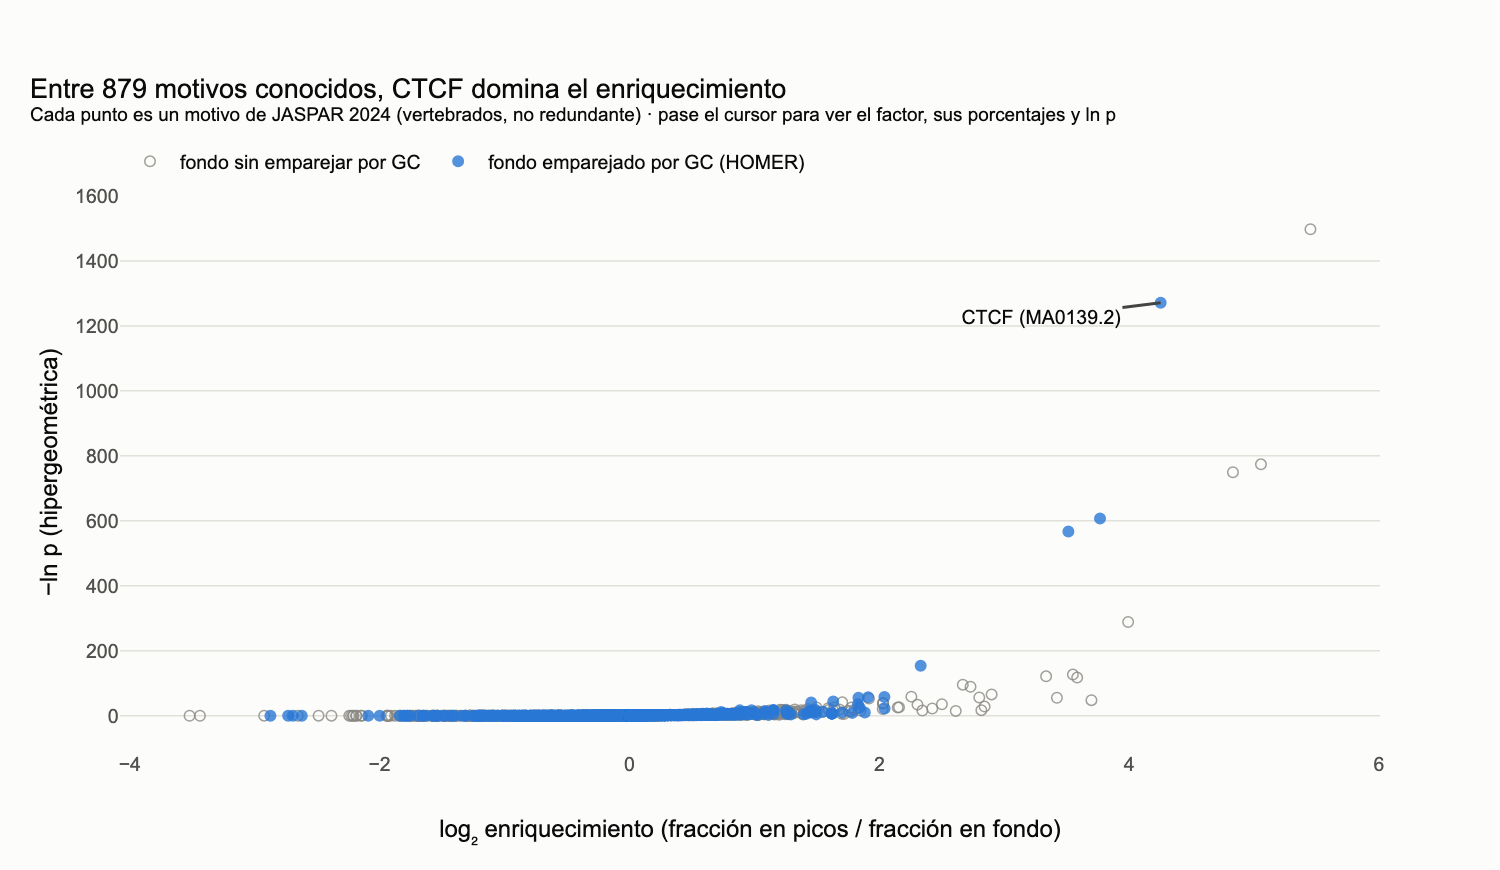

In [26]:
cons = {m: kmer(jaspar_theta[m]) for m in ids}
gc_motif = {m: float(jaspar_theta[m][:, 1:3].sum(1).mean()) for m in ids}   # GC esperado del motivo
fig = go.Figure()
for df, name, color, sym in [(enr_all, "fondo sin emparejar por GC", ec.MUTED, "circle-open"),
                             (enr_gc, "fondo emparejado por GC (HOMER)", ec.BLUE, "circle")]:
    hover = [f"<b>{r.factor}</b> ({r.id})<br>consenso <tt>{cons[r.id]}</tt> · GC del motivo {gc_motif[r.id]:.0%}"
             f"<br>picos con motivo: {r.pct_t:.1f} % · fondo: {r.pct_b:.1f} %<br>enriquecimiento ×{r.fold:.2f}"
             f"<br>ln p = {r.ln_p:.1f}" for r in df.itertuples()]
    fig.add_trace(go.Scatter(x=np.log2(df["fold"]), y=-df["ln_p"], mode="markers", name=name, text=hover,
                             hovertemplate="%{text}<extra></extra>",
                             marker=dict(color=color, symbol=sym, size=7, opacity=0.8, line=dict(width=1, color=color))))
top_ctcf = enr_gc.iloc[0]
fig.add_annotation(x=np.log2(top_ctcf["fold"]), y=-top_ctcf["ln_p"], text=f"{top_ctcf['factor']} ({top_ctcf['id']})",
                   showarrow=True, arrowhead=0, ax=-80, ay=10)
fig.update_layout(
    title="Entre 879 motivos conocidos, CTCF domina el enriquecimiento<br><sup>Cada punto es un motivo de JASPAR 2024 "
          "(vertebrados, no redundante) · pase el cursor para ver el factor, sus porcentajes y ln p</sup>",
    xaxis_title="log₂ enriquecimiento (fracción en picos / fracción en fondo)",
    yaxis_title="−ln p (hipergeométrica)", height=580, margin=dict(t=130),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

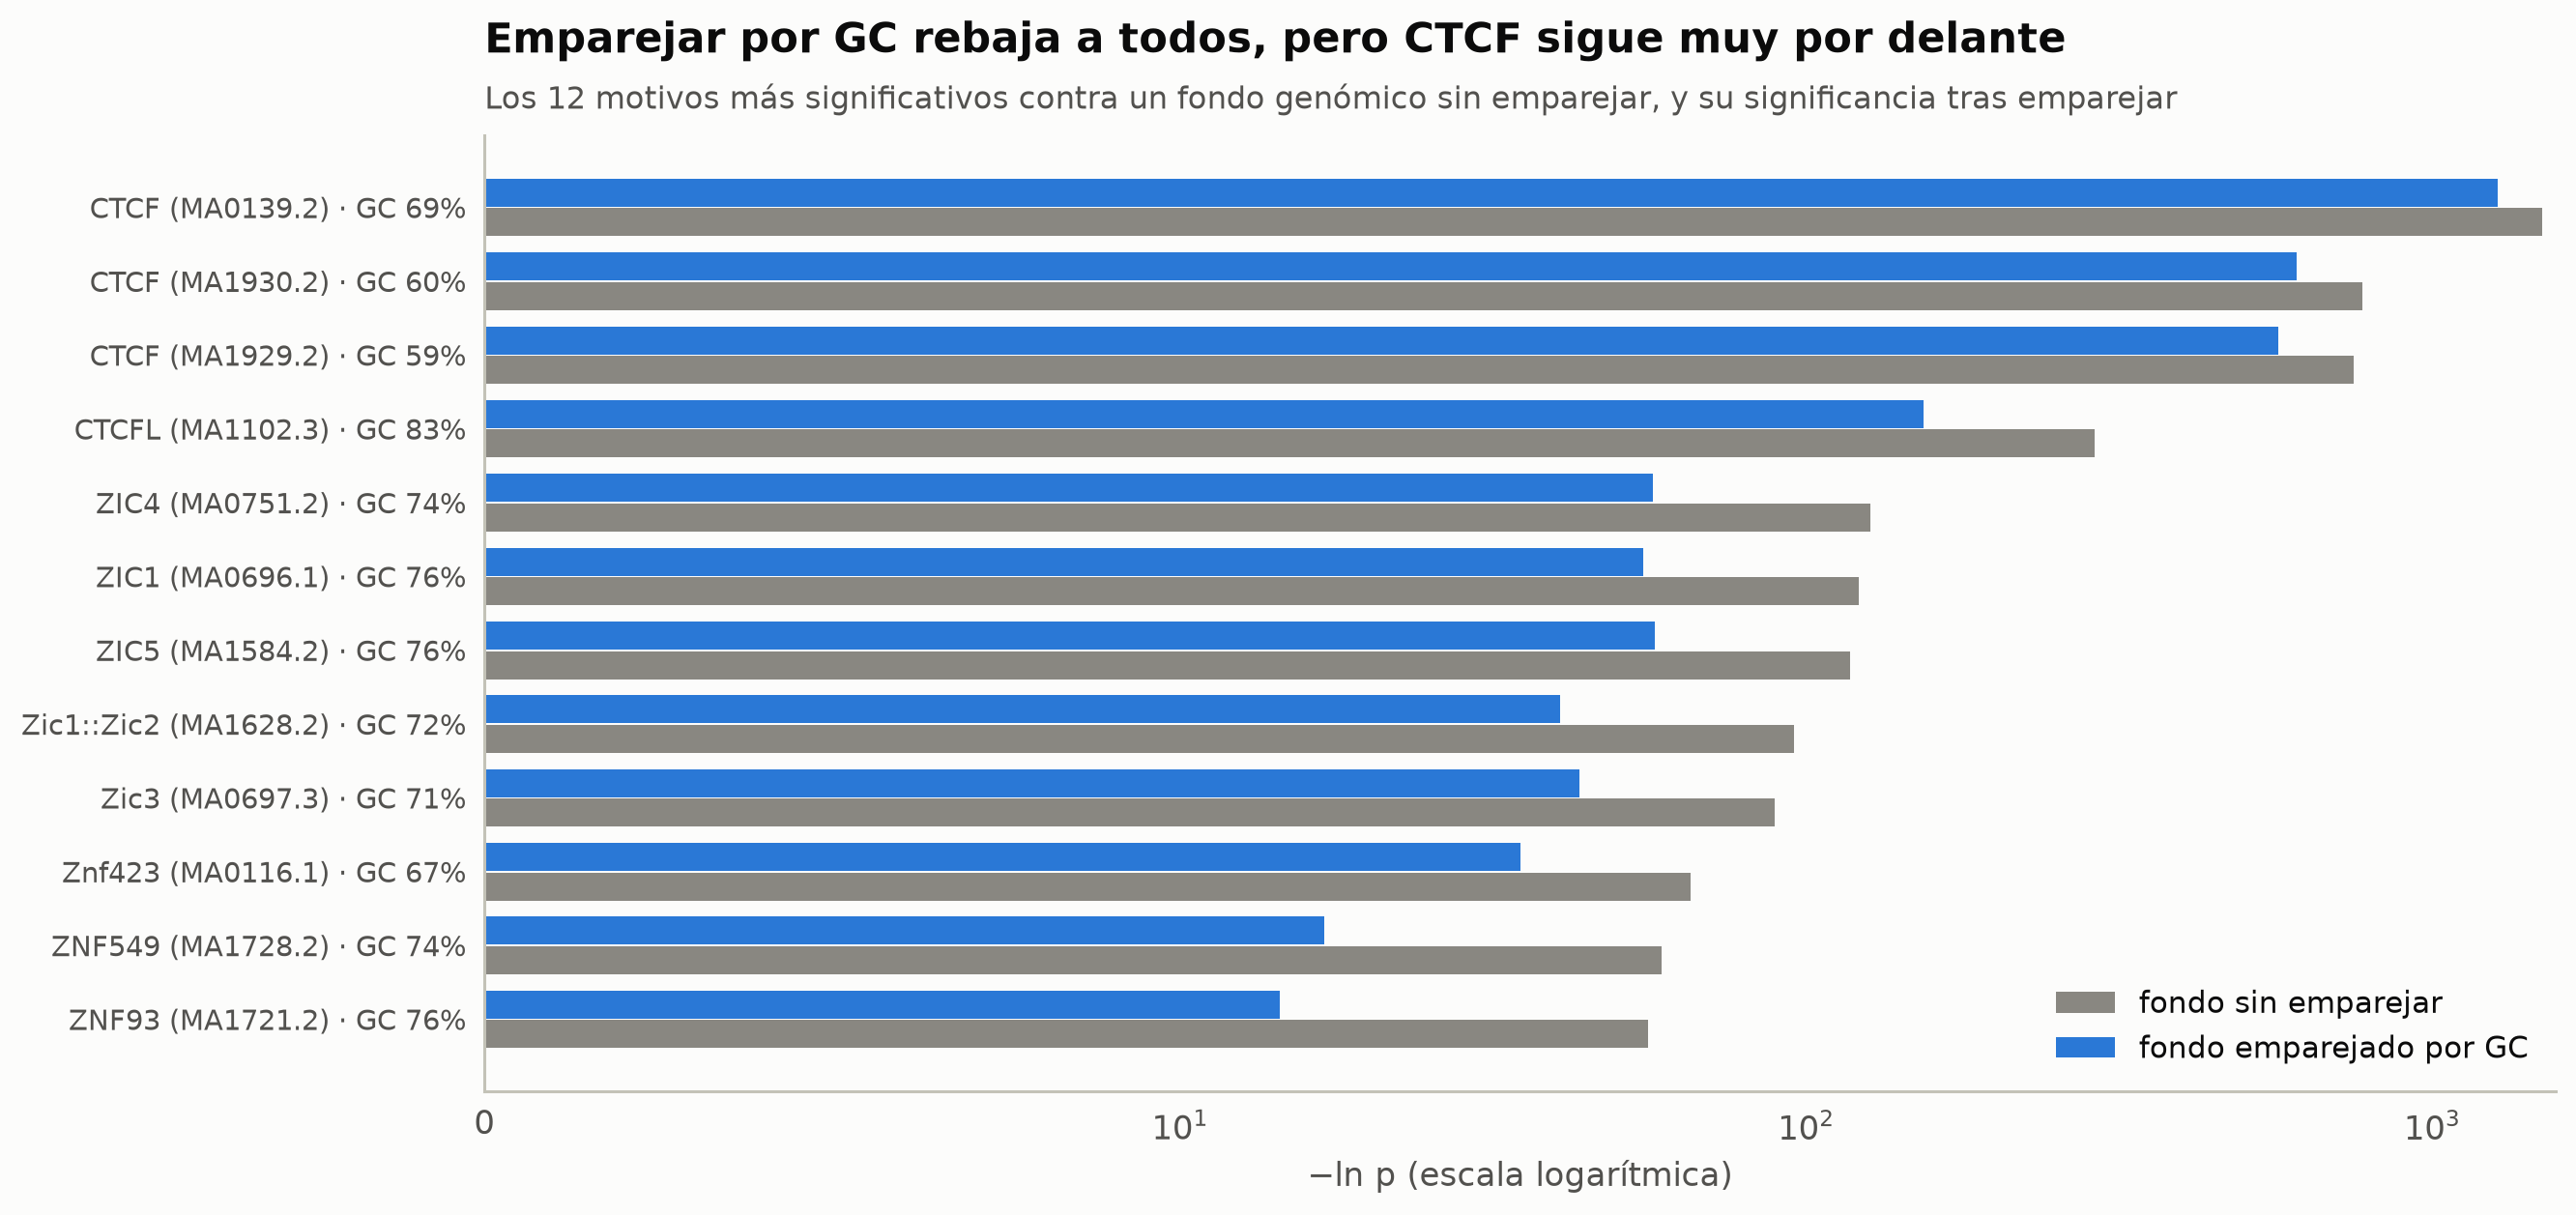

In [27]:
# ¿Qué cambia al emparejar por GC? Los 12 motivos más enriquecidos sin emparejar, antes y después
top_unm = enr_all.sort_values("ln_p").head(12)
after = enr_gc.set_index("id").loc[top_unm["id"]]
fig, ax = plt.subplots(figsize=(12, 5.6))
y = np.arange(len(top_unm))
ax.barh(y + 0.2, -top_unm["ln_p"], height=0.38, color=ec.MUTED, label="fondo sin emparejar")
ax.barh(y - 0.2, -after["ln_p"].values, height=0.38, color=ec.BLUE, label="fondo emparejado por GC")
ax.set_yticks(y)
ax.set_yticklabels([f"{f} ({m}) · GC {gc_motif[m]:.0%}" for f, m in zip(top_unm["factor"], top_unm["id"])], fontsize=9.5)
ax.invert_yaxis(); ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("−ln p (escala logarítmica)"); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=True)
ec.title(ax, "Emparejar por GC rebaja a todos, pero CTCF sigue muy por delante",
         "Los 12 motivos más significativos contra un fondo genómico sin emparejar, y su significancia tras emparejar")
plt.show()

> 🔎 **Qué observamos.** En el gráfico interactivo, los perfiles de CTCF quedan solos en la esquina superior
> derecha: MA0139.2 está en el 73 % de los picos y en menos del 4 % del fondo ponderado (unas 19 veces más). Les
> siguen CTCFL y una familia de motivos ricos en GC (los factores ZIC y varios dedos de zinc). Al pasar del fondo
> **sin emparejar** (círculos vacíos) al **emparejado por GC** (círculos llenos), **todos** los puntos bajan y se
> acercan al eje: parte del "enriquecimiento" era sólo composición. La barra horizontal lo muestra motivo a motivo:
> los motivos ricos en GC (ZIC, ZNF549, ZNF93…) pierden entre la mitad y las tres cuartas partes de su $-\ln p$, mientras
> que CTCF apenas baja (de unos 1 500 a unos 1 270) y sigue muy por delante. Es exactamente el sesgo del que advierte el libro. Que los
> motivos ZIC sigan algo enriquecidos tiene además otra explicación, que la sección siguiente pone a prueba: se
> parecen a un trozo del motivo de CTCF.

> ✅ **Compruebe su comprensión.** ¿Qué inconveniente tiene dar un peso de 7 a 9 a las pocas secuencias de fondo con
> más de 70 % de GC? *(Que el recuento ponderado depende mucho de unas pocas decenas de secuencias: si por azar una
> de ellas tiene el motivo, cuenta como nueve. HOMER mitiga esto con fondos mucho más grandes, de decenas de miles de
> secuencias.)*

> ✅ **Compruebe su comprensión.** Un motivo aparece en el 30 % de los picos y en el 25 % del fondo emparejado, con
> $\ln p=-40$ gracias a que hay miles de secuencias. ¿Es un hallazgo biológico importante? *(Probablemente no: el
> enriquecimiento es de sólo 1,2 veces. Con muestras grandes, $p$ mide sobre todo el tamaño de la muestra; el tamaño
> del efecto y el orden de los motivos importan más.)*

## 12. Centralidad al estilo de CentriMo: ¿unión directa o indirecta?

Un motivo enriquecido en los picos **no es necesariamente** el del factor inmunoprecipitado: puede ser el de un
**cofactor** que se une cerca, o reflejar un sesgo de las regiones abiertas. Bailey y Machanick (2012) observaron que,
si el factor se une **directamente** al ADN, sus sitios deben concentrarse en el **centro** de los picos (la posición
de la cumbre), mientras que los de cofactores se distribuyen más anchos y los del fondo, uniformemente. Piense en una
foto de grupo: la persona que organizó la foto está en el centro, sus amigos alrededor, y los desconocidos que pasaban
por la calle aparecen en cualquier sitio del encuadre.

Su herramienta **CentriMo** busca la ventana central donde el enriquecimiento es máximo y lo contrasta con una
**prueba binomial**: si una ventana de ancho $w_c$ ocupa una fracción

$$
f \;=\; \frac{w_c}{L-W+1}
$$

de las posiciones posibles, el número de **mejores sitios** (uno por secuencia) que caen dentro sigue, bajo la
hipótesis nula de que la posición es uniforme, una $\mathrm{Bin}(n,f)$.

| Símbolo | Significado |
|---|---|
| $L$, $W$ | longitud de las secuencias (picos) y ancho del motivo |
| $w_c$ | ancho de la ventana central, en posiciones |
| $f$ | fracción de posiciones posibles que cubre la ventana: la probabilidad nula de caer dentro |
| $n$ | número de secuencias con un sitio del motivo (sólo se cuenta el mejor de cada una) |

Así mostraron, por ejemplo, que en un conjunto de datos de Smad1 no había evidencia de unión directa del factor
inmunoprecipitado.

### La simulación del libro

3 000 picos simulados de 500 pb. El factor directo tiene sitio en el 55 % de los picos, con su centro a
$\mathcal N(0, 22^2)$ pb de la cumbre; un cofactor aparece en 1 050 picos con dispersión de 110 pb; un motivo sin
relación, en 750 picos en posiciones uniformes. Ventana central de ±50 pb: $f=101/481=0{,}210$. Los sorteos continúan
el mismo generador (semilla 108) que produjo las secuencias de la sección 2, como en el libro.

factor directo      : n = 1649, en ±50 pb = 1609 (0.976; esperado 0.210)  p binomial = 0.00e+00
cofactor            : n = 1050, en ±50 pb =  396 (0.377; esperado 0.210)  p binomial = 2.92e-35
motivo sin relación : n =  750, en ±50 pb =  161 (0.215; esperado 0.210)  p binomial = 3.90e-01


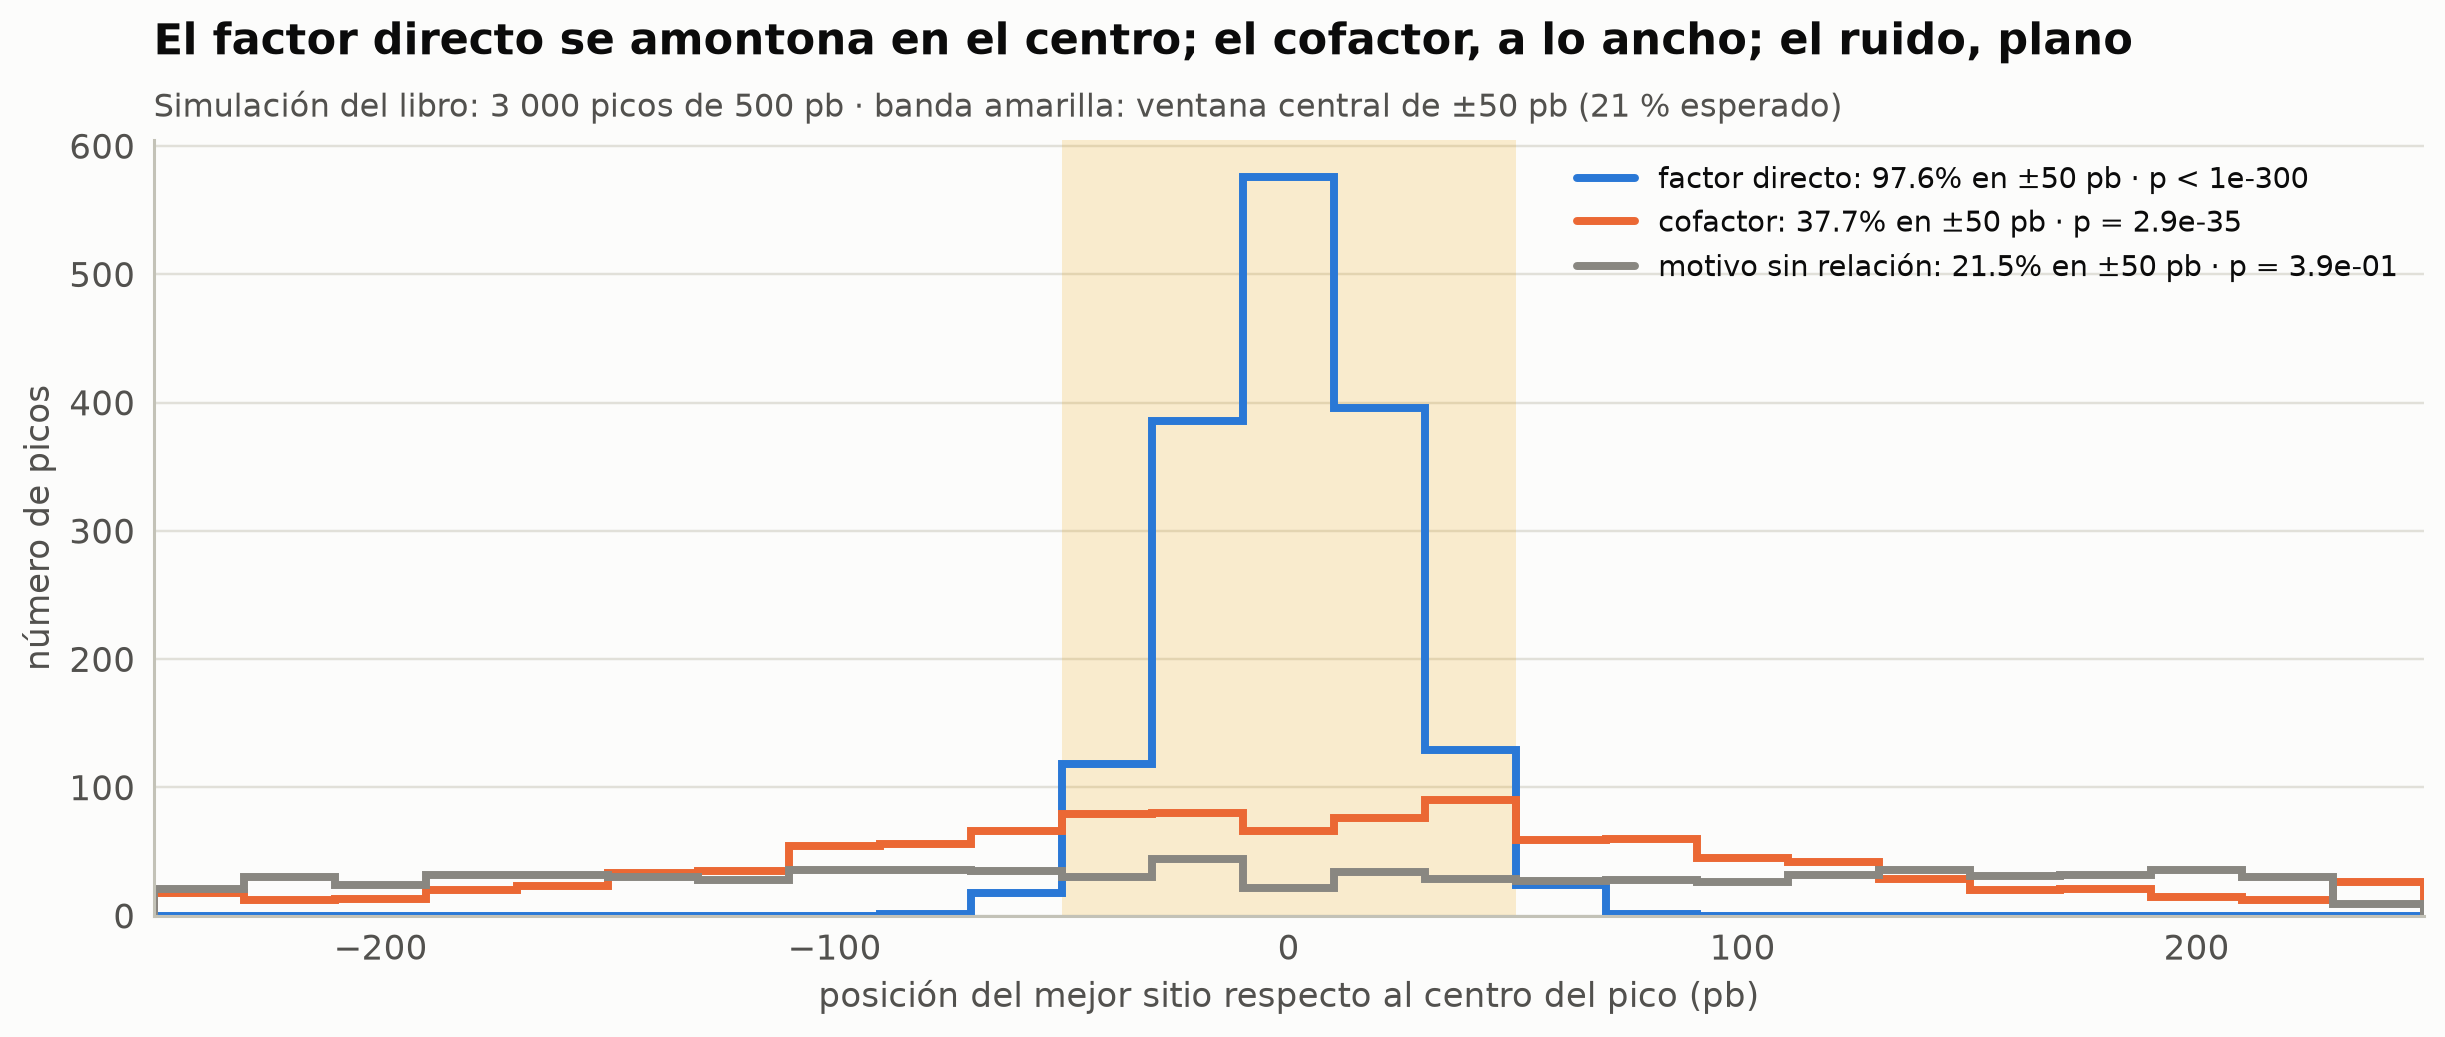

In [28]:
NP, LP = 3000, 500
pos_dir = np.clip(rng_libro.normal(0, 22, NP).round(), -240, 240)
tiene = rng_libro.random(NP) < 0.55
pos_dir = pos_dir[tiene]
pos_cof = np.clip(rng_libro.normal(0, 110, int(0.35 * NP)).round(), -240, 240)
pos_fondo = rng_libro.integers(-240, 241, int(0.25 * NP))
frac = 101 / 481
sim_res = {}
for nom, pp in [("factor directo", pos_dir), ("cofactor", pos_cof), ("motivo sin relación", pos_fondo)]:
    k = int((np.abs(pp) <= 50).sum()); n = len(pp)
    sim_res[nom] = (pp, k / n, stats.binom.sf(k - 1, n, frac))
    print(f"{nom:20s}: n = {n:4d}, en ±50 pb = {k:4d} ({k / n:.3f}; esperado {frac:.3f})  p binomial = {sim_res[nom][2]:.2e}")

fig, ax = plt.subplots(figsize=(11, 4.6))
bins_c = np.arange(-250, 251, 20)
ax.axvspan(-50, 50, color=ec.YELLOW, alpha=0.18, lw=0)
for (nom, (pp, fr, pv)), col in zip(sim_res.items(), [ec.BLUE, ec.ORANGE, ec.MUTED]):
    h, _ = np.histogram(pp, bins_c)
    ptxt = f"p = {pv:.1e}" if pv > 0 else "p < 1e-300"
    ax.stairs(h, bins_c, color=col, lw=2.6, label=f"{nom}: {fr:.1%} en ±50 pb · {ptxt}")
ax.set_xlim(-250, 250); ax.set_xlabel("posición del mejor sitio respecto al centro del pico (pb)")
ax.set_ylabel("número de picos"); ax.legend(loc="upper right", frameon=False, fontsize=9.5)
ec.title(ax, "El factor directo se amontona en el centro; el cofactor, a lo ancho; el ruido, plano",
         "Simulación del libro: 3 000 picos de 500 pb · banda amarilla: ventana central de ±50 pb (21 % esperado)")
plt.show()

> 🔎 **Qué observamos.** Los mejores sitios del factor inmunoprecipitado se concentran en los 100 pb centrales, donde
> cae el **97,6 %** de ellos frente al 21 % esperado; la prueba binomial da un valor $p$ numéricamente nulo. El motivo
> del cofactor está enriquecido, pero de forma mucho más ancha (37,7 %, $p=2{,}9\times10^{-35}$), y el motivo sin
> relación se distribuye de forma plana (21,5 %, $p=0{,}39$). La centralidad distingue unión directa de indirecta, algo
> que el simple enriquecimiento no puede hacer: un motivo de cofactor presente en muchos picos podría ganar en la
> prueba hipergeométrica, pero nunca se amontonaría en la cumbre.

### Con los datos reales

Escaneamos ahora los **500 pb** completos de los 1 000 picos con cuatro motivos de JASPAR: CTCF (MA0139.1), el
motivo ZIC mejor clasificado tras emparejar por GC, el motivo (ajeno a CTCF y ZIC) más significativo contra el fondo
**sin** emparejar, y como control un motivo con al menos 40 picos con sitio pero sin enriquecimiento (el más cercano a
×1). Además, en los picos que tienen a la vez un sitio del motivo y uno de CTCF, medimos con qué frecuencia el mejor
sitio del motivo **se solapa** con el mejor sitio de CTCF. Para cada pico nos quedamos con el **mejor** sitio (si supera el umbral $p<10^{-4}$) y registramos la
posición de su centro respecto a la cumbre.

In [29]:
def best_positions(seqs_int, pwm, thr_):
    """Posición del centro del mejor sitio (ambas hebras) respecto al centro de la secuencia; NaN si no supera thr_."""
    n, L = seqs_int.shape; w = len(pwm)
    P_ = L - w + 1
    wins = np.stack([seqs_int[:, j:j + w] for j in range(P_)], 1)
    cols = np.arange(w)
    s_f = pwm[cols, wins].sum(-1); s_r = rc_theta(pwm)[cols, wins].sum(-1)
    s = np.maximum(s_f, s_r)
    j = s.argmax(1); best = s.max(1)
    center = j + (w - 1) // 2 - L // 2
    return np.where(best >= thr_, center, np.nan), P_

X500 = np.stack([encode(s) for s in peaks["seq500"]])
fam = lambda f: f.upper().startswith(("CTCF", "ZIC"))
top_other = enr_gc[~enr_gc["factor"].map(fam)].iloc[0]["id"]                 # 1º tras emparejar, fuera de CTCF/ZIC
zic = enr_gc[enr_gc["factor"].str.upper().str.startswith("ZIC")].iloc[0]["id"]
top_gc_only = enr_all[~enr_all["factor"].map(fam)].sort_values("ln_p").iloc[0]["id"]  # 1º SIN emparejar
ctrl_pool = enr_gc[(enr_gc["k_t"] >= 40) & ~enr_gc["factor"].map(fam)]
control = ctrl_pool.iloc[np.argmin(np.abs(np.log2(ctrl_pool["fold"].values)))]["id"]
chosen = ["MA0139.1", zic, top_gc_only if top_gc_only != control else top_other, control]
pwm_by_id = dict(zip(ids, pwms)); thr_by_id = dict(zip(ids, thr))
pwm_by_id["MA0139.1"] = pwm_from_counts(cnt_ma); thr_by_id["MA0139.1"] = threshold_p(pwm_by_id["MA0139.1"])
jaspar_name["MA0139.1"] = "CTCF"
pos_ctcf_all, _ = best_positions(X500, pwm_by_id["MA0139.1"], thr_by_id["MA0139.1"])
cent_res = []
for mid in chosen:
    pos_all, P_ = best_positions(X500, pwm_by_id[mid], thr_by_id[mid])
    both = ~np.isnan(pos_all) & ~np.isnan(pos_ctcf_all)
    # ¿el mejor sitio del motivo se solapa con el mejor sitio de CTCF del mismo pico?
    solapa = np.abs(pos_all[both] - pos_ctcf_all[both]) <= (len(pwm_by_id[mid]) + 19) / 2
    pos = pos_all[~np.isnan(pos_all)]
    n = len(pos); k = int((np.abs(pos) <= 50).sum()); f = 101 / P_
    ov = solapa.mean() if both.any() else np.nan
    cent_res.append(dict(id=mid, factor=jaspar_name[mid], n=n, k=k, frac=k / n, f=f, overlap=ov,
                         p=stats.binom.sf(k - 1, n, f), logp=stats.binom.logsf(k - 1, n, f) / np.log(10), pos=pos))
    print(f"{jaspar_name[mid]:>12s} ({mid}): n = {n:4d} picos con sitio · en ±50 pb: {k:4d} ({k / n:.1%}, "
          f"esperado {f:.1%}) · log10 p = {cent_res[-1]['logp']:.1f} · "
          f"se solapa con el sitio de CTCF: {ov:.0%}"
          .replace("-inf", "< −300"))

        CTCF (MA0139.1): n =  823 picos con sitio · en ±50 pb:  748 (90.9%, esperado 21.0%) · log10 p = < −300 · se solapa con el sitio de CTCF: 100%
        ZIC5 (MA1584.2): n =  177 picos con sitio · en ±50 pb:  100 (56.5%, esperado 20.8%) · log10 p = -24.5 · se solapa con el sitio de CTCF: 52%


      Znf423 (MA0116.1): n =  141 picos con sitio · en ±50 pb:   70 (49.6%, esperado 20.8%) · log10 p = -13.5 · se solapa con el sitio de CTCF: 37%
       ZFP14 (MA1972.1): n =  237 picos con sitio · en ±50 pb:   42 (17.7%, esperado 20.8%) · log10 p = -0.0 · se solapa con el sitio de CTCF: 5%


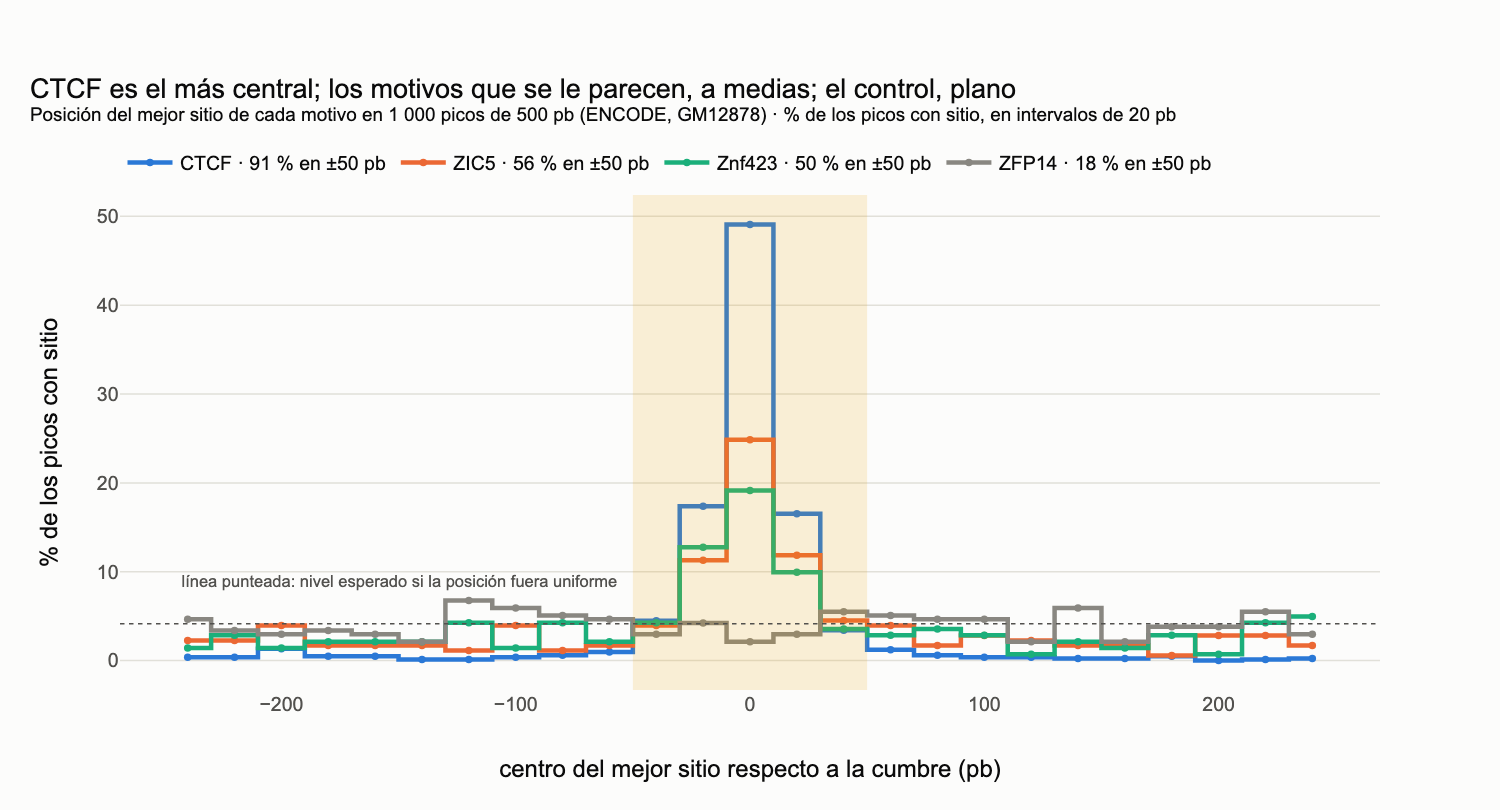

In [30]:
bins_r = np.arange(-250, 251, 20)
mids = (bins_r[:-1] + bins_r[1:]) / 2
fig = go.Figure()
fig.add_vrect(x0=-50, x1=50, fillcolor=ec.YELLOW, opacity=0.15, line_width=0)
for r, col in zip(cent_res, [ec.BLUE, ec.ORANGE, ec.AQUA, ec.MUTED]):
    h, _ = np.histogram(r["pos"], bins_r)
    hover = [f"<b>{r['factor']}</b> ({r['id']})<br>centro del sitio entre {a:+d} y {a + 20:+d} pb<br>{c} picos "
             f"({100 * c / r['n']:.1f} % de los {r['n']} con sitio)<br>en ±50 pb: {100 * r['frac']:.1f} % "
             f"(esperado {100 * r['f']:.1f} %)<br>log₁₀ p binomial = "
             + (f"{r['logp']:.1f}" if np.isfinite(r['logp']) else "< −300")
             for a, c in zip(bins_r[:-1], h)]
    fig.add_trace(go.Scatter(x=mids, y=100 * h / r["n"], mode="lines+markers", line=dict(color=col, width=3, shape="hvh"),
                             marker=dict(size=5), name=f"{r['factor']} · {100 * r['frac']:.0f} % en ±50 pb",
                             text=hover, hovertemplate="%{text}<extra></extra>"))
fig.add_hline(y=100 * 20 / (500 - 19 + 1), line=dict(color=ec.INK_2, dash="dot", width=1))
fig.add_annotation(x=-150, y=9, text="línea punteada: nivel esperado si la posición fuera uniforme", showarrow=False,
                   font=dict(size=11, color=ec.INK_2))
fig.update_layout(
    title="CTCF es el más central; los motivos que se le parecen, a medias; el control, plano<br><sup>Posición del mejor sitio de "
          "cada motivo en 1 000 picos de 500 pb (ENCODE, GM12878) · % de los picos con sitio, en intervalos de 20 pb</sup>",
    xaxis_title="centro del mejor sitio respecto a la cumbre (pb)", yaxis_title="% de los picos con sitio",
    height=540, margin=dict(t=130), legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** El perfil de CTCF es un pico estrecho en la cumbre: el 91 % de sus mejores sitios cae a menos
> de 50 pb, frente al 21 % que caería ahí por azar, con un valor $p$ binomial fuera de escala. El motivo de control es
> plano (incluso algo por debajo del 21 % en el centro, donde el propio sitio de CTCF ocupa el espacio). Los motivos
> ZIC y Znf423 son un caso intermedio instructivo: también se concentran en el centro, pero sólo alrededor de la mitad
> de sus mejores sitios, con perfiles más bajos. La columna de solapamiento explica por qué: entre un tercio y la
> mitad de sus mejores sitios **se superponen con el sitio de CTCF** del mismo pico (frente a un 5 % en el control). Comparten con el motivo de CTCF un trozo
> rico en G, y en muchos picos su "mejor sitio" es, en realidad, el propio sitio de CTCF leído parcialmente. Por eso, antes de proponer que un motivo secundario es un cofactor, conviene comprobar
> que no es un eco del motivo principal (MEME-ChIP, por ejemplo, agrupa los motivos parecidos). En este experimento no hay duda: CTCF se une
> **directamente** al ADN en sus picos. En un experimento de un factor sin dominio de unión al ADN (un cofactor como
> p300, o una subunidad de cohesina), el motivo más central sería el del factor que lo recluta.

## 13. Motivos que engañan

El libro cierra con tres advertencias. Las comprobamos con nuestros datos.

1. **Baja complejidad y repeticiones.** Tramos como `CACACACA` o poli-A se "descubren" con enorme significancia;
   enmascare repeticiones y use modelos de fondo de orden superior. Ya vimos que el pico más intenso del experimento
   está en una repetición en tándem. ¿Qué fracción de las bases de nuestras secuencias están enmascaradas por UCSC?
2. **Sesgo de GC.** Los promotores son ricos en GC; sin un fondo emparejado, cualquier motivo rico en GC parecerá
   enriquecido (sección 11).
3. **Presencia no es ocupación.** Un genoma humano contiene cientos de miles de coincidencias de casi cualquier PWM; la
   inmensa mayoría no está ocupada, porque la **accesibilidad de la cromatina** (lección 13.1) decide. Estimemos
   cuántos sitios de CTCF "de secuencia" tiene el genoma y comparémoslo con los 41 017 picos del experimento.

In [31]:
masked_pk = np.mean([sum(c.islower() for c in s) / len(s) for s in peaks["seq"]])
masked_cen = np.mean([sum(c.islower() for c in s[200:300]) / 100 for s in peaks["seq"]])
masked_bg = np.mean([sum(c.islower() for c in s) / len(s) for s in bg["masked"]])
print(f"Bases enmascaradas (repeticiones): picos 500 pb {masked_pk:.1%} · 100 pb centrales {masked_cen:.1%} · "
      f"fondo genómico {masked_bg:.1%}")

# Presencia frente a ocupación: coincidencias de MA0139.1 (p < 1e-4) en el fondo genómico
pwm_ctcf, thr_ctcf = pwm_by_id["MA0139.1"], thr_by_id["MA0139.1"]
w = len(pwm_ctcf)
wins_b = np.stack([X_b[:, j:j + w] for j in range(100 - w + 1)], 1)
cols = np.arange(w)
hits_b = ((pwm_ctcf[cols, wins_b].sum(-1) >= thr_ctcf).sum() + (rc_theta(pwm_ctcf)[cols, wins_b].sum(-1) >= thr_ctcf).sum())
per_bp = hits_b / (len(X_b) * (100 - w + 1))
genome = 3.1e9
print(f"Coincidencias de CTCF (p < 1e-4, dos hebras) en {len(X_b)} fragmentos al azar: {hits_b} "
      f"→ {per_bp * 1e3:.2f} por kb")
print(f"Extrapolado al genoma (~3,1 Gb): ~{per_bp * genome:,.0f} sitios de secuencia · picos de CTCF en GM12878: 41 017 "
      f"(como mucho un {41017 / (per_bp * genome):.0%} ocupados)")
print(f"Y a la inversa: {np.mean(best_t[:, ids.index('MA0139.2')] >= thr[ids.index('MA0139.2')]):.0%} de los picos "
      f"tienen un sitio de MA0139.2 en los 100 pb centrales")

Bases enmascaradas (repeticiones): picos 500 pb 25.5% · 100 pb centrales 19.2% · fondo genómico 55.3%
Coincidencias de CTCF (p < 1e-4, dos hebras) en 6202 fragmentos al azar: 106 → 0.21 por kb
Extrapolado al genoma (~3,1 Gb): ~646,133 sitios de secuencia · picos de CTCF en GM12878: 41 017 (como mucho un 6% ocupados)
Y a la inversa: 73% de los picos tienen un sitio de MA0139.2 en los 100 pb centrales


> 🔎 **Qué observamos.** Las repeticiones no dominan nuestras secuencias: la fracción enmascarada en los picos es
> incluso menor que en el genoma promedio, así que el motivo de CTCF no es un artefacto de repeticiones (aunque algunas
> familias de elementos transponibles sí llevan sitios de CTCF y han contribuido a extenderlos por el genoma). La
> tercera advertencia es la más importante: el genoma tiene **cientos de miles** de coincidencias con el motivo de
> CTCF, muchas más que picos en GM12878; sólo una fracción está ocupada en esta célula, y cuáles lo estén depende de la
> accesibilidad, de la metilación del sitio (lección 13.2: la metilación de la CpG del motivo impide la unión de CTCF,
> un mecanismo clásico de la impronta genómica) y de otras proteínas. **Encontrar una coincidencia no es encontrar un
> sitio de unión.**

### En la práctica: las herramientas de verdad

Todo lo que hemos programado existe, optimizado y con estadística más cuidadosa, en dos paquetes estándar (este es
el recuadro de consola del libro; no se ejecuta en Colab porque requiere el genoma completo y la instalación de las
herramientas):

```bash
# 100 pb alrededor de la cumbre de cada pico
awk -v OFS='\t' '{s=$2+$10-50; print $1,s,s+100}' \
    ctcf_idr.narrowPeak > cumbres.bed
bedtools getfasta -fi hg38.fa -bed cumbres.bed -fo cumbres.fa
# MEME Suite: de novo + enriquecimiento + centralidad
meme-chip -oc memechip -meme-nmotifs 5 \
    -db JASPAR2022_CORE_vertebrates.meme cumbres.fa
# HOMER: fondo emparejado por GC
findMotifsGenome.pl cumbres.bed hg38 homer_out -size given
```

`meme-chip` encadena MEME (EM, secciones 4 y 8), STREME, Tomtom (sección 10), CentriMo (sección 12) y un análisis de
enriquecimiento; `findMotifsGenome.pl` hace el análisis de la sección 11 con un fondo emparejado por GC y además
descubre motivos *de novo*.

> 💡 **Idea clave.** Descubrir motivos es estimar una PWM con **datos incompletos**: EM reparte votos fraccionarios y
> sube por la verosimilitud; Gibbs muestrea posiciones y puede escapar de óptimos locales. Ninguno garantiza el óptimo
> global: **múltiples arranques**, **fondos emparejados** y el criterio de **centralidad** convierten una matriz en una
> hipótesis biológica.

## ✍️ Ejercicios

**Ejercicio 1 — Un paso E con un sitio mutado (básico).** Suponga que en la secuencia 18 de la simulación el sitio
fuera `ATGACTTA` (8,78 bits) en lugar de `ATGACTCA` (12,87 bits), sin cambiar nada más. Calcule a mano cuánto vale ahora
$r$ y estime el nuevo $Z$ del sitio usando que la suma de $r$ de las otras 72 ventanas es aproximadamente
$\sum_{j\neq 18} r_{ij}=r_{\text{sitio}}\cdot(1-0{,}9976)/0{,}9976$. Compruébelo con `lr_all`.

**Ejercicio 2 — El modelo ZOOPS (intermedio).** Modifique `em` para el modelo **ZOOPS** añadiendo, para cada secuencia,
un estado "sin sitio" con probabilidad a priori $1-\gamma$ (y $\gamma/m$ para cada posición). Escriba el paso E (las
$Z_{ij}$ ya no suman 1: lo que falta es la probabilidad de "sin sitio") y el paso M para $\gamma$ (la media, sobre las
secuencias, de $\sum_j Z_{ij}$). Pruébelo en una copia de la simulación donde 10 de las 30 secuencias se sustituyen
por ruido: ¿qué $\gamma$ estima y qué probabilidad de tener sitio asigna a las secuencias sin sitio?

**Ejercicio 3 — Movimientos de desfase en Gibbs (avanzado).** Añada al muestreador de Gibbs, después de cada barrido,
un movimiento que proponga desplazar **todas** las posiciones $\pm1$ y lo acepte con probabilidad
$\min\bigl(1, 2^{F_{\text{nuevo}}-F_{\text{actual}}}\bigr)$, donde $F=\sum_i\log_2 r_{i,a_i}(q)$ es la puntuación del
alineamiento. Compare, con 20 cadenas de 30 barridos, la fracción que alcanza el motivo correcto con y sin ese
movimiento.

**Ejercicio 4 — ¿Los picos más intensos tienen más motivo? (datos reales).** Divida los 1 000 picos de CTCF en cinco
grupos (quintiles) según su señal (`peaks["signal"]`) y calcule en cada grupo la fracción con un sitio de MA0139.2 en
los 100 pb centrales (use `best_t` y `thr`). ¿Qué relación observa y cómo la interpreta?

**Proyecto opcional (el ejercicio del libro).** Descargue de ENCODE los picos IDR de CTCF en otra línea celular
(por ejemplo, K562), extraiga ±50 pb alrededor de cada cumbre y ejecute `meme-chip`. ¿Coincide el motivo principal con
el perfil MA0139 de JASPAR? ¿Qué fracción de los picos lo contiene y qué muestra el análisis de centralidad?

In [32]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
r_old, r_new = 2 ** 12.87, 2 ** 8.78
rest = r_old * (1 - 0.9976) / 0.9976                  # suma de r de las otras 72 ventanas
print(f"r(ATGACTTA) = 2^8,78 ≈ {r_new:,.0f}  (antes {r_old:,.0f})")
print(f"Z estimado a mano = {r_new:,.0f} / ({r_new:,.0f} + {rest:,.1f}) = {r_new / (r_new + rest):.4f}")
lr_mut = lr_all[i_ej].copy(); lr_mut[sitio_real[i_ej]] = 8.78
Zm = np.exp2(lr_mut - lr_mut.max()); Zm /= Zm.sum()
print(f"Con lr_all: Z = {Zm[sitio_real[i_ej]]:.4f}  → una sola base cambiada y el sitio sigue ganando, pero cede ~16 veces más voto")

r(ATGACTTA) = 2^8,78 ≈ 440  (antes 7,486)
Z estimado a mano = 440 / (440 + 18.0) = 0.9606
Con lr_all: Z = 0.9608  → una sola base cambiada y el sitio sigue ganando, pero cede ~16 veces más voto


In [33]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
def em_zoops(theta, windows, gamma=0.5, iters=40, beta=0.1, p0=np.full(4, 0.25)):
    """EM para ZOOPS: cada secuencia tiene un sitio (prob. γ, repartida en m posiciones) o ninguno (prob. 1-γ)."""
    N, m, W = windows.shape
    for _ in range(iters):
        lr = (np.log2(theta[np.arange(W), windows]) - np.log2(p0)[windows]).sum(-1)     # log2 r_ij
        # Paso E: P(sitio en j | X_i) = (γ/m) r_ij / [ (1-γ) + (γ/m) Σ_j' r_ij' ]
        num = np.log2(gamma / m) + lr
        mx = np.maximum(num.max(1, keepdims=True), np.log2(1 - gamma))
        den = np.exp2(num - mx).sum(1, keepdims=True) + np.exp2(np.log2(1 - gamma) - mx)
        Z = np.exp2(num - mx) / den
        # Paso M: θ con conteos fraccionarios y γ = media de la probabilidad de tener sitio
        cnt = np.stack([(Z[..., None] * (windows == b)).sum((0, 1)) for b in range(4)], 1)
        theta = (cnt + beta) / (cnt + beta).sum(1, keepdims=True)
        gamma = float(np.clip(Z.sum(1).mean(), 1e-3, 1 - 1e-3))
    return theta, gamma, Z

rng_ex = np.random.default_rng(5)
seqs_z = seqs.copy()
sin_sitio = rng_ex.choice(NSEQ, 10, replace=False)
seqs_z[sin_sitio] = rng_ex.integers(0, 4, (10, LSEQ))                    # 10 secuencias de puro ruido
win_z = np.stack([seqs_z[:, j:j + Wm] for j in range(M)], axis=1)
th_z, g_z, Z_z = em_zoops(seed_matrix(seqs[12, sitio_real[12]:sitio_real[12] + Wm]), win_z)
psite = Z_z.sum(1)
print(f"Consenso: {kmer(th_z)} · γ estimado = {g_z:.2f} (verdadero 20/30 = 0,67)")
print(f"P(tener sitio): secuencias con sitio, mediana {np.median(np.delete(psite, sin_sitio)):.2f} · "
      f"secuencias sin sitio, mediana {np.median(psite[sin_sitio]):.2f}")
print("→ Con un motivo de sólo ~8 bits en 73 posiciones, ZOOPS separa mal: bajo el fondo, la media de r_ij es exactamente 1,\n"
      "  así que una secuencia de ruido 'se parece' en promedio tanto a tener sitio como a no tenerlo.")

# Con un motivo de ~16 bits (CTCF) la separación es clara: 300 picos + 100 fragmentos genómicos sin CTCF
X_mix = np.vstack([X_ctcf, np.stack([encode(s_) for s_ in bg["seq100"][:100]])])
th_c, g_c, Z_c = em_zoops(theta_em, windows_both(X_mix, W_CTCF), gamma=0.5, p0=p0_ctcf)
ps = Z_c.sum(1)
print(f"CTCF: γ estimado = {g_c:.2f} · P(sitio) mediana en picos {np.median(ps[:N_EM]):.2f}, "
      f"en fondo genómico {np.median(ps[N_EM:]):.3f}")

Consenso: ATGAGTCA · γ estimado = 0.85 (verdadero 20/30 = 0,67)
P(tener sitio): secuencias con sitio, mediana 0.98 · secuencias sin sitio, mediana 0.72
→ Con un motivo de sólo ~8 bits en 73 posiciones, ZOOPS separa mal: bajo el fondo, la media de r_ij es exactamente 1,
  así que una secuencia de ruido 'se parece' en promedio tanto a tener sitio como a no tenerlo.


CTCF: γ estimado = 0.73 · P(sitio) mediana en picos 1.00, en fondo genómico 0.003


In [34]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
def gibbs_shift(seed, sweeps=30, beta=0.25, shift=True, windows=win, p0=p0):
    g = np.random.default_rng(seed)
    N, m, W = windows.shape
    cols = np.arange(W)
    a = g.integers(0, m, N)
    def counts(a_):
        c = np.zeros((W, 4))
        for i in range(N):
            c[cols, windows[i, a_[i]]] += 1
        return c
    def F(a_):                                              # puntuación del alineamiento
        q = (counts(a_) + beta) / (counts(a_) + beta).sum(1, keepdims=True)
        return (np.log2(q[cols, windows[np.arange(N), a_]]) - np.log2(p0)[windows[np.arange(N), a_]]).sum()
    total = counts(a)
    for sw in range(sweeps):
        for z in g.permutation(N):
            total[cols, windows[z, a[z]]] -= 1
            q = (total + beta) / (total + beta).sum(1, keepdims=True)
            lr = (np.log2(q[cols, windows[z]]) - np.log2(p0)[windows[z]]).sum(-1)
            pr = np.exp2(lr - lr.max()); a[z] = g.choice(m, p=pr / pr.sum())
            total[cols, windows[z, a[z]]] += 1
        if shift:
            d = g.choice([-1, 1])
            a_new = a + d
            if a_new.min() >= 0 and a_new.max() < m and g.random() < min(1.0, 2 ** (F(a_new) - F(a))):
                a = a_new; total = counts(a)
    return a

res = {}
for shift in (False, True):
    ok = [np.mean(gibbs_shift(100 + s, shift=shift) == sitio_real) >= 0.5 for s in range(20)]
    res[shift] = np.mean(ok)
print(f"Cadenas que colocan ≥ 50 % de los sitios en la posición exacta: sin desfase {res[False]:.0%} · "
      f"con movimiento de desfase {res[True]:.0%}")

Cadenas que colocan ≥ 50 % de los sitios en la posición exacta: sin desfase 30% · con movimiento de desfase 90%


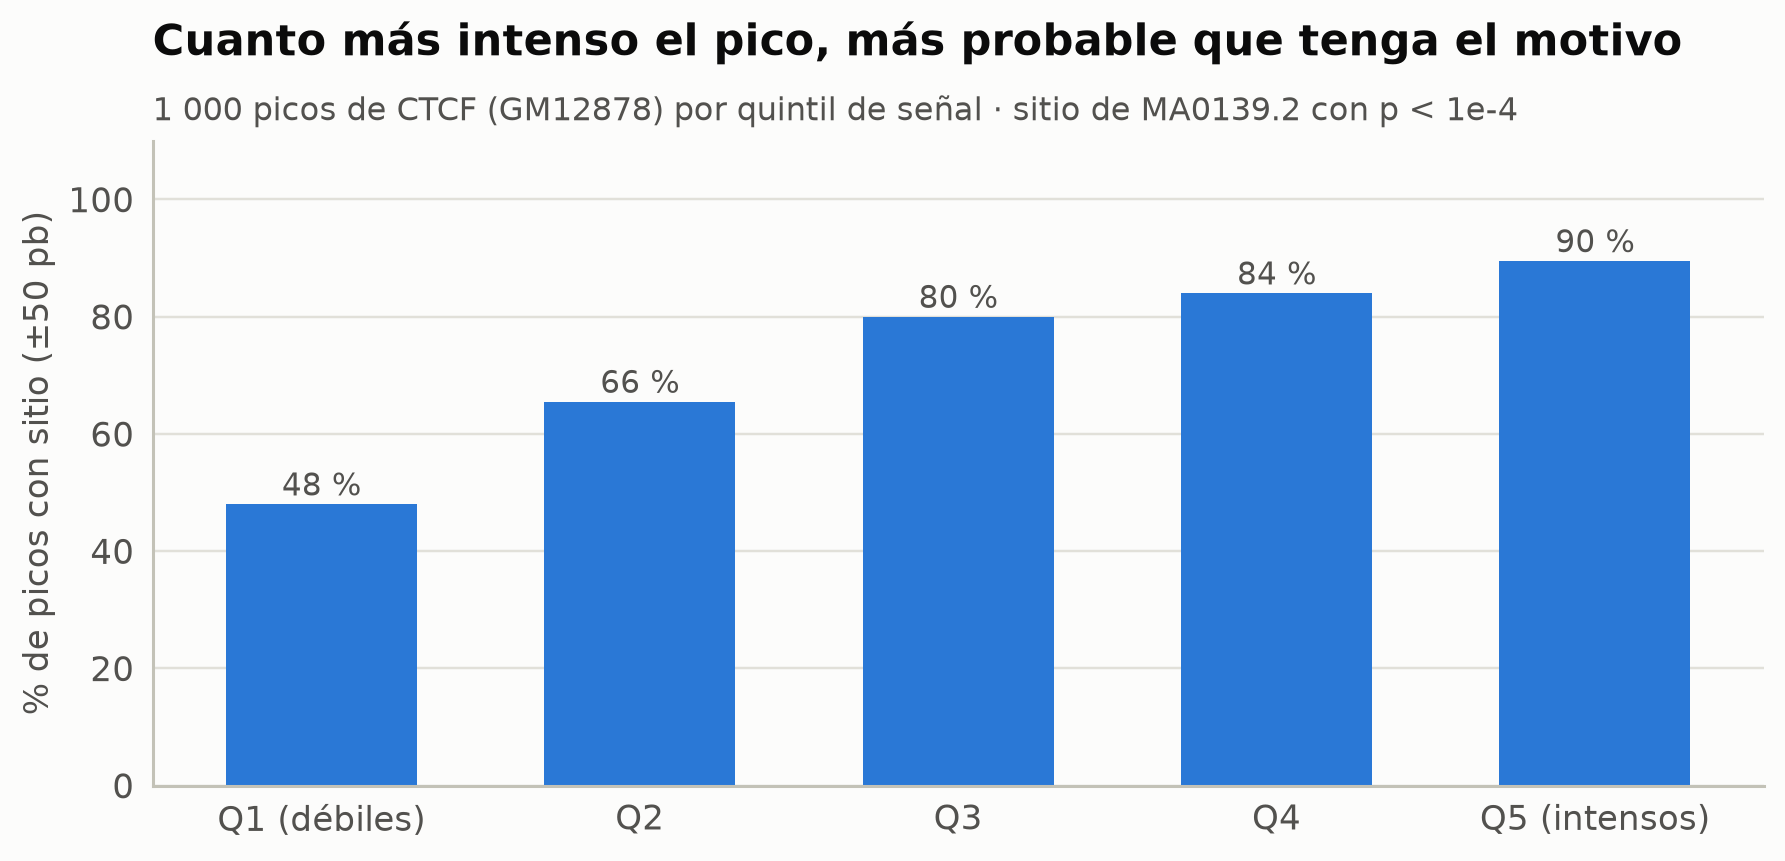

Interpretación: los picos débiles incluyen más unión indirecta (a través de otras proteínas o bucles de cromatina), sitios degenerados y falsos positivos; los intensos, casi siempre, un sitio canónico.


In [35]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
k2 = ids.index("MA0139.2")
has = best_t[:, k2] >= thr[k2]
quint = pd.qcut(peaks["signal"], 5, labels=["Q1 (débiles)", "Q2", "Q3", "Q4", "Q5 (intensos)"])
tab = pd.DataFrame({"quintil": quint, "motivo": has}).groupby("quintil", observed=True)["motivo"].mean()
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(tab.index.astype(str), 100 * tab.values, color=ec.BLUE, width=0.6)
for x_, v in enumerate(tab.values):
    ax.text(x_, 100 * v + 1.5, f"{100 * v:.0f} %", ha="center", fontsize=10, color=ec.INK_2)
ax.set_ylim(0, 110); ax.set_ylabel("% de picos con sitio (±50 pb)"); ax.grid(axis="x", visible=False)
ec.title(ax, "Cuanto más intenso el pico, más probable que tenga el motivo",
         "1 000 picos de CTCF (GM12878) por quintil de señal · sitio de MA0139.2 con p < 1e-4")
plt.show()
print("Interpretación: los picos débiles incluyen más unión indirecta (a través de otras proteínas o bucles de "
      "cromatina), sitios degenerados y falsos positivos; los intensos, casi siempre, un sitio canónico.")

## 📌 Resumen

* El **descubrimiento de motivos** es un problema de **datos incompletos**: no conocemos ni la matriz $\theta$ ni las
  posiciones $Z_{ij}$ de los sitios. En el modelo **OOPS**, la razón de verosimilitudes de una secuencia es la media de
  $r_{ij}=\prod_k\theta_{k,x}/p_0(x)$, y $\log_2 r_{ij}$ es la puntuación PWM de la lección 4.2.
* **EM** alterna el **paso E** (votos fraccionarios $Z_{ij}\propto r_{ij}$) y el **paso M** (PWM con esos votos más
  seudoconteos). Por la desigualdad de Jensen nunca disminuye la verosimilitud, pero puede quedarse en óptimos locales
  y en **desfases**. **MEME** añade modelos ZOOPS/TCM, semillas tomadas de subcadenas reales y un valor $E$. Con pocos
  sitios, la máxima verosimilitud **sobreajusta** (8,75 frente a 8,11 bits en la simulación).
* El **muestreador de Gibbs** mantiene posiciones concretas, retira una secuencia, reconstruye $q$ y **sortea** una
  nueva posición; puede escapar de colinas locales, pero también sufre desfases: se lanzan muchas cadenas y se añaden
  movimientos de desplazamiento.
* Con **datos reales** de ENCODE (CTCF en GM12878), EM y Gibbs programados desde cero, con las **dos hebras** y un fondo
  estimado de los datos, redescubren el motivo de CTCF, que coincide con **JASPAR MA0139** en una comparación columna
  a columna tipo **Tomtom**.
* El **enriquecimiento diferencial** (HOMER) usa la prueba **hipergeométrica** y un fondo **emparejado por GC**; sin
  emparejar, los motivos ricos en GC parecen enriquecidos. Los valores $p$ extremos no se leen literalmente: importan
  el orden y el tamaño del enriquecimiento.
* La **centralidad** (CentriMo) distingue unión **directa** (sitios amontonados en la cumbre) de indirecta (cofactores,
  distribución ancha) con una prueba **binomial** en una ventana central.
* **Presencia no es ocupación**: el genoma tiene cientos de miles de coincidencias con el motivo de CTCF, y sólo una
  parte está ocupada en cada tipo celular.

**Próximo módulo:** de la regulación de un genoma a las comunidades de muchos genomas: la **metagenómica** y el
microbioma (Módulo 14).

## 📚 Para profundizar

* Dempster, A. P., Laird, N. M. & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm.
  *Journal of the Royal Statistical Society: Series B* 39(1): 1–22. https://doi.org/10.1111/j.2517-6161.1977.tb01600.x
* Lawrence, C. E., Altschul, S. F., Boguski, M. S., Liu, J. S., Neuwald, A. F. & Wootton, J. C. (1993). Detecting
  subtle sequence signals: a Gibbs sampling strategy for multiple alignment. *Science* 262(5131): 208–214.
  https://doi.org/10.1126/science.8211139
* Bailey, T. L. & Elkan, C. (1994). Fitting a mixture model by expectation maximization to discover motifs in
  biopolymers. *Proceedings of the Second International Conference on Intelligent Systems for Molecular Biology* 2: 28–36.
* Bailey, T. L., Boden, M., Buske, F. A., Frith, M., Grant, C. E., Clementi, L. et al. (2009). MEME SUITE: tools for
  motif discovery and searching. *Nucleic Acids Research* 37(Web Server): W202–W208. https://doi.org/10.1093/nar/gkp335
* Gupta, S., Stamatoyannopoulos, J. A., Bailey, T. L. & Noble, W. S. (2007). Quantifying similarity between motifs.
  *Genome Biology* 8(2): R24. https://doi.org/10.1186/gb-2007-8-2-r24 (Tomtom)
* Bailey, T. L. & Machanick, P. (2012). Inferring direct DNA binding from ChIP-seq. *Nucleic Acids Research* 40(17):
  e128. https://doi.org/10.1093/nar/gks433 (CentriMo)
* Heinz, S., Benner, C., Spann, N., Bertolino, E., Lin, Y. C., Laslo, P. et al. (2010). Simple combinations of
  lineage-determining transcription factors prime cis-regulatory elements required for macrophage and B cell
  identities. *Molecular Cell* 38(4): 576–589. https://doi.org/10.1016/j.molcel.2010.05.004 (HOMER)
* Castro-Mondragon, J. A., Riudavets-Puig, R., Rauluseviciute, I., Berhanu Lemma, R., Turchi, L., Blanc-Mathieu, R.
  et al. (2022). JASPAR 2022: the 9th release of the open-access database of transcription factor binding profiles.
  *Nucleic Acids Research* 50(D1): D165–D173. https://doi.org/10.1093/nar/gkab1113
* Rauluseviciute, I., Riudavets-Puig, R., Blanc-Mathieu, R., Castro-Mondragon, J. A., Ferenc, K., Kumar, V. et al.
  (2024). JASPAR 2024: 20th anniversary of the open-access database of transcription factor binding profiles.
  *Nucleic Acids Research* 52(D1): D174–D182. https://doi.org/10.1093/nar/gkad1059
* Barski, A., Cuddapah, S., Cui, K., Roh, T.-Y., Schones, D. E., Wang, Z. et al. (2007). High-resolution profiling of
  histone methylations in the human genome. *Cell* 129(4): 823–837. https://doi.org/10.1016/j.cell.2007.05.009
  (origen del perfil MA0139.1)
* ENCODE Project Consortium (2012). An integrated encyclopedia of DNA elements in the human genome. *Nature*
  489(7414): 57–74. https://doi.org/10.1038/nature11247
* ENCODE Project Consortium et al. (2020). Expanded encyclopaedias of DNA elements in the human and mouse genomes.
  *Nature* 583(7818): 699–710. https://doi.org/10.1038/s41586-020-2493-4

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)